# Four-algorithm active inverse-optimization comparison — eight scenarios

This is the exact previous benchmark expanded from three algorithms to four. Every scenario, seed, horizon, candidate pool, parameter-noise realization, hidden test set, metric, and failure rule is unchanged.

| Algorithm | Next query S | Parameter estimate after observing Y |
|---|---|---|
| **Pedro algorithm** | Uniform random candidate | Incenter of the hard-consistency cone |
| **Genious Pedro** | Minimum normalized predicted decision margin | The same hard-consistency cone incenter |
| **Score base model** | Maximum disagreement across parameter samples | Mean of 16 parameter samples |
| **Uniform Online SAMD** | Uniform random candidate | One signed exponentiated mirror update of augmented suboptimality loss per observation |

Uniform Online SAMD is the online finite-oracle specialization of the paper's SAMD idea. Its loss-augmented competitor is enumerated exactly (epsilon=0), its signed 2d representation permits negative parameter coordinates, and it receives exactly one update per expert query. Its hyperparameters are frozen across all scenarios; it never receives theta-star, latent clean responses, or held-out evaluations.

**Protocol:** eight predeclared 4D/6D families, seeds 0–4, T=20, 120 candidate queries and 120 fresh held-out queries per test distribution. MIN expert, parameter noise, no observation noise (Y=X). All algorithms continue to T, even after zero regret or an invalid estimate. No large-dimensional experiments or training epochs are used.

F(theta,s,x)=theta dot (s*x). The true parameter is fixed within each run and shared by all four algorithms. Seeds vary theta and noise; pools and tests are independent of theta and shared. Standardized Gaussian parameter perturbations are paired across algorithms. The expert's perturbed parameter is normalized, which does not change hard-MIN decisions.

**Failures are part of the result.** Invalid estimates have no reported angular error or regret. We do not replace failure with 90/180 degrees, zero regret, or another estimator. Every valid-only aggregate displays its valid count out of five.

**Read without running:** all tables and plots are saved in this notebook. Each scenario includes every-step statistics, all five seed trajectories, query heatmaps, estimator diagnostics, and expandable full theta/S/Y tables.

**Rerun:** source-aware checkpoints live under `outputs/active/17_four_algorithm_comparison`. There are 160 complete runs: 8 scenarios × 5 seeds × 4 algorithms.

Finite sampler budgets and finite horizons are not convergence proofs. Zero regret on finite tests does not imply exact parameter recovery.


In [1]:
from pathlib import Path
import sys, json
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

ROOT = Path.cwd() if (Path.cwd()/"src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT/"src"))
from invoptlab.active import (
    NestedLangevinConfig, OnlineSAMDConfig, PublicDecisionProblem, make_decision_space,
    build_pedro_score_scenarios, run_four_algorithm_design,
)

SEEDS, T = (0,1,2,3,4), 20
LABELS = ("Pedro algorithm", "Genious Pedro", "Score base model", "Uniform Online SAMD")
COLORS = {"Pedro algorithm":"#777777", "Genious Pedro":"#cc3311", "Score base model":"#0077bb", "Uniform Online SAMD":"#009988"}
CFG = NestedLangevinConfig(
    sampler="gaussian_gibbs", theta_samples=16, point_estimate="mean",
    query_policy="disagreement", query_tie_breaking="random", beta=20.,
    parameter_domain="box", bound=1., tau_schedule=(.5,.1,.02),
    gibbs_sweeps=6, conditional_slice_steps=4, target_slice_steps=32,
    radial_refresh=True, record_chain_trace=False, workers=1,
)
SAMD_CFG = OnlineSAMDConfig()
OUTPUT = ROOT/"outputs"/"active"/"17_four_algorithm_comparison"
DESIGNS = {seed: build_pedro_score_scenarios(seed=seed, horizon=T) for seed in SEEDS}
ALL_RUNS = {}
plt.rcParams.update({"figure.dpi":100, "axes.grid":True, "grid.alpha":.2, "font.size":9})
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 24)
display(pd.DataFrame([{
    "case":i+1, "scenario":d.title, "dimension":d.scenario.dimension,
    "decision space":d.scenario.decision_space.kind.value,
    "choose k":d.scenario.decision_space.cardinality,
    "parameter noise":("sigma(s)=.02+.08|s1|" if i==7 else d.scenario.parameter_noise.sigma),
    "test distributions":", ".join(d.test_queries),
} for i,d in enumerate(DESIGNS[0])]))
print("Exactly four algorithms:", LABELS)
print("Planned runs: 8 x 5 x 4 = 160; all run through T=20.")
print("Primary speed metric: expert query count. Wall-clock time is a separate cost.")
print("Invalid points are masked in plots and printed as unavailable, never replaced.")
print("Checkpoint folder:", OUTPUT)

,case,scenario,dimension,decision space,choose k,parameter noise,test distributions
0,1,Connecting two groups,6,fixed_cardinality,1.0,0.02,"ordinary, balanced"
1,2,Several boundaries to locate,4,fixed_cardinality,1.0,0.02,ordinary
2,3,Similar queries versus varied queries,6,fixed_cardinality,2.0,0.02,"ordinary, balanced"
3,4,Ordinary balanced choice,4,fixed_cardinality,1.0,0.02,ordinary
4,5,Ordinary subset selection,6,fixed_cardinality,3.0,0.02,ordinary
5,6,Small budget-constrained selection,6,structured,NaN,0.02,ordinary
6,7,Stronger parameter noise,4,fixed_cardinality,1.0,0.08,ordinary
7,8,Query-dependent parameter noise,4,fixed_cardinality,1.0,sigma(s)=.02+.08|s1|,ordinary


Exactly four algorithms: ('Pedro algorithm', 'Genious Pedro', 'Score base model', 'Uniform Online SAMD')
Planned runs: 8 x 5 x 4 = 160; all run through T=20.
Primary speed metric: expert query count. Wall-clock time is a separate cost.
Invalid points are masked in plots and printed as unavailable, never replaced.
Checkpoint folder: C:\Users\payam\Desktop\Inverse Optimization\outputs\active\17_four_algorithm_comparison


## Reading the statistics

“Valid n/5” counts usable estimates at that particular time. A displayed mean/std uses only those valid estimates and is **not an unconditional five-run performance score**. If an algorithm has fewer valid runs, read its failure rate before comparing averages.

“First <=5°” and “first regret <=.01” record first threshold hits. “Sustained” means the threshold holds at every remaining recorded step through T. A sustained hit starting only at T is just one observed point, not evidence about the future.

Ordinary regret follows the scenario's natural query mixture. Balanced regret, shown separately for cases 1 and 3, weights the predefined groups equally. Both are clean held-out decision-quality metrics at t, NOT cumulative regret along the selected training queries.

Thin lines below are individual seeds. Thick lines are conditional means. The validity panel prevents a disappearing failed run from being mistaken for improved performance. Normalized training loss, where shown, uses a unit-normalized estimate only for that diagnostic; the algorithm's actual output is unchanged.

In [2]:
def valid_stats(values):
    a = np.array([np.nan if x is None else x for x in values], dtype=float)
    a = a[np.isfinite(a)]
    return (float(a.mean()) if len(a) else np.nan,
            float(a.std(ddof=1)) if len(a)>1 else np.nan, len(a))

def mean_columns(a):
    a = np.asarray(a, dtype=float)
    count = np.isfinite(a).sum(axis=0)
    return np.divide(np.nansum(a, axis=0), count,
                     out=np.full(a.shape[1], np.nan), where=count>0)

def evaluation(run, distribution="ordinary"):
    return run["metadata"]["evaluations_by_distribution"][distribution]

def history(run, key, distribution="ordinary"):
    return np.asarray(evaluation(run, distribution)[key], dtype=float)

def format_vector(v):
    return "["+", ".join(f"{x:.4f}" for x in v)+"]"

def conditional_summary(runs, distributions):
    rows=[]
    for label in LABELS:
        group=[r for r in runs if r["algorithm_name"]==label]
        for distribution in distributions:
            es=[evaluation(r, distribution) for r in group]
            am, ast, n=valid_stats([e["final_angular_error_degrees"] for e in es])
            rm, rst, _=valid_stats([e["final_normalized_regret"] for e in es])
            rows.append({
                "algorithm":label, "test":distribution, "final valid / 5":f"{n}/5",
                "runs ever invalid / 5":sum(r["metadata"]["first_invalid_step"] is not None for r in group),
                "angle mean (valid only)":am, "angle SD (valid only)":ast,
                "regret mean (valid only)":rm, "regret SD (valid only)":rst,
                "final angle<=5 / 5":sum(e["final_angular_error_degrees"] is not None and
                                         e["final_angular_error_degrees"]<=5 for e in es),
                "final regret<=.01 / 5":sum(e["final_normalized_regret"] is not None and
                                            e["final_normalized_regret"]<=.01 for e in es),
                "mean runtime seconds":np.mean([r["runtime_seconds"] for r in group]),
            })
    return pd.DataFrame(rows)

def plot_histories(ax, runs, key, title, distribution="ordinary"):
    for label in LABELS:
        group=[r for r in runs if r["algorithm_name"]==label]
        arrays=np.array([history(r,key,distribution) for r in group])
        for values in arrays:
            ax.plot(range(1,T+1),values,color=COLORS[label],alpha=.22,lw=1)
        ax.plot(range(1,T+1),mean_columns(arrays),color=COLORS[label],lw=2,
                marker="o",ms=2,label=label+" (valid-only mean)")
    ax.set(title=title,xlabel="observed query count t",xticks=[1,5,10,15,20])
    ax.legend(fontsize=7)

def show_family(runs, design):
    runs=sorted(runs,key=lambda r:(r["seed"],LABELS.index(r["algorithm_name"])))
    distributions=list(design.test_queries)
    display(HTML("<h3>"+design.title+"</h3><p>"+design.description+"</p>"))
    display(conditional_summary(runs,distributions).round(4))
    for distribution in distributions:
        rows=[]
        for t in range(T):
            row={"t":t+1}
            for label in LABELS:
                group=[r for r in runs if r["algorithm_name"]==label]
                am, ast, n=valid_stats([evaluation(r,distribution)["angular_error_history_degrees"][t] for r in group])
                rm, rst, _=valid_stats([evaluation(r,distribution)["normalized_regret_history"][t] for r in group])
                short={LABELS[0]:"Pedro", LABELS[1]:"Genious", LABELS[2]:"Score base", LABELS[3]:"SAMD"}[label]
                row.update({short+" valid / 5":f"{n}/5",short+" angle mean":am,
                            short+" angle SD":ast,short+" regret mean":rm,short+" regret SD":rst})
            rows.append(row)
        display(HTML("<h4>Every step — "+distribution+" tests (conditional on valid estimates)</h4>"))
        display(pd.DataFrame(rows).round(4))

    fig,axes=plt.subplots(2,2,figsize=(12,7),layout="constrained")
    plot_histories(axes[0,0],runs,"angular_error_history_degrees","Angular error (degrees)")
    axes[0,0].axhline(5,color="#ee7733",ls="--",lw=1)
    plot_histories(axes[0,1],runs,"normalized_regret_history","Ordinary held-out regret")
    axes[0,1].axhline(.01,color="#ee7733",ls="--",lw=1)
    for label in LABELS:
        group=[r for r in runs if r["algorithm_name"]==label]
        counts=np.array([evaluation(r)["valid_estimate_history"] for r in group]).sum(axis=0)
        axes[1,0].step(range(1,T+1),counts,where="mid",color=COLORS[label],lw=2,label=label)
    axes[1,0].set(title="Valid estimates out of all five runs",ylim=(-.2,5.2),
                  yticks=range(6),xlabel="t",xticks=[1,5,10,15,20])
    axes[1,0].legend(fontsize=8)
    if "balanced" in distributions:
        plot_histories(axes[1,1],runs,"normalized_regret_history","Balanced-group held-out regret","balanced")
        axes[1,1].axhline(.01,color="#ee7733",ls="--",lw=1)
    else:
        problem=PublicDecisionProblem(make_decision_space(design.scenario.decision_space,
                                      design.scenario.dimension,np.random.default_rng(0)))
        for label in LABELS:
            arrays=[]
            for run in [r for r in runs if r["algorithm_name"]==label]:
                loss=[]
                for t,record in enumerate(run["records"]):
                    if not evaluation(run)["valid_estimate_history"][t]:
                        loss.append(np.nan); continue
                    theta=np.array(record["theta_hat_after"]); theta/=np.linalg.norm(theta)
                    qs=np.array([r["query"] for r in run["records"][:t+1]])
                    ys=np.array([r["observed_decision"] for r in run["records"][:t+1]])
                    xs=problem.minimize_batch(qs*theta,np.random.default_rng(0))
                    loss.append(float(np.mean(np.sum((ys-xs)*qs*theta,axis=1))))
                arrays.append(loss)
                axes[1,1].plot(range(1,T+1),loss,color=COLORS[label],lw=1,alpha=.22)
            axes[1,1].plot(range(1,T+1),mean_columns(arrays),color=COLORS[label],lw=2,label=label)
        axes[1,1].set(title="Mean observed-data inverse loss (unit estimate)",
                      xlabel="t",xticks=[1,5,10,15,20])
        axes[1,1].legend(fontsize=8)
    fig.suptitle(design.title+" — all five seeds and every time step")
    plt.show()

    fig,axes=plt.subplots(4,3,figsize=(15,12),layout="constrained")
    for row,label in enumerate(LABELS):
        group=sorted([r for r in runs if r["algorithm_name"]==label],key=lambda r:r["seed"])
        qs=np.concatenate([np.array([r["query"] for r in run["records"]]).T for run in group],axis=1)
        mesh=axes[row,0].imshow(qs,aspect="auto",cmap="coolwarm",vmin=-1,vmax=1,interpolation="nearest")
        axes[row,0].set(title=label+": every selected S",ylabel="coordinate",
                        yticks=range(design.scenario.dimension),
                        yticklabels=range(1,design.scenario.dimension+1),
                        xticks=[0,20,40,60,80,99],
                        xticklabels=["s0:t1","s1:t1","s2:t1","s3:t1","s4:t1","t20"])
        for boundary in (19.5,39.5,59.5,79.5):
            axes[row,0].axvline(boundary,color="black",lw=.7)
        axes[row,0].tick_params(axis="x",labelsize=7)
        fig.colorbar(mesh,ax=axes[row,0],shrink=.8)
        run=group[0]
        estimates=np.array([r["theta_hat_after"] for r in run["records"]])
        norms=np.linalg.norm(estimates,axis=1,keepdims=True)
        directions=np.divide(estimates,norms,out=np.full_like(estimates,np.nan),where=norms>1e-12)
        directions[~np.array(evaluation(run)["valid_estimate_history"])]=np.nan
        for j in range(design.scenario.dimension):
            color=plt.cm.tab10(j)
            axes[row,1].plot(range(1,T+1),directions[:,j],c=color,label=f"coord {j+1}")
            axes[row,1].axhline(run["true_theta"][j],c=color,ls="--",alpha=.5,lw=.8)
        axes[row,1].set(title=label+": unit estimate (seed 0)",
                        xlabel="t; dashed = true parameter",ylim=(-1.05,1.05))
        axes[row,1].legend(ncol=3,fontsize=6)
        for run in group:
            if label in LABELS[:2]:
                values=[r["update_diagnostics"]["incenter_radius"] if ok else np.nan
                        for r,ok in zip(run["records"],evaluation(run)["valid_estimate_history"])]
            elif label == LABELS[2]:
                values=[r["update_diagnostics"]["ensemble_spread"] for r in run["records"]]
            else:
                values=[r["update_diagnostics"]["theta_l1_norm"] for r in run["records"]]
            axes[row,2].plot(range(1,T+1),values,label=f"seed {run['seed']}")
        diagnostic_title=("Incenter radius (invalid masked)" if label in LABELS[:2] else
                          "Parameter-ensemble spread" if label == LABELS[2] else
                          "SAMD estimate L1 norm")
        axes[row,2].set(title=diagnostic_title,
                        xlabel="t")
        axes[row,2].legend(fontsize=7,ncol=2)
    fig.suptitle("Query and estimator diagnostics — "+design.title)
    plt.show()

    diagnostics=[]
    for run in runs:
        counts=Counter(run["metadata"]["selected_candidate_groups"])
        row={"seed":run["seed"],"algorithm":run["algorithm_name"],
             "final status":evaluation(run)["final_status"],
             "first invalid t":run["metadata"]["first_invalid_step"],
             "noise-changed decisions / 20":run["metadata"]["parameter_noise_decision_flips"]}
        row.update({name:counts.get(i,0) for i,name in enumerate(design.group_labels)})
        diagnostics.append(row)
    display(HTML("<h4>Noise, query coverage, and failures — every seed</h4>"))
    display(pd.DataFrame(diagnostics))

    display(HTML("<h4>Full outputs — expand a seed to see all 20 steps for ALL FOUR algorithms</h4>"))
    for seed in SEEDS:
        rows=[]
        for run in [r for r in runs if r["seed"]==seed]:
            ev=evaluation(run)
            for t,record in enumerate(run["records"]):
                row={"t":t+1,"algorithm":run["algorithm_name"],
                     "theta_hat":format_vector(record["theta_hat_after"]) if ev["valid_estimate_history"][t] else "INVALID",
                     "S":format_vector(record["query"]),
                     "observed Y":format_vector(record["observed_decision"]),
                     "angle":ev["angular_error_history_degrees"][t],
                     "ordinary regret":ev["normalized_regret_history"][t],
                     "status":ev["estimate_status_history"][t],
                     "failure reason":("degenerate incenter; see geometric audit below" if ev["estimate_status_history"][t]=="degenerate_cone" else record["update_diagnostics"].get("failure_reason"))}
                if "balanced" in distributions:
                    row["balanced regret"]=evaluation(run,"balanced")["normalized_regret_history"][t]
                rows.append(row)
        frame=pd.DataFrame(rows).sort_values(["t","algorithm"])
        truth=format_vector(next(r["true_theta"] for r in runs if r["seed"]==seed))
        display(HTML(f"<details><summary><b>Seed {seed}: all 80 outputs; true theta = {truth}</b></summary>"
            +frame.to_html(index=False,float_format=lambda v:f"{v:.5f}",na_rep="—")+"</details>"))

def run_and_show_family(index):
    runs=[]
    for seed in SEEDS:
        design=DESIGNS[seed][index]
        pair=run_four_algorithm_design(design,OUTPUT,score_config=CFG,samd_config=SAMD_CFG,use_cache=True)
        for run in pair:
            ALL_RUNS[(design.family,seed,run["algorithm_name"])]=run
        runs.extend(pair)
    show_family(runs,DESIGNS[0][index])
    print(f"Completed scenario {index+1}/8; {len(ALL_RUNS)}/160 complete runs loaded.")

## 1. Connecting two groups — 6D

The expert chooses one coordinate. Pairs (1,2), (2,3), (4,5), (5,6) each receive 27 candidates; the connecting pair (3,4) receives 12. Queries are negative two-coordinate vectors with ratios spanning 0.25–2.25. Ordinary and balanced-group tests are both shown.

CACHED bridge-6d seed=0 Pedro algorithm
CACHED bridge-6d seed=0 Genious Pedro
CACHED bridge-6d seed=0 Score base model
CACHED bridge-6d seed=0 Uniform Online SAMD
CACHED bridge-6d seed=1 Pedro algorithm
CACHED bridge-6d seed=1 Genious Pedro
CACHED bridge-6d seed=1 Score base model
CACHED bridge-6d seed=1 Uniform Online SAMD
CACHED bridge-6d seed=2 Pedro algorithm
CACHED bridge-6d seed=2 Genious Pedro
CACHED bridge-6d seed=2 Score base model
CACHED bridge-6d seed=2 Uniform Online SAMD


CACHED bridge-6d seed=3 Pedro algorithm
CACHED bridge-6d seed=3 Genious Pedro
CACHED bridge-6d seed=3 Score base model


CACHED bridge-6d seed=3 Uniform Online SAMD
CACHED bridge-6d seed=4 Pedro algorithm
CACHED bridge-6d seed=4 Genious Pedro
CACHED bridge-6d seed=4 Score base model
CACHED bridge-6d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,4/5,1,16.7912,11.6802,0.0156,0.0112,1,1,0.2515
1,Pedro algorithm,balanced,4/5,1,16.7912,11.6802,0.0215,0.0138,1,1,0.2515
2,Genious Pedro,ordinary,4/5,1,26.9592,7.8881,0.0556,0.0249,0,0,0.3755
3,Genious Pedro,balanced,4/5,1,26.9592,7.8881,0.0483,0.0340,0,1,0.3755
4,Score base model,ordinary,5/5,0,3.5883,0.9255,0.0027,0.0016,5,5,24.6559
5,Score base model,balanced,5/5,0,3.5883,0.9255,0.0020,0.0014,5,5,24.6559
6,Uniform Online SAMD,ordinary,5/5,0,41.6586,16.7190,0.1363,0.0432,0,0,0.0070
7,Uniform Online SAMD,balanced,5/5,0,41.6586,16.7190,0.1344,0.0542,0,0,0.0070


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,75.4531,1.9542,0.7123,0.0663,5/5,75.4531,1.9542,0.7123,0.0663,5/5,74.2936,18.2189,0.3300,0.1555,5/5,65.9084,3.2099,0.5619,0.0786
1,2,5/5,66.5784,3.8980,0.3814,0.1223,5/5,64.6670,3.2461,0.4427,0.0764,5/5,60.3817,10.8280,0.2092,0.0429,5/5,56.5553,5.2587,0.3072,0.1067
2,3,5/5,54.4112,3.0968,0.2337,0.0718,5/5,55.1622,2.1189,0.1673,0.0511,5/5,52.2692,7.5990,0.1821,0.1141,5/5,50.5769,6.2814,0.2451,0.0793
3,4,5/5,49.3445,8.8754,0.1651,0.0799,5/5,47.2023,1.4190,0.1150,0.0133,5/5,46.1574,9.1249,0.1184,0.0403,5/5,43.8534,8.0814,0.1759,0.0745
4,5,5/5,45.0625,7.3608,0.1207,0.0606,5/5,45.4115,4.5347,0.1250,0.0159,5/5,37.6970,11.6883,0.0969,0.0363,5/5,44.1240,9.4581,0.1354,0.0898
5,6,5/5,35.7924,10.6264,0.0951,0.0708,5/5,46.5243,5.8758,0.1208,0.0156,5/5,32.7399,7.8374,0.0878,0.0488,5/5,43.7038,6.9046,0.1719,0.0678
6,7,5/5,33.9764,7.3712,0.0639,0.0248,5/5,48.8514,4.8171,0.1206,0.0162,5/5,23.8355,16.3027,0.0521,0.0527,5/5,40.6101,8.9921,0.1353,0.0338
7,8,5/5,32.7970,5.4016,0.0579,0.0182,5/5,50.3692,3.3983,0.1198,0.0157,5/5,16.7192,6.3510,0.0315,0.0206,5/5,39.8934,7.7527,0.1350,0.0312
8,9,4/5,27.8145,6.9680,0.0456,0.0350,5/5,48.8893,7.0466,0.1052,0.0216,5/5,12.8787,7.7670,0.0267,0.0321,5/5,40.2141,8.5305,0.1341,0.0300
9,10,4/5,27.8145,6.9680,0.0456,0.0350,5/5,47.4188,8.7864,0.0992,0.0241,5/5,8.7785,5.6452,0.0203,0.0255,5/5,41.9811,9.6033,0.1373,0.0109


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,75.4531,1.9542,0.7035,0.0689,5/5,75.4531,1.9542,0.7035,0.0689,5/5,74.2936,18.2189,0.3078,0.1497,5/5,65.9084,3.2099,0.5651,0.0965
1,2,5/5,66.5784,3.8980,0.4005,0.0954,5/5,64.6670,3.2461,0.4207,0.0757,5/5,60.3817,10.8280,0.2055,0.0321,5/5,56.5553,5.2587,0.3314,0.1248
2,3,5/5,54.4112,3.0968,0.2270,0.0773,5/5,55.1622,2.1189,0.1728,0.0882,5/5,52.2692,7.5990,0.1673,0.1060,5/5,50.5769,6.2814,0.2441,0.0897
3,4,5/5,49.3445,8.8754,0.1637,0.1033,5/5,47.2023,1.4190,0.1034,0.0140,5/5,46.1574,9.1249,0.1068,0.0454,5/5,43.8534,8.0814,0.1796,0.1005
4,5,5/5,45.0625,7.3608,0.1270,0.1015,5/5,45.4115,4.5347,0.1108,0.0107,5/5,37.6970,11.6883,0.0902,0.0450,5/5,44.1240,9.4581,0.1419,0.1299
5,6,5/5,35.7924,10.6264,0.1084,0.1053,5/5,46.5243,5.8758,0.1137,0.0163,5/5,32.7399,7.8374,0.0855,0.0511,5/5,43.7038,6.9046,0.1892,0.1033
6,7,5/5,33.9764,7.3712,0.0601,0.0162,5/5,48.8514,4.8171,0.1135,0.0163,5/5,23.8355,16.3027,0.0552,0.0587,5/5,40.6101,8.9921,0.1387,0.0357
7,8,5/5,32.7970,5.4016,0.0582,0.0181,5/5,50.3692,3.3983,0.1135,0.0163,5/5,16.7192,6.3510,0.0355,0.0294,5/5,39.8934,7.7527,0.1384,0.0329
8,9,4/5,27.8145,6.9680,0.0477,0.0318,5/5,48.8893,7.0466,0.1012,0.0229,5/5,12.8787,7.7670,0.0351,0.0451,5/5,40.2141,8.5305,0.1355,0.0298
9,10,4/5,27.8145,6.9680,0.0477,0.0318,5/5,47.4188,8.7864,0.0914,0.0266,5/5,8.7785,5.6452,0.0202,0.0322,5/5,41.9811,9.6033,0.1403,0.0217


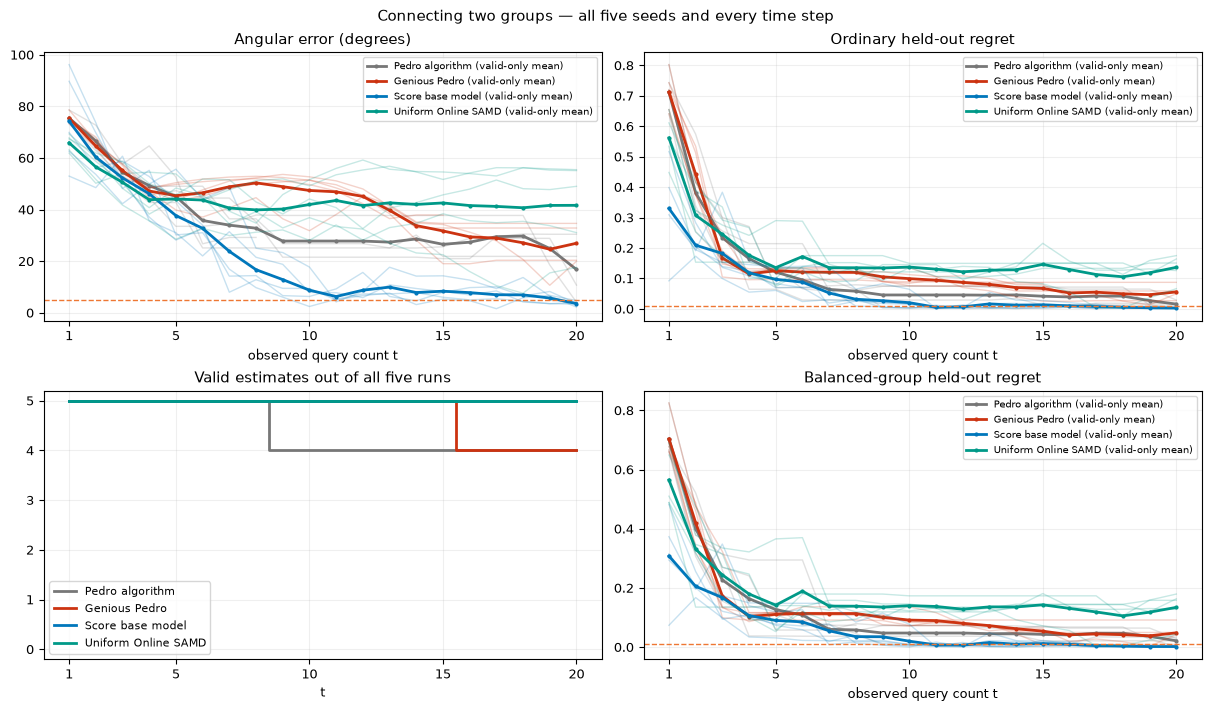

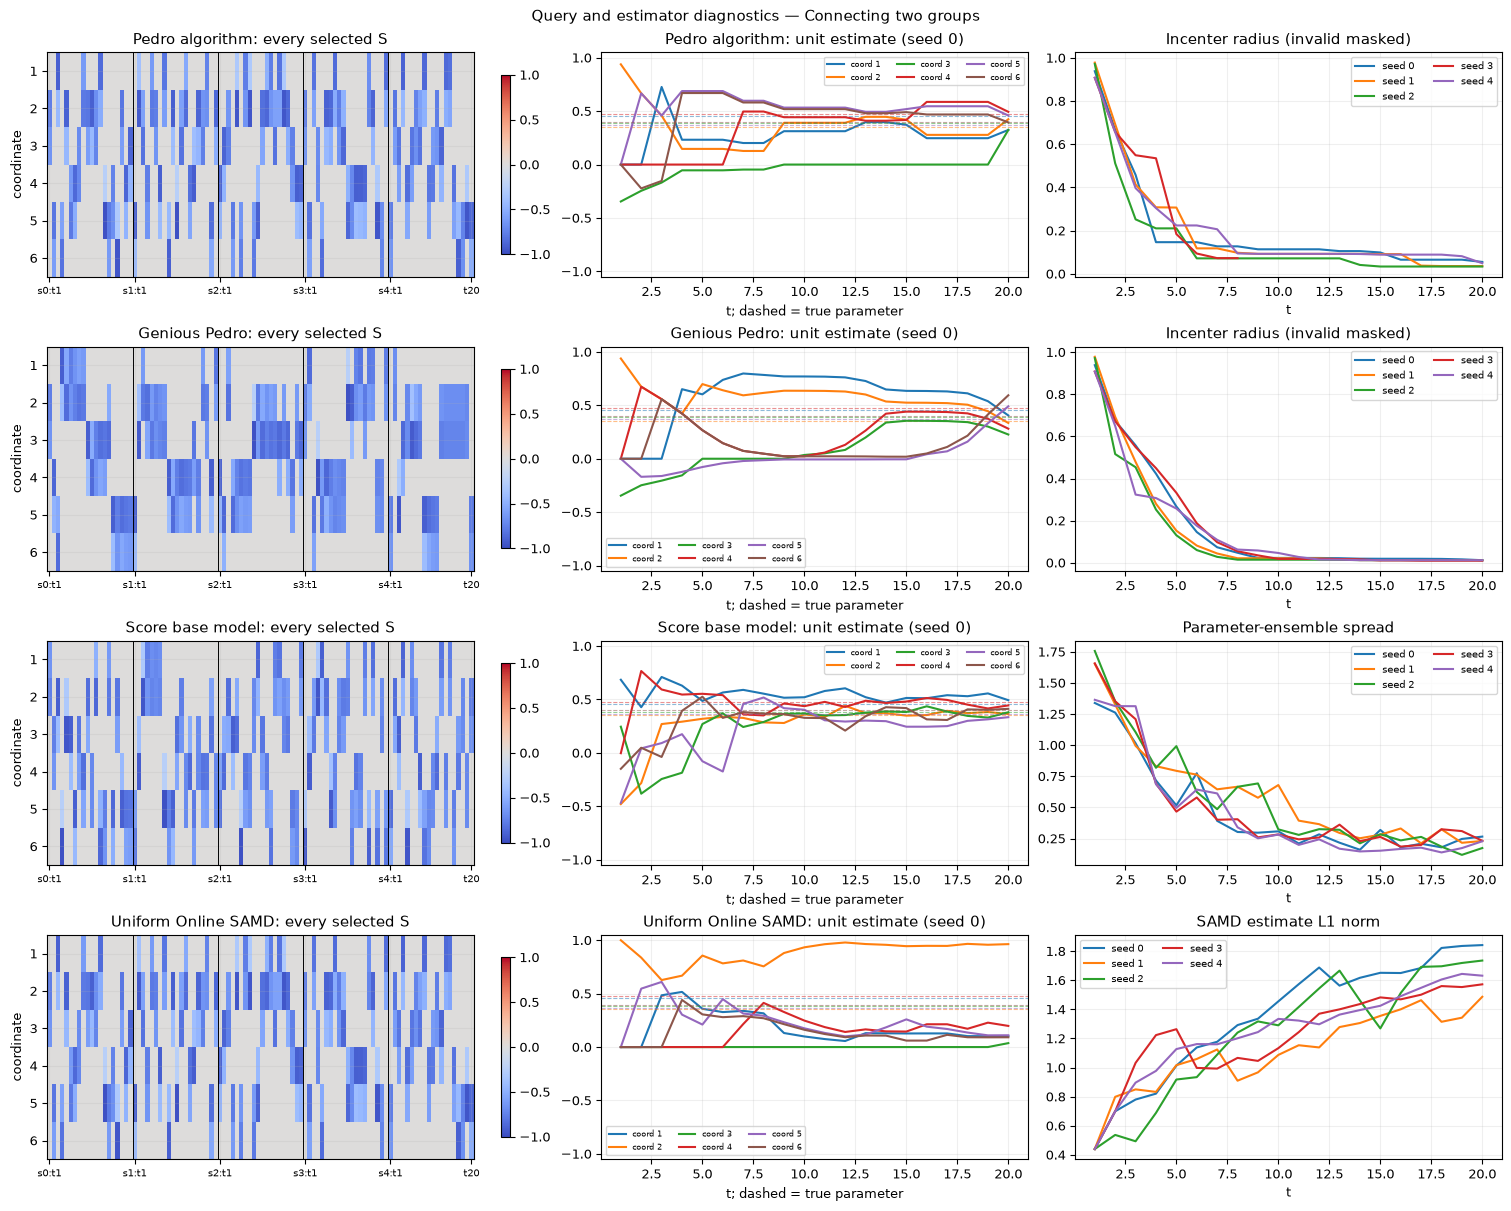

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,coordinate 1 vs 2,coordinate 2 vs 3,coordinate 4 vs 5,coordinate 5 vs 6,coordinate 3 vs 4
0,0,Pedro algorithm,valid,NaN,3,3,6,5,4,2
1,0,Genious Pedro,valid,NaN,2,6,2,1,6,5
2,0,Score base model,valid,NaN,1,3,4,3,7,3
3,0,Uniform Online SAMD,valid,NaN,3,3,6,5,4,2
4,1,Pedro algorithm,valid,NaN,2,5,7,4,3,1
5,1,Genious Pedro,degenerate_cone,16.0,2,3,7,8,1,1
6,1,Score base model,valid,NaN,2,5,2,5,4,4
7,1,Uniform Online SAMD,valid,NaN,2,5,7,4,3,1
8,2,Pedro algorithm,valid,NaN,1,7,4,4,3,2
9,2,Genious Pedro,valid,NaN,1,1,8,7,1,3


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.0000, 0.9384, -0.3457, -0.0000, -0.0000, -0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",78.61865,0.65464,valid,None,0.68937
1,Pedro algorithm,"[-0.0000, 0.9384, -0.3457, -0.0000, -0.0000, -0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",78.61865,0.65464,valid,None,0.68937
1,Score base model,"[0.5036, -0.3525, 0.1804, -0.0021, -0.3444, -0.1097]","[-0.6544, -0.7562, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",89.73268,0.51705,valid,None,0.48224
1,Uniform Online SAMD,"[0.0000, 0.4400, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",69.32889,0.65464,valid,None,0.68937
2,Genious Pedro,"[-0.0000, 0.6744, -0.2484, 0.6744, -0.1694, -0.0000]","[0.0000, 0.0000, 0.0000, -0.8813, -0.4725, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",66.43245,0.37366,valid,None,0.33415
2,Pedro algorithm,"[-0.0000, 0.6670, -0.2457, -0.0000, 0.6670, -0.2232]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7986, -0.6019]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",72.73093,0.32393,valid,None,0.37900
2,Score base model,"[0.3406, -0.2250, -0.3041, 0.6102, 0.0336, 0.0381]","[0.0000, 0.0000, -0.7572, -0.6532, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",69.79637,0.28315,valid,None,0.25586
2,Uniform Online SAMD,"[0.0000, 0.4231, 0.0000, 0.0000, 0.2763, 0.0000]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7986, -0.6019]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",60.22622,0.32393,valid,None,0.37900
3,Genious Pedro,"[-0.0000, 0.5573, -0.2053, 0.5573, -0.1619, 0.5573]","[0.0000, 0.0000, 0.0000, 0.0000, -0.5358, -0.8443]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",57.07074,0.19003,valid,None,0.17305
3,Pedro algorithm,"[0.7265, 0.4583, -0.1688, -0.0000, 0.4583, -0.1534]","[-0.9026, -0.4306, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",57.68893,0.25585,valid,None,0.31335


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.0000, -0.0000, -0.0000, -0.0000, 0.9782, -0.2076]","[0.0000, 0.0000, 0.0000, 0.0000, -0.9138, -0.4061]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",73.27955,0.64099,valid,None,0.66591
1,Pedro algorithm,"[-0.0000, -0.0000, -0.0000, -0.0000, 0.9782, -0.2076]","[0.0000, 0.0000, 0.0000, 0.0000, -0.9138, -0.4061]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",73.27955,0.64099,valid,None,0.66591
1,Score base model,"[-0.0109, 0.1970, 0.2510, -0.1649, -0.1435, 0.5875]","[0.0000, 0.0000, 0.0000, 0.0000, -0.6192, -0.7853]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",62.60427,0.30918,valid,None,0.29430
1,Uniform Online SAMD,"[0.0000, 0.0000, 0.0000, 0.0000, 0.4400, 0.0000]","[0.0000, 0.0000, 0.0000, 0.0000, -0.9138, -0.4061]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",67.36288,0.44824,valid,None,0.48901
2,Genious Pedro,"[-0.0000, -0.1346, 0.6929, -0.0000, 0.6929, -0.1470]","[0.0000, -0.3745, -0.9272, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",64.14493,0.37574,valid,None,0.34269
2,Pedro algorithm,"[-0.1346, 0.6929, -0.0000, -0.0000, 0.6929, -0.1470]","[-0.3745, -0.9272, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",62.91057,0.25328,valid,None,0.31853
2,Score base model,"[0.0702, -0.0591, 0.0997, 0.5838, -0.0322, 0.6257]","[0.0000, 0.0000, -0.3964, -0.9181, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",53.64352,0.19465,valid,None,0.20790
2,Uniform Online SAMD,"[-0.1036, 0.2747, 0.0000, 0.0000, 0.4206, 0.0000]","[-0.3745, -0.9272, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",61.92227,0.25328,valid,None,0.31853
3,Genious Pedro,"[-0.1660, 0.4788, 0.7097, -0.0000, 0.4788, -0.1016]","[-0.6192, -0.7853, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",54.26423,0.14750,valid,None,0.13283
3,Pedro algorithm,"[-0.0804, 0.4137, 0.8022, -0.0000, 0.4137, -0.0878]","[0.0000, -0.5798, -0.8148, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",52.43823,0.16165,valid,None,0.15586


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.0000, -0.0000, -0.0000, 0.9719, -0.2355, -0.0000]","[0.0000, 0.0000, 0.0000, -0.8891, -0.4577, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",75.06113,0.74319,valid,None,0.67778
1,Pedro algorithm,"[-0.0000, -0.0000, -0.0000, 0.9719, -0.2355, -0.0000]","[0.0000, 0.0000, 0.0000, -0.8891, -0.4577, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",75.06113,0.74319,valid,None,0.67778
1,Score base model,"[-0.1570, 0.3158, 0.1249, 0.1817, 0.5531, -0.1033]","[0.0000, 0.0000, 0.0000, -0.5798, -0.8148, 0.0000]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",52.99075,0.09207,valid,None,0.07384
1,Uniform Online SAMD,"[0.0000, 0.0000, 0.0000, 0.4400, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, -0.8891, -0.4577, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",67.81317,0.56129,valid,None,0.51007
2,Genious Pedro,"[-0.0000, -0.0000, -0.0000, 0.8460, 0.5160, -0.1345]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8728, -0.4880]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",59.53610,0.51320,valid,None,0.46170
2,Pedro algorithm,"[-0.0000, -0.0000, 0.8502, 0.5116, -0.1240, -0.0000]","[0.0000, 0.0000, -0.8835, -0.4684, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",63.78175,0.57404,valid,None,0.52155
2,Score base model,"[0.1771, -0.0042, 0.0077, 0.5698, 0.5725, -0.0002]","[0.0000, 0.0000, -0.5230, -0.8523, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",48.52408,0.17300,valid,None,0.16737
2,Uniform Online SAMD,"[0.0000, 0.0000, 0.2873, 0.2496, 0.0000, 0.0000]","[0.0000, 0.0000, -0.8835, -0.4684, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",58.70608,0.38916,valid,None,0.34729
3,Genious Pedro,"[-0.1449, 0.4537, -0.0000, 0.7439, 0.4537, -0.1182]","[-0.5798, -0.8148, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",52.66669,0.10469,valid,None,0.09934
3,Pedro algorithm,"[-0.0000, 0.8700, 0.4193, 0.2523, -0.0611, -0.0000]","[0.0000, -0.6544, -0.7562, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",50.95553,0.29739,valid,None,0.26033


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.0000, -0.4191, 0.9079, -0.0000, -0.0000, -0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",75.46722,0.72027,valid,None,0.65949
1,Pedro algorithm,"[-0.0000, -0.4191, 0.9079, -0.0000, -0.0000, -0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",75.46722,0.72027,valid,None,0.65949
1,Score base model,"[0.1055, 0.0559, 0.0473, -0.0779, -0.0661, 0.5801]","[0.0000, 0.0000, 0.0000, 0.0000, -0.3107, -0.9505]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",69.93904,0.33334,valid,None,0.31534
1,Uniform Online SAMD,"[0.0000, 0.0000, 0.4400, 0.0000, 0.0000, 0.0000]","[0.0000, -0.7610, -0.6487, 0.0000, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",61.89124,0.53445,valid,None,0.48807
2,Genious Pedro,"[0.6722, -0.3103, 0.6722, -0.0000, -0.0000, -0.0000]","[-0.8530, -0.5219, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",65.04940,0.53445,valid,None,0.48807
2,Pedro algorithm,"[-0.0000, -0.3033, 0.6572, -0.0000, 0.6572, -0.2101]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8145, -0.5802]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",65.83940,0.33916,valid,None,0.30676
2,Score base model,"[0.1404, 0.1339, -0.0938, 0.4656, -0.0466, 0.3376]","[0.0000, 0.0000, -0.3964, -0.9181, 0.0000, 0.0000]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",56.24921,0.19105,valid,None,0.19550
2,Uniform Online SAMD,"[0.0000, 0.0000, 0.4231, 0.0000, 0.2763, 0.0000]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8145, -0.5802]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",50.21347,0.15334,valid,None,0.13534
3,Genious Pedro,"[0.5492, -0.2535, 0.5492, -0.0000, 0.5492, -0.1756]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8145, -0.5802]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",57.66257,0.15334,valid,None,0.13534
3,Pedro algorithm,"[0.5492, -0.2535, 0.5492, -0.0000, 0.5492, -0.1756]","[-0.8145, -0.5802, 0.0000, 0.0000, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]",57.66257,0.15334,valid,None,0.13534


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.0000, -0.0000, -0.0000, -0.0000, -0.4191, 0.9079]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7610, -0.6487]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",74.83896,0.80259,valid,None,0.82515
1,Pedro algorithm,"[-0.0000, -0.0000, -0.0000, -0.0000, -0.4191, 0.9079]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7610, -0.6487]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",74.83896,0.80259,valid,None,0.82515
1,Score base model,"[0.1141, -0.1216, -0.0517, 0.0644, 0.4836, -0.5376]","[0.0000, 0.0000, 0.0000, 0.0000, -0.8415, -0.5402]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",96.20105,0.39854,valid,None,0.37328
1,Uniform Online SAMD,"[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4400]","[0.0000, 0.0000, 0.0000, 0.0000, -0.7610, -0.6487]","[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",63.14575,0.61111,valid,None,0.64903
2,Genious Pedro,"[-0.2578, 0.6495, -0.0000, -0.0000, -0.2998, 0.6495]","[-0.6858, -0.7278, 0.0000, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",68.17233,0.41650,valid,None,0.47679
2,Pedro algorithm,"[-0.0000, 0.6558, -0.2195, -0.0000, -0.3027, 0.6558]","[0.0000, -0.7986, -0.6019, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",67.62932,0.41650,valid,None,0.47679
2,Score base model,"[-0.1797, 0.5610, -0.3708, 0.0737, 0.4898, 0.0670]","[0.0000, -0.8415, -0.5402, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",73.69554,0.20393,valid,None,0.20104
2,Uniform Online SAMD,"[0.0000, 0.2763, 0.0000, 0.0000, 0.0000, 0.4231]","[0.0000, -0.7986, -0.6019, 0.0000, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",51.70866,0.41650,valid,None,0.47679
3,Genious Pedro,"[-0.1284, 0.3236, -0.0000, -0.0515, 0.3236, 0.8783]","[0.0000, 0.0000, 0.0000, -0.3107, -0.9505, 0.0000]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",54.14694,0.24100,valid,None,0.32355
3,Pedro algorithm,"[-0.0000, 0.7962, 0.3970, -0.1317, -0.1832, 0.3970]","[0.0000, 0.0000, -0.8016, -0.5978, 0.0000, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",53.31079,0.30007,valid,None,0.27011


Completed scenario 1/8; 20/160 complete runs loaded.


In [3]:
run_and_show_family(0)

## 2. Several boundaries to locate — 4D

Three equally available reference comparisons, (1,2), (1,3), (1,4), have 40 candidate ratios each. There are no deliberately rare groups. Query selection must decide which boundary needs refinement and which ratio to test.

CACHED boundaries-4d seed=0 Pedro algorithm
CACHED boundaries-4d seed=0 Genious Pedro
CACHED boundaries-4d seed=0 Score base model
CACHED boundaries-4d seed=0 Uniform Online SAMD
CACHED boundaries-4d seed=1 Pedro algorithm
CACHED boundaries-4d seed=1 Genious Pedro
CACHED boundaries-4d seed=1 Score base model
CACHED boundaries-4d seed=1 Uniform Online SAMD
CACHED boundaries-4d seed=2 Pedro algorithm
CACHED boundaries-4d seed=2 Genious Pedro
CACHED boundaries-4d seed=2 Score base model
CACHED boundaries-4d seed=2 Uniform Online SAMD
CACHED boundaries-4d seed=3 Pedro algorithm
CACHED boundaries-4d seed=3 Genious Pedro
CACHED boundaries-4d seed=3 Score base model


CACHED boundaries-4d seed=3 Uniform Online SAMD


CACHED boundaries-4d seed=4 Pedro algorithm
CACHED boundaries-4d seed=4 Genious Pedro
CACHED boundaries-4d seed=4 Score base model
CACHED boundaries-4d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,4/5,1,10.2015,9.2091,0.0206,0.0225,2,2,0.0748
1,Genious Pedro,ordinary,0/5,5,NaN,NaN,NaN,NaN,0,0,0.1452
2,Score base model,ordinary,5/5,0,1.7153,0.8472,0.0004,0.0005,5,5,14.5712
3,Uniform Online SAMD,ordinary,5/5,0,54.9194,3.9142,0.1199,0.0099,0,0,0.0042


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,67.7419,1.9925,0.2577,0.2893,5/5,67.7419,1.9925,0.2577,0.2893,5/5,53.3049,5.7543,0.2206,0.1497,5/5,65.3200,9.4391,0.2091,0.1806
1,2,5/5,65.6431,11.0746,0.1323,0.0249,5/5,51.4430,2.5643,0.0967,0.0190,5/5,56.2408,6.1573,0.1808,0.1890,5/5,60.8131,8.1201,0.1479,0.0365
2,3,5/5,64.9292,20.8383,0.1296,0.0196,5/5,45.3218,1.3153,0.0946,0.0218,5/5,58.2239,14.7825,0.0894,0.0118,5/5,60.8584,5.4928,0.2091,0.1806
3,4,5/5,38.7021,7.3298,0.0767,0.0194,5/5,44.3940,1.6383,0.0871,0.0182,5/5,40.1676,11.6687,0.0633,0.0249,5/5,55.7843,6.1148,0.1148,0.0380
4,5,5/5,38.7124,7.3168,0.0773,0.0189,5/5,44.3025,1.5780,0.0853,0.0170,5/5,35.9296,19.2543,0.0449,0.0321,5/5,54.7773,9.5366,0.1273,0.0300
5,6,4/5,34.2223,19.5151,0.0690,0.0392,5/5,44.2951,1.5961,0.0850,0.0172,5/5,34.6490,20.0825,0.0453,0.0314,5/5,56.8623,5.9278,0.1809,0.1572
6,7,4/5,27.7323,17.0641,0.0502,0.0390,5/5,44.2794,1.5868,0.0850,0.0172,5/5,36.3400,18.8927,0.0378,0.0258,5/5,53.8285,3.7094,0.1370,0.0303
7,8,4/5,27.7107,17.0330,0.0500,0.0385,4/5,43.8889,1.5272,0.0840,0.0197,5/5,34.7425,15.8326,0.0362,0.0220,5/5,55.3804,4.8486,0.1862,0.1540
8,9,4/5,24.2167,12.9583,0.0372,0.0160,3/5,43.5807,1.7114,0.0897,0.0197,5/5,34.6161,15.0377,0.0345,0.0237,5/5,53.2849,6.7811,0.1902,0.1520
9,10,4/5,17.8863,16.3895,0.0257,0.0220,2/5,44.2543,1.7707,0.0890,0.0278,5/5,29.4900,12.0994,0.0373,0.0279,5/5,52.6951,5.8120,0.1281,0.0296


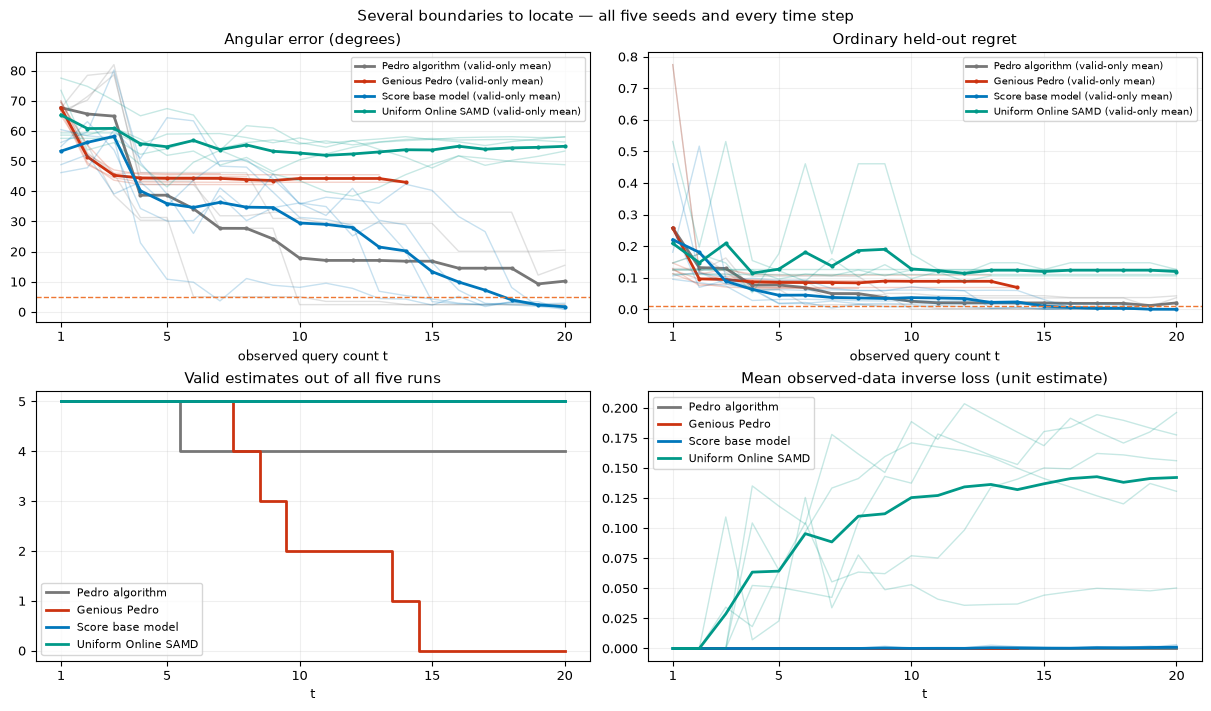

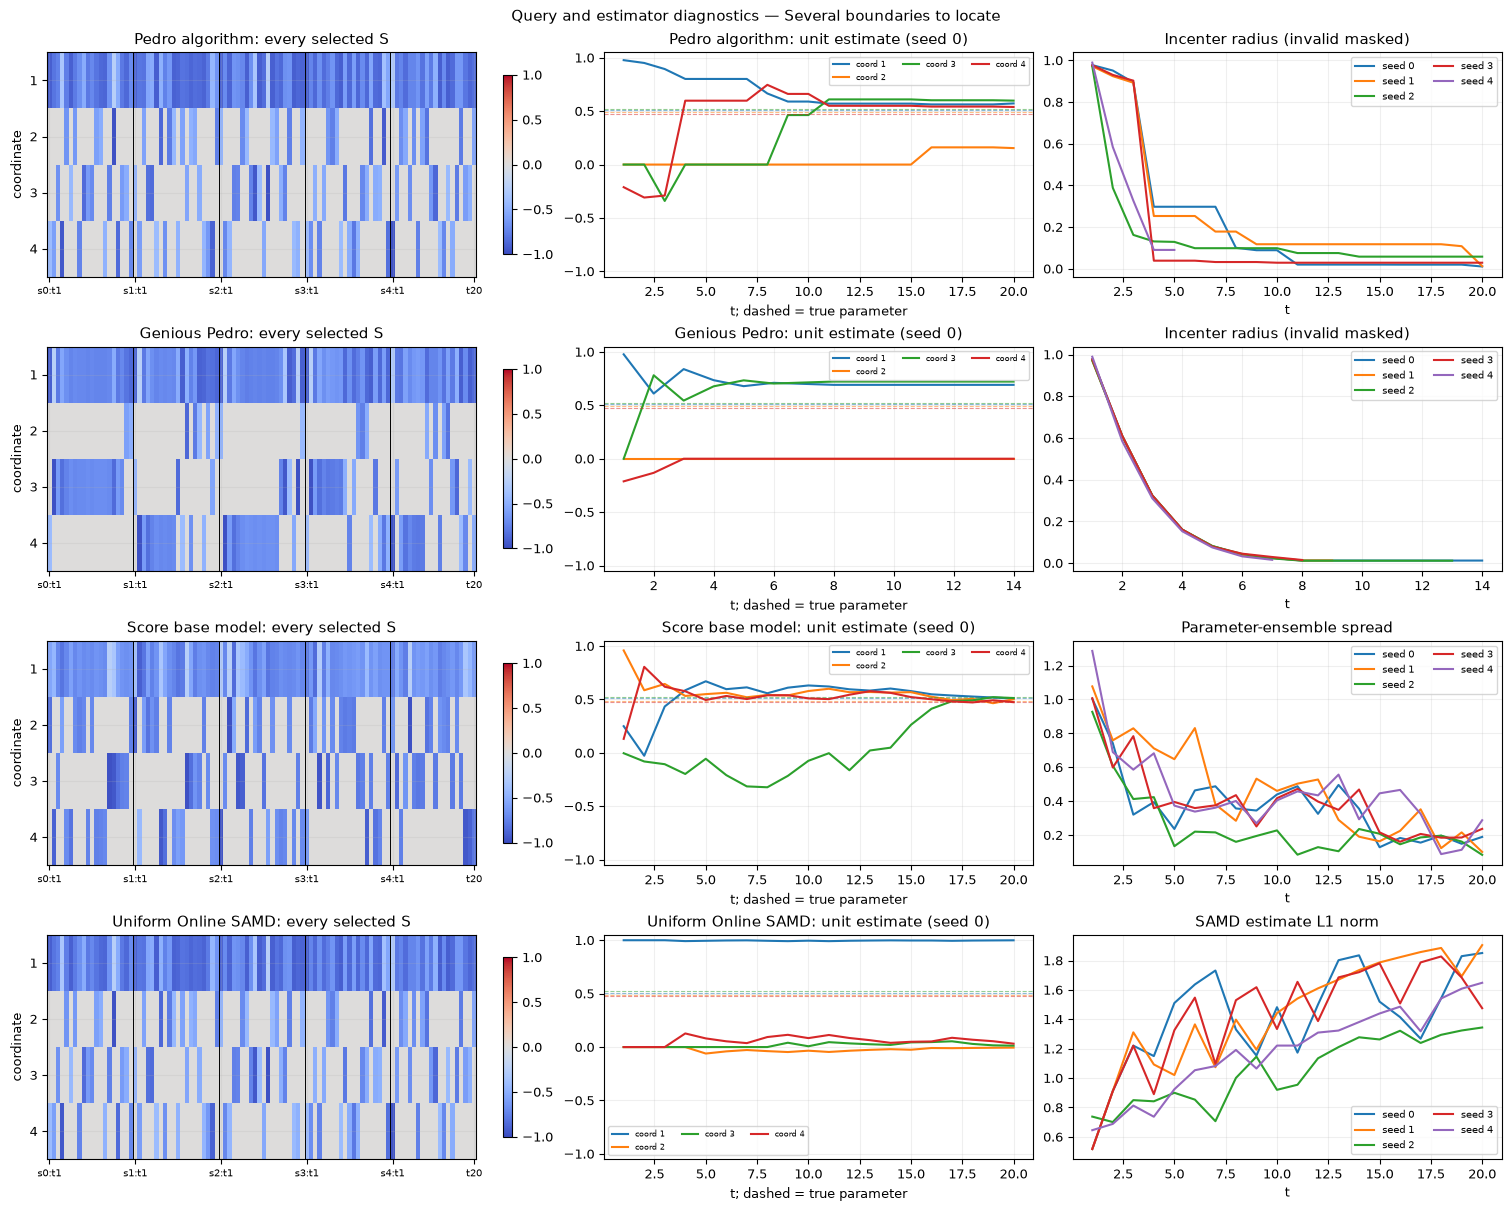

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,coordinate 1 vs 2,coordinate 1 vs 3,coordinate 1 vs 4
0,0,Pedro algorithm,valid,NaN,0,5,8,7
1,0,Genious Pedro,degenerate_cone,15.0,1,2,17,1
2,0,Score base model,valid,NaN,3,7,6,7
3,0,Uniform Online SAMD,valid,NaN,0,5,8,7
4,1,Pedro algorithm,valid,NaN,1,8,5,7
5,1,Genious Pedro,degenerate_cone,10.0,1,5,3,12
6,1,Score base model,valid,NaN,2,7,5,8
7,1,Uniform Online SAMD,valid,NaN,1,8,5,7
8,2,Pedro algorithm,valid,NaN,0,7,8,5
9,2,Genious Pedro,degenerate_cone,14.0,3,2,4,14


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.9773, -0.0000, -0.0000, -0.2118]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",66.58336,0.12929,valid,None
1,Pedro algorithm,"[0.9773, -0.0000, -0.0000, -0.2118]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",66.58336,0.12929,valid,None
1,Score base model,"[0.1453, 0.5579, -0.0018, 0.0764]","[-0.5510, -0.8345, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",48.83394,0.18088,valid,None
1,Uniform Online SAMD,"[0.5174, 0.0000, 0.0000, 0.0000]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",59.37684,0.12929,valid,None
2,Genious Pedro,"[0.6100, -0.0000, 0.7813, -0.1322]","[-0.2425, 0.0000, -0.9701, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",48.84835,0.07516,valid,None
2,Pedro algorithm,"[0.9512, -0.0000, -0.0000, -0.3087]","[-0.8094, 0.0000, 0.0000, -0.5873]","[1.0000, 0.0000, 0.0000, 0.0000]",70.23613,0.12929,valid,None
2,Score base model,"[-0.0169, 0.3699, -0.0507, 0.5083]","[-0.4518, 0.0000, 0.0000, -0.8921]","[0.0000, 0.0000, 0.0000, 1.0000]",52.15031,0.51685,valid,None
2,Uniform Online SAMD,"[0.9118, 0.0000, 0.0000, 0.0000]","[-0.8094, 0.0000, 0.0000, -0.5873]","[1.0000, 0.0000, 0.0000, 0.0000]",59.37684,0.12929,valid,None
3,Genious Pedro,"[0.8389, -0.0000, 0.5442, -0.0000]","[-0.7870, 0.0000, -0.6169, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",44.52530,0.08068,valid,None
3,Pedro algorithm,"[0.8942, -0.0000, -0.3407, -0.2902]","[-0.7465, 0.0000, -0.6654, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",82.00347,0.12929,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.9719, -0.0000, -0.2355, -0.0000]","[-0.8891, 0.0000, -0.4577, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",67.56149,0.12480,valid,None
1,Pedro algorithm,"[0.9719, -0.0000, -0.2355, -0.0000]","[-0.8891, 0.0000, -0.4577, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",67.56149,0.12480,valid,None
1,Score base model,"[0.0011, 0.4600, 0.2276, 0.0927]","[-0.3745, -0.9272, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",46.19452,0.25923,valid,None
1,Uniform Online SAMD,"[0.5174, 0.0000, 0.0000, 0.0000]","[-0.8891, 0.0000, -0.4577, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",58.62910,0.12480,valid,None
2,Genious Pedro,"[0.6087, -0.0000, -0.1475, 0.7796]","[-0.2425, 0.0000, 0.0000, -0.9701]","[0.0000, 0.0000, 0.0000, 1.0000]",49.49286,0.09576,valid,None
2,Pedro algorithm,"[0.9242, -0.0000, -0.2240, -0.3093]","[-0.7986, 0.0000, 0.0000, -0.6019]","[1.0000, 0.0000, 0.0000, 0.0000]",78.45511,0.12480,valid,None
2,Score base model,"[0.4643, 0.5648, 0.2006, -0.1265]","[-0.9026, 0.0000, 0.0000, -0.4306]","[1.0000, 0.0000, 0.0000, 0.0000]",47.81898,0.06970,valid,None
2,Uniform Online SAMD,"[0.9118, 0.0000, 0.0000, 0.0000]","[-0.7986, 0.0000, 0.0000, -0.6019]","[1.0000, 0.0000, 0.0000, 0.0000]",58.62910,0.12480,valid,None
3,Genious Pedro,"[0.8389, -0.0000, -0.0000, 0.5442]","[-0.7870, 0.0000, 0.0000, -0.6169]","[1.0000, 0.0000, 0.0000, 0.0000]",43.67301,0.10519,valid,None
3,Pedro algorithm,"[0.9309, -0.2270, -0.1425, -0.2483]","[-0.8194, -0.5732, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",79.39162,0.12480,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.9706, -0.2408, -0.0000, -0.0000]","[-0.8840, -0.4675, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",69.96586,0.14697,valid,None
1,Pedro algorithm,"[0.9706, -0.2408, -0.0000, -0.0000]","[-0.8840, -0.4675, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",69.96586,0.14697,valid,None
1,Score base model,"[-0.0611, -0.0299, 0.0824, 0.5222]","[-0.2885, 0.0000, 0.0000, -0.9575]","[0.0000, 0.0000, 0.0000, 1.0000]",60.45959,0.46101,valid,None
1,Uniform Online SAMD,"[0.5016, -0.2364, 0.0000, 0.0000]","[-0.8840, -0.4675, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",77.53699,0.14697,valid,None
2,Genious Pedro,"[0.6084, -0.1510, -0.0000, 0.7792]","[-0.2425, 0.0000, 0.0000, -0.9701]","[0.0000, 0.0000, 0.0000, 1.0000]",52.22499,0.11202,valid,None
2,Pedro algorithm,"[0.3884, -0.0964, -0.0000, 0.9164]","[-0.6955, 0.0000, 0.0000, -0.7185]","[0.0000, 0.0000, 0.0000, 1.0000]",52.77081,0.17546,valid,None
2,Score base model,"[0.4508, 0.0517, -0.2639, 0.5931]","[-0.7138, 0.0000, -0.7003, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",58.40674,0.11493,valid,None
2,Uniform Online SAMD,"[0.1369, -0.2364, 0.0000, 0.3276]","[-0.6955, 0.0000, 0.0000, -0.7185]","[0.0000, 0.0000, 0.0000, 1.0000]",74.80204,0.17546,valid,None
3,Genious Pedro,"[0.8389, -0.0000, -0.0000, 0.5442]","[-0.7870, 0.0000, 0.0000, -0.6169]","[1.0000, 0.0000, 0.0000, 0.0000]",47.10016,0.12629,valid,None
3,Pedro algorithm,"[0.5960, -0.0000, -0.0000, 0.8029]","[-0.8891, 0.0000, 0.0000, -0.4577]","[1.0000, 0.0000, 0.0000, 0.0000]",45.87824,0.11825,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.9773, -0.0000, -0.0000, -0.2118]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",65.15848,0.11279,valid,None
1,Pedro algorithm,"[0.9773, -0.0000, -0.0000, -0.2118]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",65.15848,0.11279,valid,None
1,Score base model,"[0.5011, 0.0941, 0.1658, -0.1484]","[-0.7745, 0.0000, 0.0000, -0.6326]","[1.0000, 0.0000, 0.0000, 0.0000]",54.84229,0.09546,valid,None
1,Uniform Online SAMD,"[0.5174, 0.0000, 0.0000, 0.0000]","[-0.9103, 0.0000, 0.0000, -0.4140]","[1.0000, 0.0000, 0.0000, 0.0000]",57.56145,0.11279,valid,None
2,Genious Pedro,"[0.6100, -0.0000, 0.7813, -0.1322]","[-0.2425, 0.0000, -0.9701, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",51.31490,0.08114,valid,None
2,Pedro algorithm,"[0.9303, -0.0000, -0.0000, -0.3669]","[-0.7308, 0.0000, 0.0000, -0.6826]","[1.0000, 0.0000, 0.0000, 0.0000]",71.41974,0.11279,valid,None
2,Score base model,"[0.4321, 0.6401, -0.1135, -0.2638]","[-0.6313, -0.7755, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",63.11308,0.08473,valid,None
2,Uniform Online SAMD,"[0.9118, 0.0000, 0.0000, 0.0000]","[-0.7308, 0.0000, 0.0000, -0.6826]","[1.0000, 0.0000, 0.0000, 0.0000]",57.56145,0.11279,valid,None
3,Genious Pedro,"[0.8389, -0.0000, 0.5442, -0.0000]","[-0.7870, 0.0000, -0.6169, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",45.35335,0.07078,valid,None
3,Pedro algorithm,"[0.9028, -0.0000, -0.2413, -0.3561]","[-0.8667, 0.0000, -0.4989, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",78.62835,0.11279,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.1458, -0.0000, -0.0000, 0.9893]","[-0.2885, 0.0000, 0.0000, -0.9575]","[0.0000, 0.0000, 0.0000, 1.0000]",69.44048,0.77483,valid,None
1,Pedro algorithm,"[-0.1458, -0.0000, -0.0000, 0.9893]","[-0.2885, 0.0000, 0.0000, -0.9575]","[0.0000, 0.0000, 0.0000, 1.0000]",69.44048,0.77483,valid,None
1,Score base model,"[0.5656, -0.0810, 0.0836, 0.0509]","[-0.7610, -0.6487, 0.0000, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",56.19428,0.10620,valid,None
1,Uniform Online SAMD,"[-0.1333, 0.0000, 0.0000, 0.5122]","[-0.2885, 0.0000, 0.0000, -0.9575]","[0.0000, 0.0000, 0.0000, 1.0000]",73.49583,0.53146,valid,None
2,Genious Pedro,"[0.5842, -0.0000, -0.2017, 0.7861]","[-0.7870, 0.0000, -0.6169, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",55.33388,0.11918,valid,None
2,Pedro algorithm,"[0.5842, -0.0000, -0.2017, 0.7861]","[-0.7870, 0.0000, -0.6169, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",55.33388,0.11918,valid,None
2,Score base model,"[0.3930, -0.2539, 0.6810, 0.0894]","[-0.5201, 0.0000, -0.8541, 0.0000]","[0.0000, 0.0000, 1.0000, 0.0000]",59.71483,0.11773,valid,None
2,Uniform Online SAMD,"[0.1803, 0.0000, 0.0000, 0.5080]","[-0.7870, 0.0000, -0.6169, 0.0000]","[1.0000, 0.0000, 0.0000, 0.0000]",53.69621,0.19732,valid,None
3,Genious Pedro,"[0.8203, -0.0000, -0.0000, 0.5719]","[-0.7986, 0.0000, 0.0000, -0.6019]","[1.0000, 0.0000, 0.0000, 0.0000]",45.95711,0.08991,valid,None
3,Pedro algorithm,"[0.3269, 0.8288, -0.1129, 0.4399]","[-0.7308, -0.6826, 0.0000, 0.0000]","[0.0000, 1.0000, 0.0000, 0.0000]",38.74431,0.16286,valid,None


Completed scenario 2/8; 40/160 complete runs loaded.


In [4]:
run_and_show_family(1)

## 3. Similar queries versus varied queries — 6D

The expert chooses exactly two coordinates. Two predetermined profiles receive 48 nearby queries each; 24 other queries cover diverse directions. Clustering is independent of theta and does not guarantee identical decisions. Both natural-mixture and balanced-group tests are reported.

CACHED redundancy-6d seed=0 Pedro algorithm
CACHED redundancy-6d seed=0 Genious Pedro
CACHED redundancy-6d seed=0 Score base model
CACHED redundancy-6d seed=0 Uniform Online SAMD
CACHED redundancy-6d seed=1 Pedro algorithm
CACHED redundancy-6d seed=1 Genious Pedro
CACHED redundancy-6d seed=1 Score base model
CACHED redundancy-6d seed=1 Uniform Online SAMD
CACHED redundancy-6d seed=2 Pedro algorithm
CACHED redundancy-6d seed=2 Genious Pedro
CACHED redundancy-6d seed=2 Score base model
CACHED redundancy-6d seed=2 Uniform Online SAMD
CACHED redundancy-6d seed=3 Pedro algorithm
CACHED redundancy-6d seed=3 Genious Pedro


CACHED redundancy-6d seed=3 Score base model
CACHED redundancy-6d seed=3 Uniform Online SAMD
CACHED redundancy-6d seed=4 Pedro algorithm
CACHED redundancy-6d seed=4 Genious Pedro
CACHED redundancy-6d seed=4 Score base model
CACHED redundancy-6d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,30.5652,8.9585,0.0188,0.0135,0,2,0.1097
1,Pedro algorithm,balanced,5/5,0,30.5652,8.9585,0.0268,0.0212,0,0,0.1097
2,Genious Pedro,ordinary,1/5,4,34.7468,NaN,0.0195,NaN,0,0,0.2593
3,Genious Pedro,balanced,1/5,4,34.7468,NaN,0.0203,NaN,0,0,0.2593
4,Score base model,ordinary,5/5,0,5.4143,3.4256,0.0005,0.0005,2,5,14.8481
5,Score base model,balanced,5/5,0,5.4143,3.4256,0.0007,0.0008,2,5,14.8481
6,Uniform Online SAMD,ordinary,5/5,0,58.1936,4.2042,0.0255,0.0083,0,0,0.0053
7,Uniform Online SAMD,balanced,5/5,0,58.1936,4.2042,0.0334,0.0028,0,0,0.0053


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,60.2299,19.1218,0.2037,0.1733,5/5,60.2299,19.1218,0.2037,0.1733,5/5,50.7692,26.1809,0.2705,0.2659,5/5,66.0119,15.0926,0.2707,0.1510
1,2,5/5,39.4635,5.0875,0.0308,0.0178,5/5,32.7952,11.0842,0.0346,0.0281,5/5,27.9308,11.3383,0.0511,0.0517,5/5,50.0179,16.9167,0.1201,0.1554
2,3,5/5,40.5479,4.0188,0.0324,0.0060,5/5,26.7939,9.4421,0.0361,0.0359,5/5,27.1682,12.2765,0.0535,0.0299,5/5,51.0883,7.8376,0.0903,0.1069
3,4,5/5,36.2469,7.6044,0.0275,0.0128,5/5,28.2091,7.3218,0.0192,0.0121,5/5,20.6217,7.1824,0.0129,0.0081,5/5,48.4587,4.5442,0.0587,0.0615
4,5,5/5,36.1673,7.3094,0.0262,0.0112,5/5,25.8058,7.3563,0.0173,0.0084,5/5,16.8699,6.5102,0.0053,0.0053,5/5,51.1710,5.6116,0.0801,0.1018
5,6,5/5,38.4456,2.6676,0.0273,0.0039,5/5,29.7101,7.6893,0.0175,0.0018,5/5,10.4442,3.6791,0.0047,0.0022,5/5,52.1969,4.2284,0.0547,0.0704
6,7,5/5,35.6736,4.5588,0.0225,0.0067,5/5,32.7818,6.8962,0.0187,0.0083,5/5,8.6093,3.5769,0.0039,0.0022,5/5,51.9075,3.5774,0.0473,0.0574
7,8,5/5,31.8564,6.7453,0.0158,0.0047,5/5,31.3614,8.0905,0.0154,0.0084,5/5,8.7824,3.4862,0.0039,0.0024,5/5,51.4056,5.3546,0.0407,0.0485
8,9,5/5,32.4366,6.8810,0.0170,0.0045,4/5,30.2143,7.6512,0.0128,0.0073,5/5,9.4436,4.4136,0.0057,0.0060,5/5,53.2684,5.0758,0.0403,0.0474
9,10,5/5,30.9351,7.7824,0.0146,0.0058,4/5,30.1883,7.2774,0.0114,0.0050,5/5,9.1328,6.0537,0.0021,0.0026,5/5,53.6885,3.9081,0.0338,0.0353


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,60.2299,19.1218,0.2359,0.1496,5/5,60.2299,19.1218,0.2359,0.1496,5/5,50.7692,26.1809,0.2680,0.2609,5/5,66.0119,15.0926,0.2770,0.1395
1,2,5/5,39.4635,5.0875,0.0464,0.0256,5/5,32.7952,11.0842,0.0399,0.0248,5/5,27.9308,11.3383,0.0510,0.0549,5/5,50.0179,16.9167,0.1392,0.1441
2,3,5/5,40.5479,4.0188,0.0444,0.0160,5/5,26.7939,9.4421,0.0400,0.0430,5/5,27.1682,12.2765,0.0571,0.0314,5/5,51.0883,7.8376,0.1066,0.0928
3,4,5/5,36.2469,7.6044,0.0381,0.0216,5/5,28.2091,7.3218,0.0227,0.0156,5/5,20.6217,7.1824,0.0180,0.0075,5/5,48.4587,4.5442,0.0628,0.0390
4,5,5/5,36.1673,7.3094,0.0340,0.0166,5/5,25.8058,7.3563,0.0178,0.0059,5/5,16.8699,6.5102,0.0100,0.0082,5/5,51.1710,5.6116,0.0898,0.0860
5,6,5/5,38.4456,2.6676,0.0372,0.0086,5/5,29.7101,7.6893,0.0154,0.0051,5/5,10.4442,3.6791,0.0039,0.0018,5/5,52.1969,4.2284,0.0598,0.0457
6,7,5/5,35.6736,4.5588,0.0302,0.0117,5/5,32.7818,6.8962,0.0199,0.0079,5/5,8.6093,3.5769,0.0048,0.0027,5/5,51.9075,3.5774,0.0500,0.0397
7,8,5/5,31.8564,6.7453,0.0221,0.0078,5/5,31.3614,8.0905,0.0176,0.0077,5/5,8.7824,3.4862,0.0039,0.0019,5/5,51.4056,5.3546,0.0462,0.0351
8,9,5/5,32.4366,6.8810,0.0235,0.0077,4/5,30.2143,7.6512,0.0165,0.0089,5/5,9.4436,4.4136,0.0058,0.0046,5/5,53.2684,5.0758,0.0468,0.0330
9,10,5/5,30.9351,7.7824,0.0224,0.0076,4/5,30.1883,7.2774,0.0156,0.0067,5/5,9.1328,6.0537,0.0043,0.0057,5/5,53.6885,3.9081,0.0397,0.0262


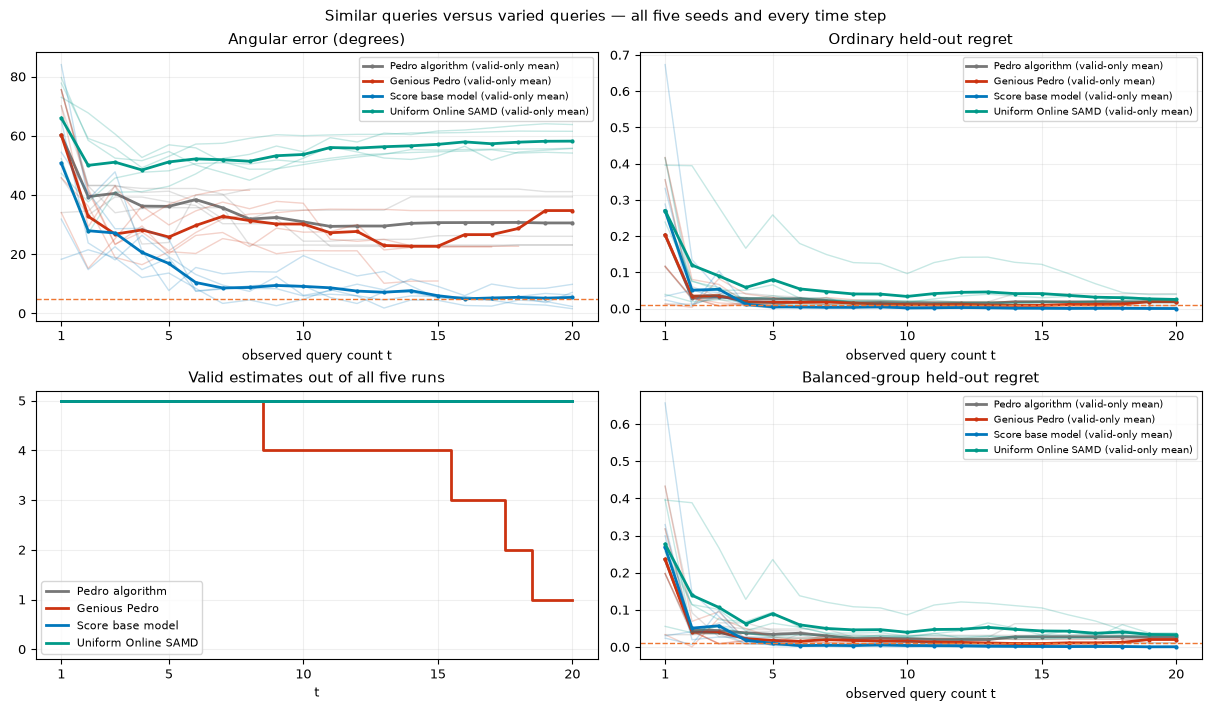

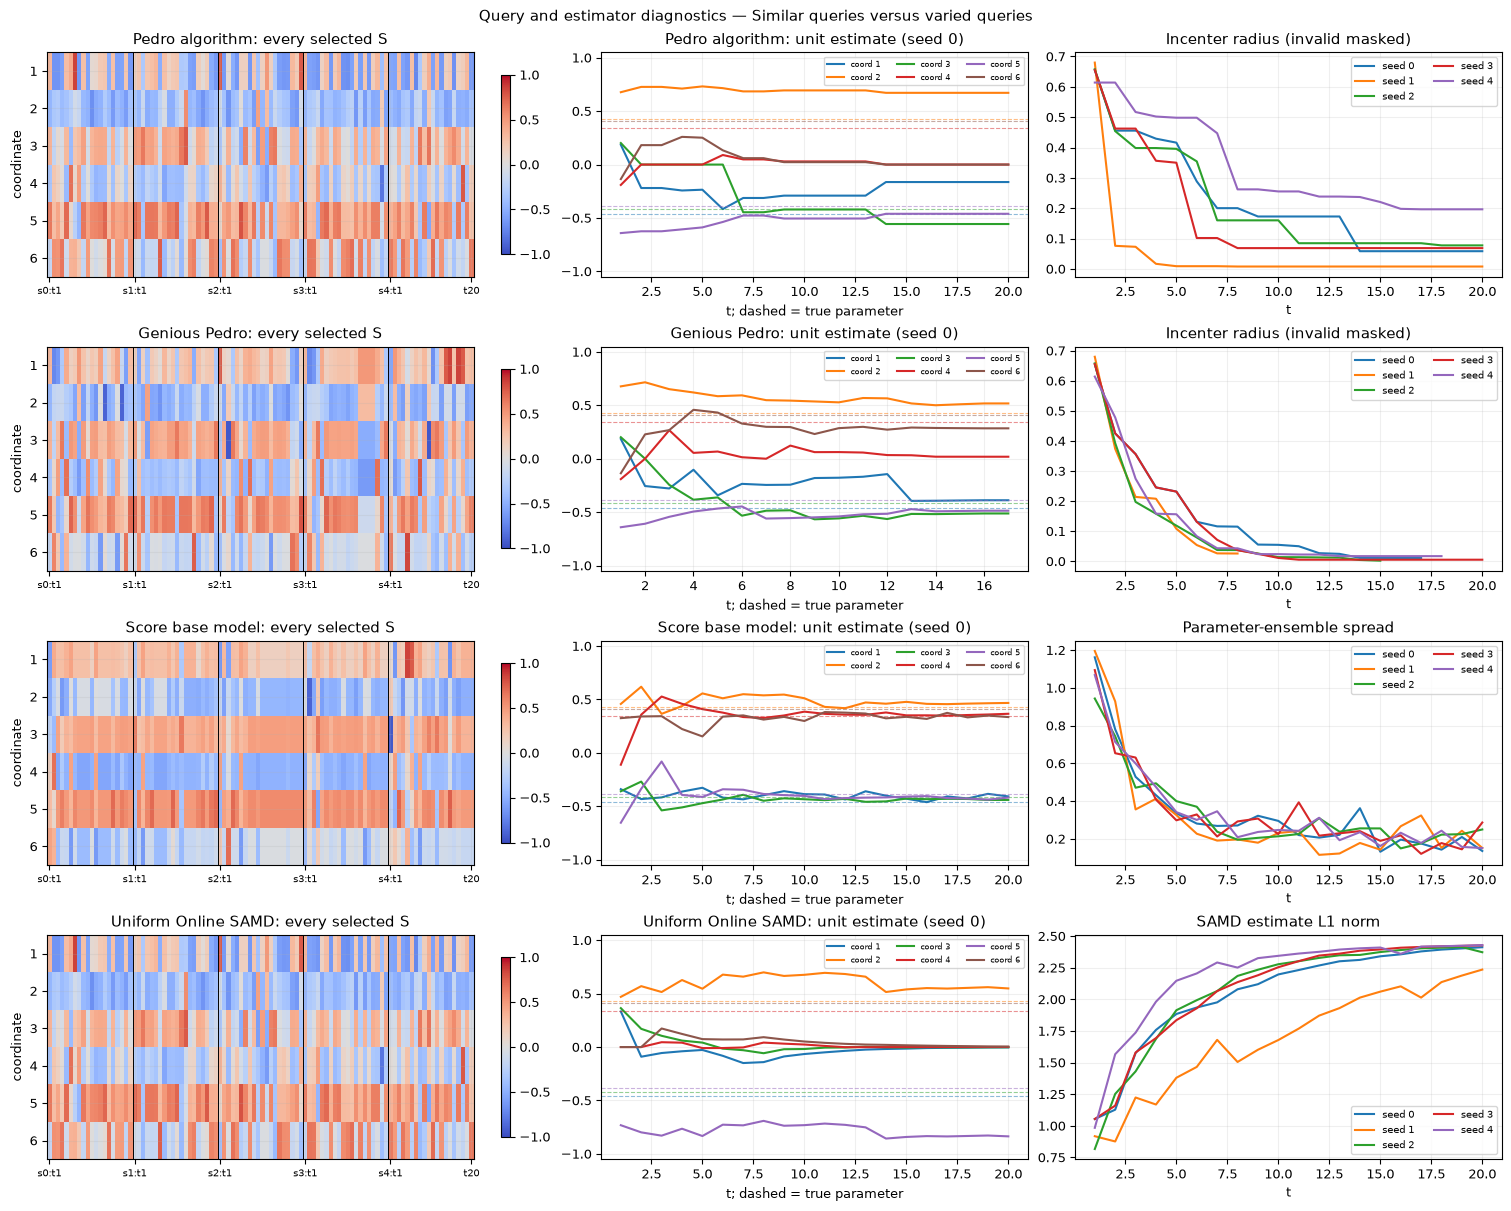

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,profile 1,profile 2,diverse
0,0,Pedro algorithm,valid,NaN,1,8,9,3
1,0,Genious Pedro,degenerate_cone,18.0,1,2,9,9
2,0,Score base model,valid,NaN,5,1,7,12
3,0,Uniform Online SAMD,valid,NaN,1,8,9,3
4,1,Pedro algorithm,valid,NaN,0,5,11,4
5,1,Genious Pedro,degenerate_cone,9.0,4,2,14,4
6,1,Score base model,valid,NaN,4,0,14,6
7,1,Uniform Online SAMD,valid,NaN,0,5,11,4
8,2,Pedro algorithm,valid,NaN,2,7,7,6
9,2,Genious Pedro,degenerate_cone,16.0,1,2,11,7


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[0.1847, 0.6774, 0.2015, -0.1908, -0.6415, -0.1359]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",75.59069,0.11745,valid,None,0.19756
1,Pedro algorithm,"[0.1847, 0.6774, 0.2015, -0.1908, -0.6415, -0.1359]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",75.59069,0.11745,valid,None,0.19756
1,Score base model,"[-0.3382, 0.4564, -0.3577, -0.1103, -0.6512, 0.3240]","[-0.6045, -0.5253, -0.2212, 0.1514, 0.2919, 0.4490]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",31.86237,0.02413,valid,None,0.02403
1,Uniform Online SAMD,"[0.1849, 0.2609, 0.2022, 0.0000, -0.4061, 0.0000]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",79.65753,0.26365,valid,None,0.28068
2,Genious Pedro,"[-0.2557, 0.7156, -0.0000, -0.0000, -0.6087, 0.2281]","[-0.7131, -0.1842, -0.2006, 0.0866, 0.2220, 0.6004]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",41.21856,0.02994,valid,None,0.04216
2,Pedro algorithm,"[-0.2196, 0.7270, -0.0000, 0.0000, -0.6246, 0.1818]","[-0.6557, -0.3170, -0.1799, 0.2281, 0.2936, 0.5468]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.29710,0.02727,valid,None,0.03508
2,Score base model,"[-0.4367, 0.6258, -0.2714, 0.3613, -0.3393, 0.3444]","[0.3997, -0.2628, -0.4175, 0.6797, 0.0901, 0.3560]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000]",14.79614,0.00705,valid,None,0.00676
2,Uniform Online SAMD,"[-0.0625, 0.3945, 0.1181, 0.0000, -0.5526, 0.0000]","[-0.6557, -0.3170, -0.1799, 0.2281, 0.2936, 0.5468]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",58.46284,0.07660,valid,None,0.11402
3,Genious Pedro,"[-0.2785, 0.6511, -0.2447, 0.2667, -0.5439, 0.2678]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",23.18720,0.00813,valid,None,0.00952
3,Pedro algorithm,"[-0.2196, 0.7270, -0.0000, -0.0000, -0.6246, 0.1818]","[-0.6525, -0.2888, 0.0595, 0.1452, 0.4330, 0.5280]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.29710,0.02994,valid,None,0.03747


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[0.0789, -0.1868, -0.6870, -0.1547, -0.6783, -0.0535]","[0.1556, -0.3222, 0.5063, -0.2670, 0.7327, -0.0867]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",70.12235,0.41690,valid,None,0.43296
1,Pedro algorithm,"[0.0789, -0.1868, -0.6870, -0.1547, -0.6783, -0.0535]","[0.1556, -0.3222, 0.5063, -0.2670, 0.7327, -0.0867]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",70.12235,0.41690,valid,None,0.43296
1,Score base model,"[0.0333, -0.0607, -0.5984, -0.1480, -0.2453, 0.4897]","[-0.3078, -0.1377, 0.6438, -0.4188, -0.3375, -0.4272]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",54.44607,0.33183,valid,None,0.32958
1,Uniform Online SAMD,"[0.0758, -0.1609, -0.2648, 0.0000, -0.4164, 0.0000]","[0.1556, -0.3222, 0.5063, -0.2670, 0.7327, -0.0867]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",73.00007,0.39579,valid,None,0.39566
2,Genious Pedro,"[-0.2002, 0.3596, -0.6720, 0.1375, -0.5666, 0.1975]","[-0.5568, -0.4073, -0.0087, 0.2822, 0.3879, 0.5421]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",29.22780,0.08068,valid,None,0.06921
2,Pedro algorithm,"[-0.0000, 0.6772, -0.6296, -0.0000, -0.3809, -0.0000]","[0.2398, -0.4419, 0.4778, -0.3288, 0.6315, -0.1096]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",43.04855,0.06075,valid,None,0.09216
2,Score base model,"[-0.1398, 0.5924, -0.5479, -0.3463, -0.4654, 0.6304]","[0.2647, -0.5424, 0.2621, -0.4462, 0.5774, -0.1859]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",40.98707,0.05208,valid,None,0.04143
2,Uniform Online SAMD,"[0.0750, 0.0193, -0.5460, -0.1320, -0.1042, 0.0000]","[0.2398, -0.4419, 0.4778, -0.3288, 0.6315, -0.1096]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",67.73113,0.39442,valid,None,0.38835
3,Genious Pedro,"[-0.0000, 0.5815, -0.6239, -0.0000, -0.5221, -0.0000]","[0.1447, -0.5533, 0.2998, -0.3737, 0.6527, -0.1317]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.17294,0.06687,valid,None,0.09516
3,Pedro algorithm,"[-0.0000, 0.6489, -0.6033, -0.0000, -0.3651, 0.2857]","[-0.3078, -0.1377, 0.6438, -0.4188, -0.3375, -0.4272]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",34.00346,0.03302,valid,None,0.02746


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.6564, -0.0497, -0.2371, 0.2609, 0.0503, 0.6632]","[0.7658, -0.0851, -0.3308, 0.3742, 0.0874, -0.3864]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",45.80832,0.35577,valid,None,0.31816
1,Pedro algorithm,"[-0.6564, -0.0497, -0.2371, 0.2609, 0.0503, 0.6632]","[0.7658, -0.0851, -0.3308, 0.3742, 0.0874, -0.3864]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",45.80832,0.35577,valid,None,0.31816
1,Score base model,"[-0.4348, 0.3359, -0.4625, 0.4635, -0.4496, 0.1084]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",18.28857,0.03458,valid,None,0.03009
1,Uniform Online SAMD,"[-0.4250, -0.0403, -0.1611, 0.0000, 0.0000, 0.1903]","[0.7658, -0.0851, -0.3308, 0.3742, 0.0874, -0.3864]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",52.28313,0.41556,valid,None,0.39657
2,Genious Pedro,"[-0.4535, 0.5233, -0.0000, 0.0302, -0.5015, 0.5177]","[0.1392, -0.5375, 0.4046, -0.3488, 0.6362, -0.0400]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",36.23605,0.02973,valid,None,0.04424
2,Pedro algorithm,"[-0.5088, 0.4531, -0.0347, 0.0803, -0.4532, 0.5682]","[-0.6225, -0.3669, -0.0149, 0.1287, 0.4259, 0.5288]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",33.23919,0.02651,valid,None,0.03837
2,Score base model,"[-0.3316, 0.6670, -0.7366, 0.3208, -0.2260, 0.2625]","[0.3244, -0.5851, 0.3994, -0.3954, 0.4629, -0.1493]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",21.49682,0.05114,valid,None,0.04149
2,Uniform Online SAMD,"[-0.4004, 0.1767, -0.1611, 0.0734, -0.2615, 0.1793]","[-0.6225, -0.3669, -0.0149, 0.1287, 0.4259, 0.5288]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",27.11650,0.03532,valid,None,0.04131
3,Genious Pedro,"[-0.2597, 0.5492, -0.2286, 0.4836, -0.4903, 0.3232]","[0.0751, 0.2050, -0.9444, 0.1200, -0.1957, 0.0885]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",18.94622,0.01590,valid,None,0.00882
3,Pedro algorithm,"[-0.4573, 0.4553, 0.0040, -0.0286, -0.4938, 0.5822]","[0.0376, -0.6535, 0.3697, -0.4209, 0.5073, -0.0183]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",39.30939,0.04227,valid,None,0.06505


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[0.1847, 0.6774, 0.2015, -0.1908, -0.6415, -0.1359]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",75.57595,0.11557,valid,None,0.19778
1,Pedro algorithm,"[0.1847, 0.6774, 0.2015, -0.1908, -0.6415, -0.1359]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",75.57595,0.11557,valid,None,0.19778
1,Score base model,"[0.3839, 0.0047, 0.2398, 0.4415, 0.2322, 0.4986]","[0.2792, -0.0400, 0.4462, -0.5479, 0.5025, -0.4106]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000]",84.04847,0.67337,valid,None,0.65705
1,Uniform Online SAMD,"[0.1849, 0.2609, 0.2022, 0.0000, -0.4061, 0.0000]","[0.3306, -0.4497, 0.3587, -0.3407, 0.6452, -0.1658]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",77.78762,0.23898,valid,None,0.25663
2,Genious Pedro,"[-0.2557, 0.7156, -0.0000, -0.0000, -0.6087, 0.2281]","[-0.7131, -0.1842, -0.2006, 0.0866, 0.2220, 0.6004]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",42.09113,0.02926,valid,None,0.04334
2,Pedro algorithm,"[-0.2005, 0.7213, -0.0000, 0.0000, -0.6224, 0.2283]","[-0.5750, -0.3101, -0.1529, 0.1678, 0.2948, 0.6594]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.13989,0.02630,valid,None,0.03332
2,Score base model,"[-0.2991, 0.4817, 0.2088, 0.6914, -0.2255, 0.7245]","[-0.1515, -0.8894, 0.2859, 0.0764, 0.3109, 0.0422]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",38.55727,0.13510,valid,None,0.14553
2,Uniform Online SAMD,"[-0.0614, 0.4078, 0.1180, 0.0000, -0.5725, 0.0000]","[-0.5750, -0.3101, -0.1529, 0.1678, 0.2948, 0.6594]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",59.10959,0.07505,valid,None,0.11427
3,Genious Pedro,"[-0.2785, 0.6511, -0.2447, 0.2667, -0.5439, 0.2678]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",23.43214,0.00689,valid,None,0.00827
3,Pedro algorithm,"[-0.2005, 0.7213, -0.0000, 0.0000, -0.6224, 0.2283]","[-0.5972, -0.2669, -0.0123, 0.1948, 0.3304, 0.6518]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",43.13990,0.02630,valid,None,0.03476


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason,balanced regret
1,Genious Pedro,"[-0.3329, 0.6132, -0.0681, 0.0332, -0.6152, 0.3590]","[-0.5478, -0.4056, -0.0854, 0.0261, 0.3553, 0.6333]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",34.05214,0.01294,valid,None,0.03328
1,Pedro algorithm,"[-0.3329, 0.6132, -0.0681, 0.0332, -0.6152, 0.3590]","[-0.5478, -0.4056, -0.0854, 0.0261, 0.3553, 0.6333]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",34.05214,0.01294,valid,None,0.03328
1,Score base model,"[-0.2046, 0.3823, -0.3179, 0.2906, -0.2420, -0.5041]","[0.0751, 0.2050, -0.9444, 0.1200, -0.1957, 0.0885]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",65.20047,0.28851,valid,None,0.29948
1,Uniform Online SAMD,"[-0.4077, 0.2810, -0.0543, 0.0000, -0.2411, 0.0000]","[-0.5478, -0.4056, -0.0854, 0.0261, 0.3553, 0.6333]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",47.33128,0.03944,valid,None,0.05564
2,Genious Pedro,"[-0.4880, 0.4485, -0.1909, 0.4862, -0.4460, 0.2982]","[0.5026, 0.3013, -0.5112, -0.6164, -0.1226, -0.0161]","[1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",15.20247,0.00361,valid,None,0.00046
2,Pedro algorithm,"[-0.3324, 0.6138, -0.0651, 0.0235, -0.6159, 0.3586]","[-0.5643, -0.4801, -0.0686, 0.0059, 0.4457, 0.4976]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",34.59281,0.01294,valid,None,0.03328
2,Score base model,"[-0.3982, 0.6399, -0.5175, 0.4738, -0.5621, 0.0922]","[-0.6345, -0.1550, 0.2997, 0.4714, -0.4594, 0.2243]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",23.81676,0.01006,valid,None,0.01967
2,Uniform Online SAMD,"[-0.3216, 0.5346, -0.0428, 0.0023, -0.4551, 0.2100]","[-0.5643, -0.4801, -0.0686, 0.0059, 0.4457, 0.4976]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",37.66936,0.01895,valid,None,0.03827
3,Genious Pedro,"[-0.2807, 0.6182, -0.2233, 0.6341, -0.2287, 0.1865]","[0.3635, -0.4941, 0.3537, -0.4764, 0.4955, -0.1618]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",25.23094,0.08258,valid,None,0.07804
3,Pedro algorithm,"[-0.1869, 0.6913, -0.0000, -0.0000, -0.6619, 0.2214]","[0.2888, -0.5283, 0.3543, -0.2920, 0.6055, -0.2450]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",42.98963,0.03037,valid,None,0.05727


Completed scenario 3/8; 60/160 complete runs loaded.


In [5]:
run_and_show_family(2)

## 4. Ordinary balanced choice — 4D

The expert chooses one coordinate. Candidate queries are uniformly distributed unit directions. This is an ordinary control without deliberately rare or redundant query groups.

CACHED balanced-choice-4d seed=0 Pedro algorithm
CACHED balanced-choice-4d seed=0 Genious Pedro
CACHED balanced-choice-4d seed=0 Score base model
CACHED balanced-choice-4d seed=0 Uniform Online SAMD
CACHED balanced-choice-4d seed=1 Pedro algorithm
CACHED balanced-choice-4d seed=1 Genious Pedro
CACHED balanced-choice-4d seed=1 Score base model
CACHED balanced-choice-4d seed=1 Uniform Online SAMD
CACHED balanced-choice-4d seed=2 Pedro algorithm
CACHED balanced-choice-4d seed=2 Genious Pedro
CACHED balanced-choice-4d seed=2 Score base model
CACHED balanced-choice-4d seed=2 Uniform Online SAMD
CACHED balanced-choice-4d seed=3 Pedro algorithm
CACHED balanced-choice-4d seed=3 Genious Pedro
CACHED balanced-choice-4d seed=3 Score base model


CACHED balanced-choice-4d seed=3 Uniform Online SAMD


CACHED balanced-choice-4d seed=4 Pedro algorithm
CACHED balanced-choice-4d seed=4 Genious Pedro
CACHED balanced-choice-4d seed=4 Score base model
CACHED balanced-choice-4d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,10.6737,6.1094,0.0101,0.0095,0,3,0.0764
1,Genious Pedro,ordinary,2/5,3,1.6722,0.0191,0.0005,0.0005,2,2,0.2458
2,Score base model,ordinary,5/5,0,2.0080,0.8352,0.0004,0.0005,5,5,14.2670
3,Uniform Online SAMD,ordinary,5/5,0,37.2384,10.4084,0.0805,0.0400,0,0,0.0042


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,52.3440,16.4912,0.2249,0.2183,5/5,52.3440,16.4912,0.2249,0.2183,5/5,59.6548,17.6088,0.3039,0.2079,5/5,63.3037,13.3576,0.3065,0.1168
1,2,5/5,34.9566,11.6538,0.0786,0.0863,5/5,32.9751,12.0904,0.0963,0.0719,5/5,52.3316,17.3387,0.2565,0.1670,5/5,44.3168,10.1410,0.1417,0.0749
2,3,5/5,33.1702,13.0894,0.0960,0.0742,5/5,27.5162,7.6247,0.0582,0.0280,5/5,22.9724,15.8865,0.0780,0.0858,5/5,41.6503,11.7379,0.1486,0.0735
3,4,5/5,30.1906,13.9127,0.0912,0.0783,5/5,27.9065,7.0844,0.0626,0.0340,5/5,13.0147,4.7723,0.0125,0.0060,5/5,37.6516,2.7632,0.0954,0.0080
4,5,5/5,31.7544,13.6805,0.1054,0.0811,5/5,19.6272,11.8902,0.0374,0.0393,5/5,8.7967,2.5775,0.0084,0.0043,5/5,38.2919,6.3537,0.1017,0.0249
5,6,5/5,30.8596,13.9472,0.0969,0.0717,5/5,21.7054,12.4238,0.0405,0.0440,5/5,7.0595,2.3384,0.0042,0.0021,5/5,36.3026,5.1553,0.0849,0.0140
6,7,5/5,26.1551,15.0253,0.0812,0.0815,5/5,19.6228,12.6547,0.0360,0.0402,5/5,7.8296,3.0054,0.0062,0.0044,5/5,33.2909,9.2362,0.0803,0.0337
7,8,5/5,24.5413,16.4363,0.0766,0.0867,5/5,15.9146,11.7285,0.0307,0.0367,5/5,6.3929,1.9714,0.0038,0.0012,5/5,34.6656,4.3552,0.0735,0.0275
8,9,5/5,12.9436,5.3149,0.0122,0.0105,5/5,14.5127,9.5283,0.0211,0.0178,5/5,6.2606,3.6876,0.0041,0.0043,5/5,33.0911,7.9351,0.0718,0.0308
9,10,5/5,13.1615,5.2084,0.0126,0.0102,5/5,13.1601,9.8583,0.0176,0.0154,5/5,5.7404,2.5969,0.0028,0.0019,5/5,36.9426,9.4757,0.0847,0.0386


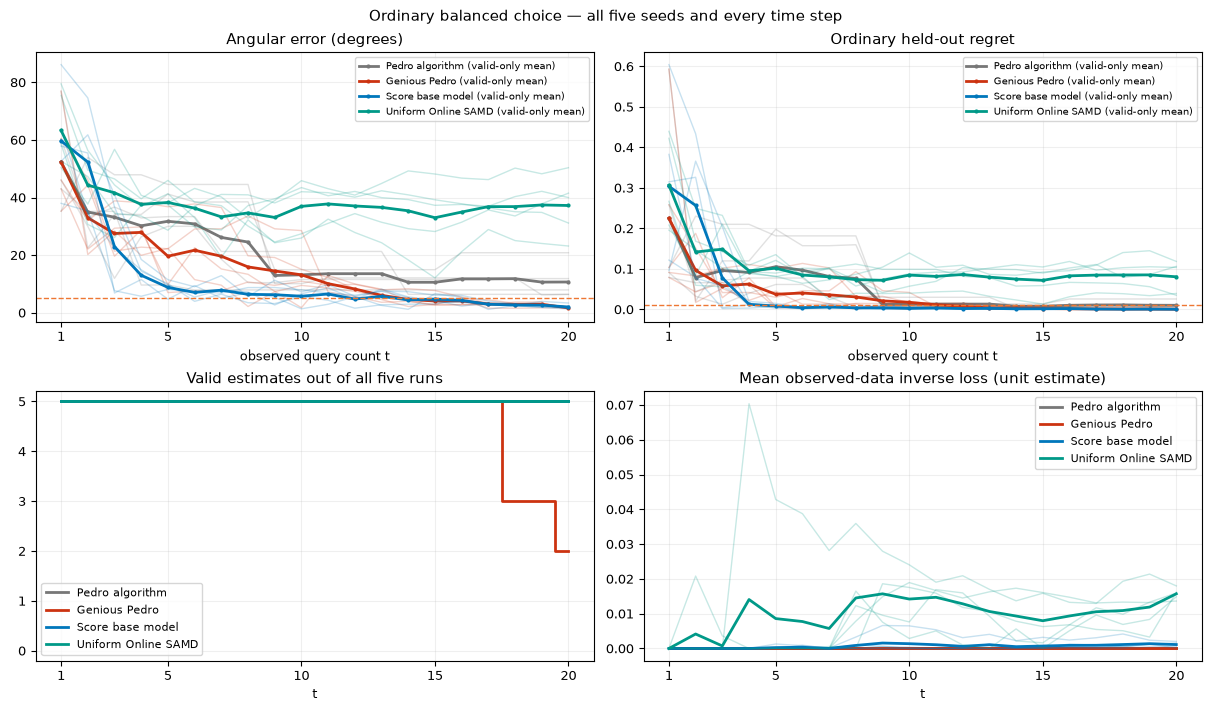

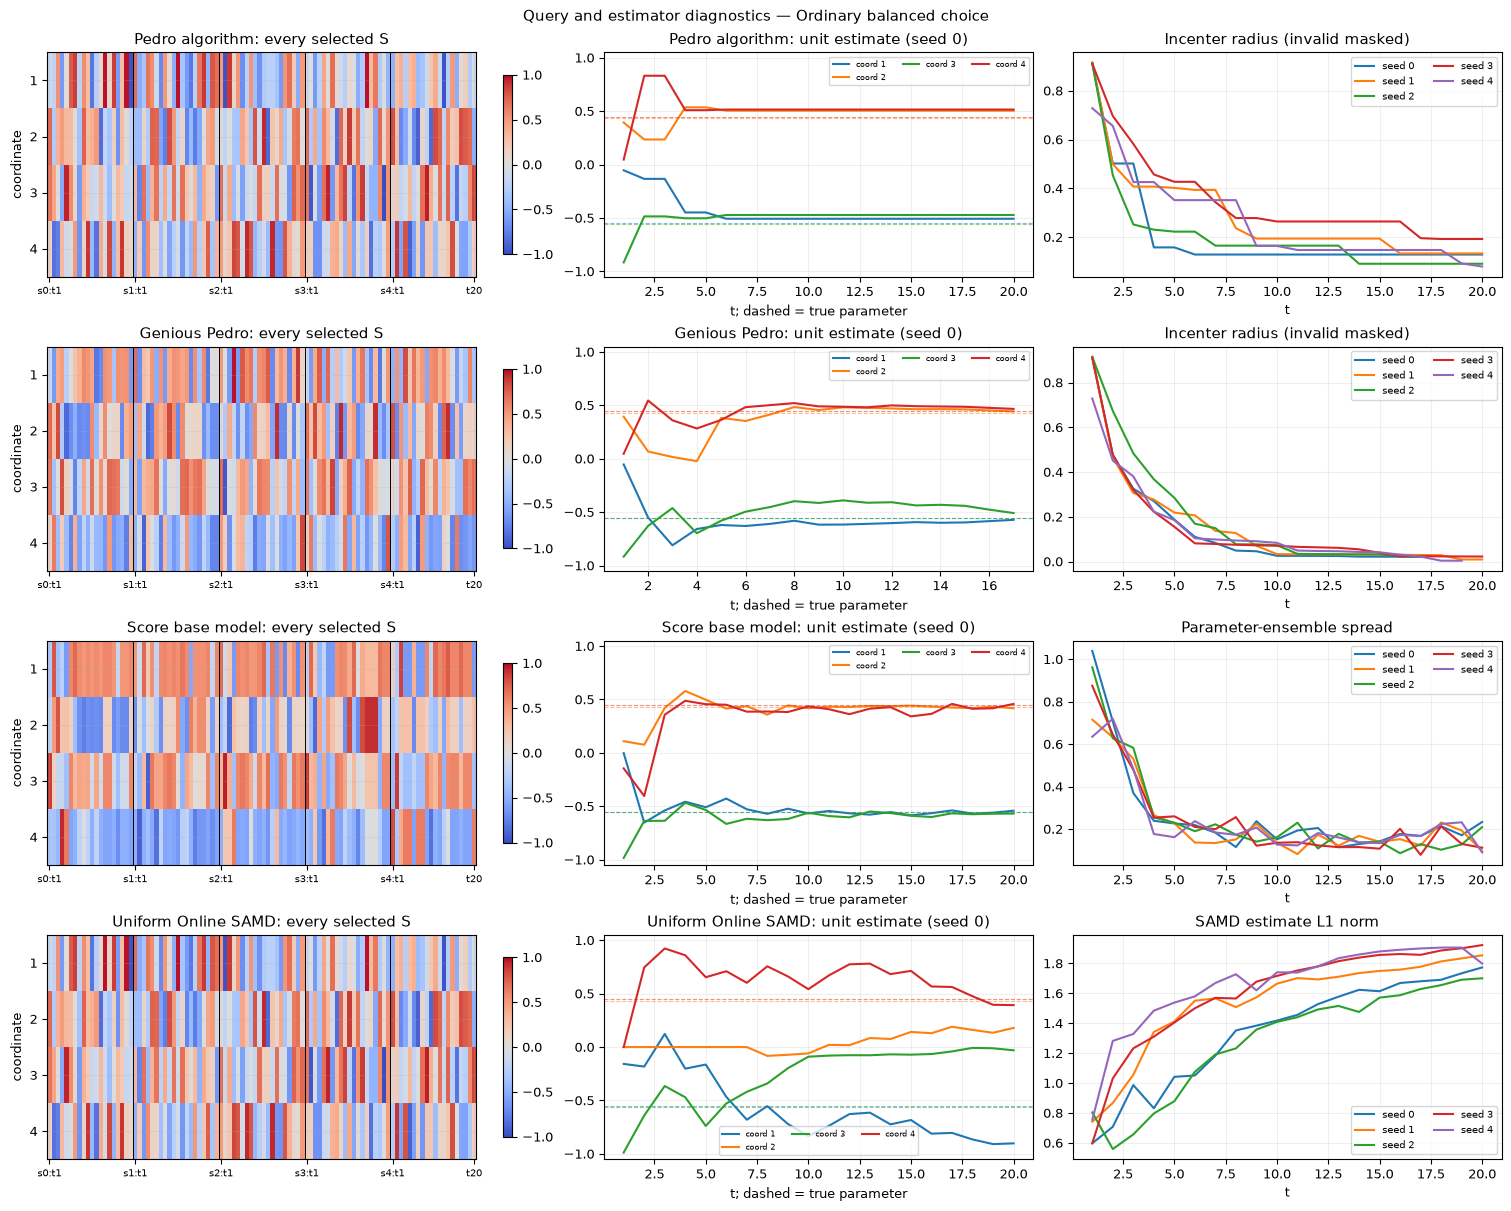

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,NaN,0,20
1,0,Genious Pedro,degenerate_cone,18.0,1,20
2,0,Score base model,valid,NaN,2,20
3,0,Uniform Online SAMD,valid,NaN,0,20
4,1,Pedro algorithm,valid,NaN,0,20
5,1,Genious Pedro,valid,NaN,0,20
6,1,Score base model,valid,NaN,3,20
7,1,Uniform Online SAMD,valid,NaN,0,20
8,2,Pedro algorithm,valid,NaN,0,20
9,2,Genious Pedro,degenerate_cone,18.0,1,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Score base model,"[-0.0012, 0.0561, -0.5049, -0.0743]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",57.86244,0.31490,valid,None
1,Uniform Online SAMD,"[-0.0824, 0.0000, -0.5154, 0.0000]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",50.39906,0.20824,valid,None
2,Genious Pedro,"[-0.5498, 0.0679, -0.6292, 0.5452]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",22.11671,0.04320,valid,None
2,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
2,Score base model,"[-0.5286, 0.0620, -0.5161, -0.3273]","[0.7870, 0.4912, 0.1455, -0.3439]","[1.0000, 0.0000, 0.0000, 0.0000]",55.47425,0.32613,valid,None
2,Uniform Online SAMD,"[-0.0824, 0.0000, -0.2891, 0.3366]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",37.72622,0.08412,valid,None
3,Genious Pedro,"[-0.8106, 0.0163, -0.4620, 0.3596]","[0.4051, 0.8227, -0.0052, -0.3988]","[1.0000, 0.0000, 0.0000, 0.0000]",29.35701,0.06660,valid,None
3,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[0.5341, 0.3739, 0.0193, -0.7580]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Pedro algorithm,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Score base model,"[0.0756, 0.5560, -0.1425, -0.1004]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",63.66072,0.38259,valid,None
1,Uniform Online SAMD,"[-0.5010, -0.2409, 0.0000, 0.0000]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",75.47588,0.43946,valid,None
2,Genious Pedro,"[-0.7569, 0.4230, -0.4324, 0.2475]","[-0.6856, 0.4262, -0.5830, -0.0920]","[0.0000, 0.0000, 0.0000, 1.0000]",20.21652,0.01704,valid,None
2,Pedro algorithm,"[-0.7957, 0.4237, -0.3355, 0.2735]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",22.51927,0.02074,valid,None
2,Score base model,"[-0.0106, 0.6560, -0.2947, 0.4854]","[-0.0988, -0.0372, -0.4371, -0.8932]","[0.0000, 0.0000, 0.0000, 1.0000]",34.46721,0.07708,valid,None
2,Uniform Online SAMD,"[-0.4882, -0.0601, -0.3189, 0.0000]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",49.50855,0.24969,valid,None
3,Genious Pedro,"[-0.7670, 0.1899, -0.2199, 0.5720]","[0.2912, -0.1064, 0.3235, -0.8940]","[0.0000, 0.0000, 0.0000, 1.0000]",28.37319,0.05205,valid,None
3,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[-0.3454, 0.1053, 0.6798, -0.6383]","[0.0000, 0.0000, 1.0000, 0.0000]",34.13039,0.11974,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Pedro algorithm,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Score base model,"[-0.5578, -0.2865, 0.0487, -0.0538]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",86.15365,0.60416,valid,None
1,Uniform Online SAMD,"[0.3138, 0.0000, -0.4902, 0.0000]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",79.48034,0.42236,valid,None
2,Genious Pedro,"[0.2250, 0.6771, -0.6636, 0.2248]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",46.23284,0.15127,valid,None
2,Pedro algorithm,"[-0.3673, 0.4471, -0.8076, 0.1135]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",33.12903,0.04375,valid,None
2,Score base model,"[-0.6272, -0.1229, -0.3114, -0.2712]","[-0.1004, -0.1892, 0.9506, 0.2248]","[0.0000, 0.0000, 1.0000, 0.0000]",74.59635,0.43358,valid,None
2,Uniform Online SAMD,"[-0.0051, 0.0641, -0.4902, 0.0000]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",56.39012,0.16838,valid,None
3,Genious Pedro,"[-0.0943, 0.4820, -0.6543, 0.5751]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",21.37050,0.04159,valid,None
3,Pedro algorithm,"[-0.6235, 0.2288, -0.7401, 0.1055]","[0.8838, -0.0047, 0.4124, 0.2210]","[1.0000, 0.0000, 0.0000, 0.0000]",36.68532,0.07180,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Score base model,"[-0.0515, 0.0890, -0.6106, 0.0477]","[-0.2201, 0.0172, 0.9032, -0.3680]","[0.0000, 0.0000, 1.0000, 0.0000]",52.60040,0.09599,valid,None
1,Uniform Online SAMD,"[-0.0824, 0.0000, -0.5154, 0.0000]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",58.58716,0.26679,valid,None
2,Genious Pedro,"[-0.5498, 0.0679, -0.6292, 0.5452]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",32.04731,0.08259,valid,None
2,Pedro algorithm,"[-0.1337, 0.6943, -0.6835, 0.1814]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",29.99334,0.03234,valid,None
2,Score base model,"[-0.6571, 0.1131, -0.5177, -0.3340]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",61.77641,0.36594,valid,None
2,Uniform Online SAMD,"[-0.0768, 0.3135, -0.4800, 0.1614]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",30.66605,0.05962,valid,None
3,Genious Pedro,"[-0.3487, -0.0003, -0.4715, 0.8100]","[0.4051, 0.8227, -0.0052, -0.3988]","[0.0000, 0.0000, 0.0000, 1.0000]",38.85017,0.10163,valid,None
3,Pedro algorithm,"[-0.2664, 0.5778, -0.5424, 0.5486]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",11.93554,0.01270,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Pedro algorithm,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Score base model,"[0.0611, 0.5142, -0.0831, 0.4168]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",37.99676,0.12178,valid,None
1,Uniform Online SAMD,"[-0.4990, 0.0000, 0.0000, 0.2558]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",52.57606,0.19569,valid,None
2,Genious Pedro,"[-0.2942, 0.8334, 0.2521, 0.3942]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",44.26195,0.18764,valid,None
2,Pedro algorithm,"[-0.4874, 0.5105, 0.4492, 0.5478]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",53.94416,0.23011,valid,None
2,Score base model,"[0.1325, 0.5305, -0.5166, 0.4185]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",35.34367,0.07978,valid,None
2,Uniform Online SAMD,"[-0.8436, 0.2458, 0.0000, 0.1929]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",47.29323,0.14681,valid,None
3,Genious Pedro,"[-0.3997, 0.7843, -0.1589, 0.4470]","[-0.4566, 0.5295, 0.5348, 0.4744]","[0.0000, 0.0000, 1.0000, 0.0000]",19.62997,0.02889,valid,None
3,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[0.3767, -0.7055, -0.1865, -0.5706]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None


Completed scenario 4/8; 80/160 complete runs loaded.


In [6]:
run_and_show_family(3)

## 5. Ordinary subset selection — 6D

The expert chooses exactly three of six coordinates. Dense random unit queries expose multiple comparisons in each response. Pedro may be competitive because individual responses contain several constraints.

CACHED balanced-subset-6d seed=0 Pedro algorithm
CACHED balanced-subset-6d seed=0 Genious Pedro
CACHED balanced-subset-6d seed=0 Score base model
CACHED balanced-subset-6d seed=0 Uniform Online SAMD
CACHED balanced-subset-6d seed=1 Pedro algorithm
CACHED balanced-subset-6d seed=1 Genious Pedro
CACHED balanced-subset-6d seed=1 Score base model
CACHED balanced-subset-6d seed=1 Uniform Online SAMD
CACHED balanced-subset-6d seed=2 Pedro algorithm
CACHED balanced-subset-6d seed=2 Genious Pedro
CACHED balanced-subset-6d seed=2 Score base model
CACHED balanced-subset-6d seed=2 Uniform Online SAMD
CACHED balanced-subset-6d seed=3 Pedro algorithm


CACHED balanced-subset-6d seed=3 Genious Pedro
CACHED balanced-subset-6d seed=3 Score base model


CACHED balanced-subset-6d seed=3 Uniform Online SAMD
CACHED balanced-subset-6d seed=4 Pedro algorithm
CACHED balanced-subset-6d seed=4 Genious Pedro
CACHED balanced-subset-6d seed=4 Score base model
CACHED balanced-subset-6d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,9.0364,3.6632,0.0017,0.0009,1,5,0.0991
1,Genious Pedro,ordinary,3/5,2,4.7524,1.3897,0.0005,0.0001,1,3,0.2489
2,Score base model,ordinary,5/5,0,3.2693,1.3491,0.0003,0.0002,4,5,12.2896
3,Uniform Online SAMD,ordinary,5/5,0,34.3751,8.5746,0.0320,0.0126,0,0,0.0040


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,29.1895,11.4187,0.1030,0.0918,5/5,29.1895,11.4187,0.1030,0.0918,5/5,32.5051,13.0781,0.0986,0.0669,5/5,36.3115,7.9279,0.0985,0.0734
1,2,5/5,22.5166,16.3656,0.0694,0.0899,5/5,17.0924,5.0271,0.0174,0.0253,5/5,21.4641,5.7050,0.0192,0.0181,5/5,26.9843,12.2299,0.0539,0.0635
2,3,5/5,17.7221,4.3351,0.0205,0.0164,5/5,17.8868,5.0404,0.0143,0.0087,5/5,14.7390,5.8529,0.0130,0.0186,5/5,27.8073,8.8009,0.0357,0.0407
3,4,5/5,15.8064,5.3438,0.0106,0.0099,5/5,16.1198,1.9248,0.0083,0.0058,5/5,9.8395,3.7777,0.0022,0.0013,5/5,28.6799,12.2300,0.0271,0.0186
4,5,5/5,17.1254,7.7130,0.0233,0.0353,5/5,12.5324,2.7914,0.0044,0.0030,5/5,8.4144,1.9347,0.0016,0.0010,5/5,27.6154,10.8325,0.0266,0.0161
5,6,5/5,16.1230,8.7794,0.0234,0.0352,5/5,13.2652,2.5019,0.0045,0.0022,5/5,9.3018,2.3255,0.0024,0.0027,5/5,28.3046,9.9026,0.0218,0.0124
6,7,5/5,16.3723,6.8693,0.0201,0.0357,5/5,11.4902,5.3706,0.0038,0.0032,5/5,6.9871,3.0490,0.0010,0.0009,5/5,29.1733,9.0255,0.0211,0.0082
7,8,5/5,16.2973,7.0142,0.0205,0.0355,5/5,8.5469,3.3352,0.0022,0.0012,5/5,6.4305,1.7316,0.0008,0.0006,5/5,29.3098,8.4008,0.0248,0.0062
8,9,5/5,15.9370,7.1991,0.0203,0.0356,5/5,7.7040,2.6857,0.0019,0.0016,5/5,7.5609,2.7867,0.0013,0.0008,5/5,30.2978,8.5208,0.0260,0.0056
9,10,5/5,14.7114,5.7386,0.0112,0.0171,5/5,7.2720,1.6170,0.0019,0.0014,5/5,5.6640,1.9885,0.0007,0.0006,5/5,29.8675,7.8398,0.0243,0.0073


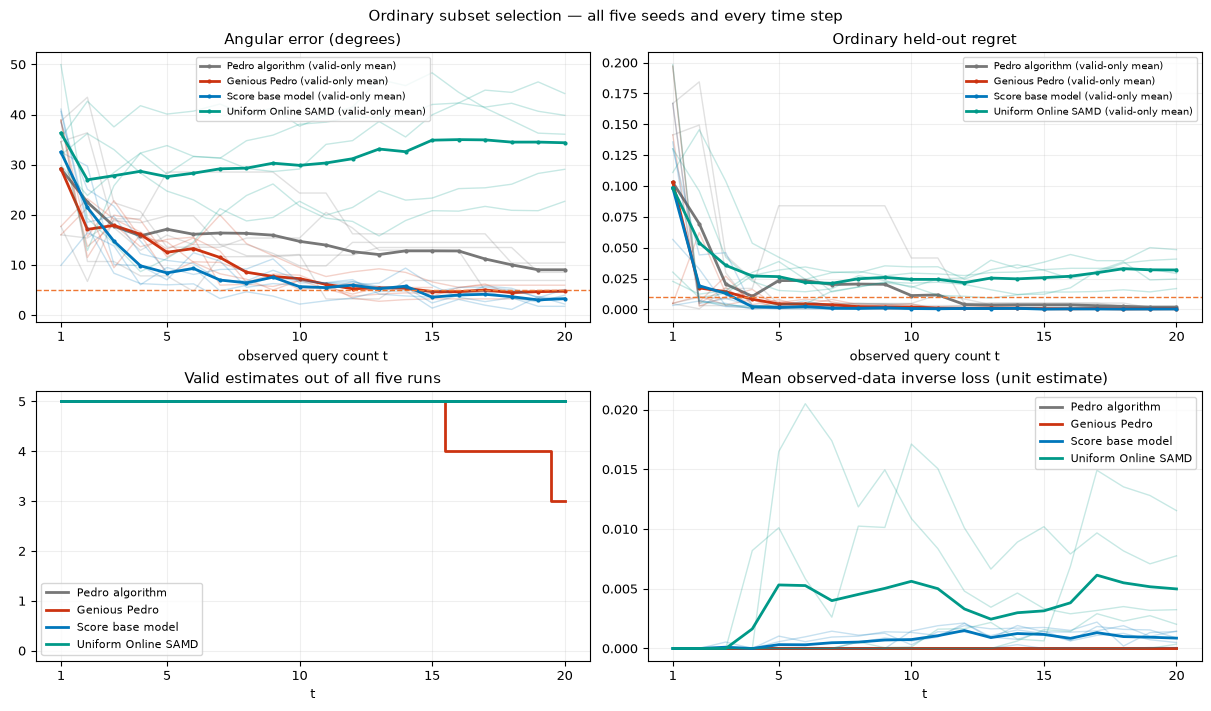

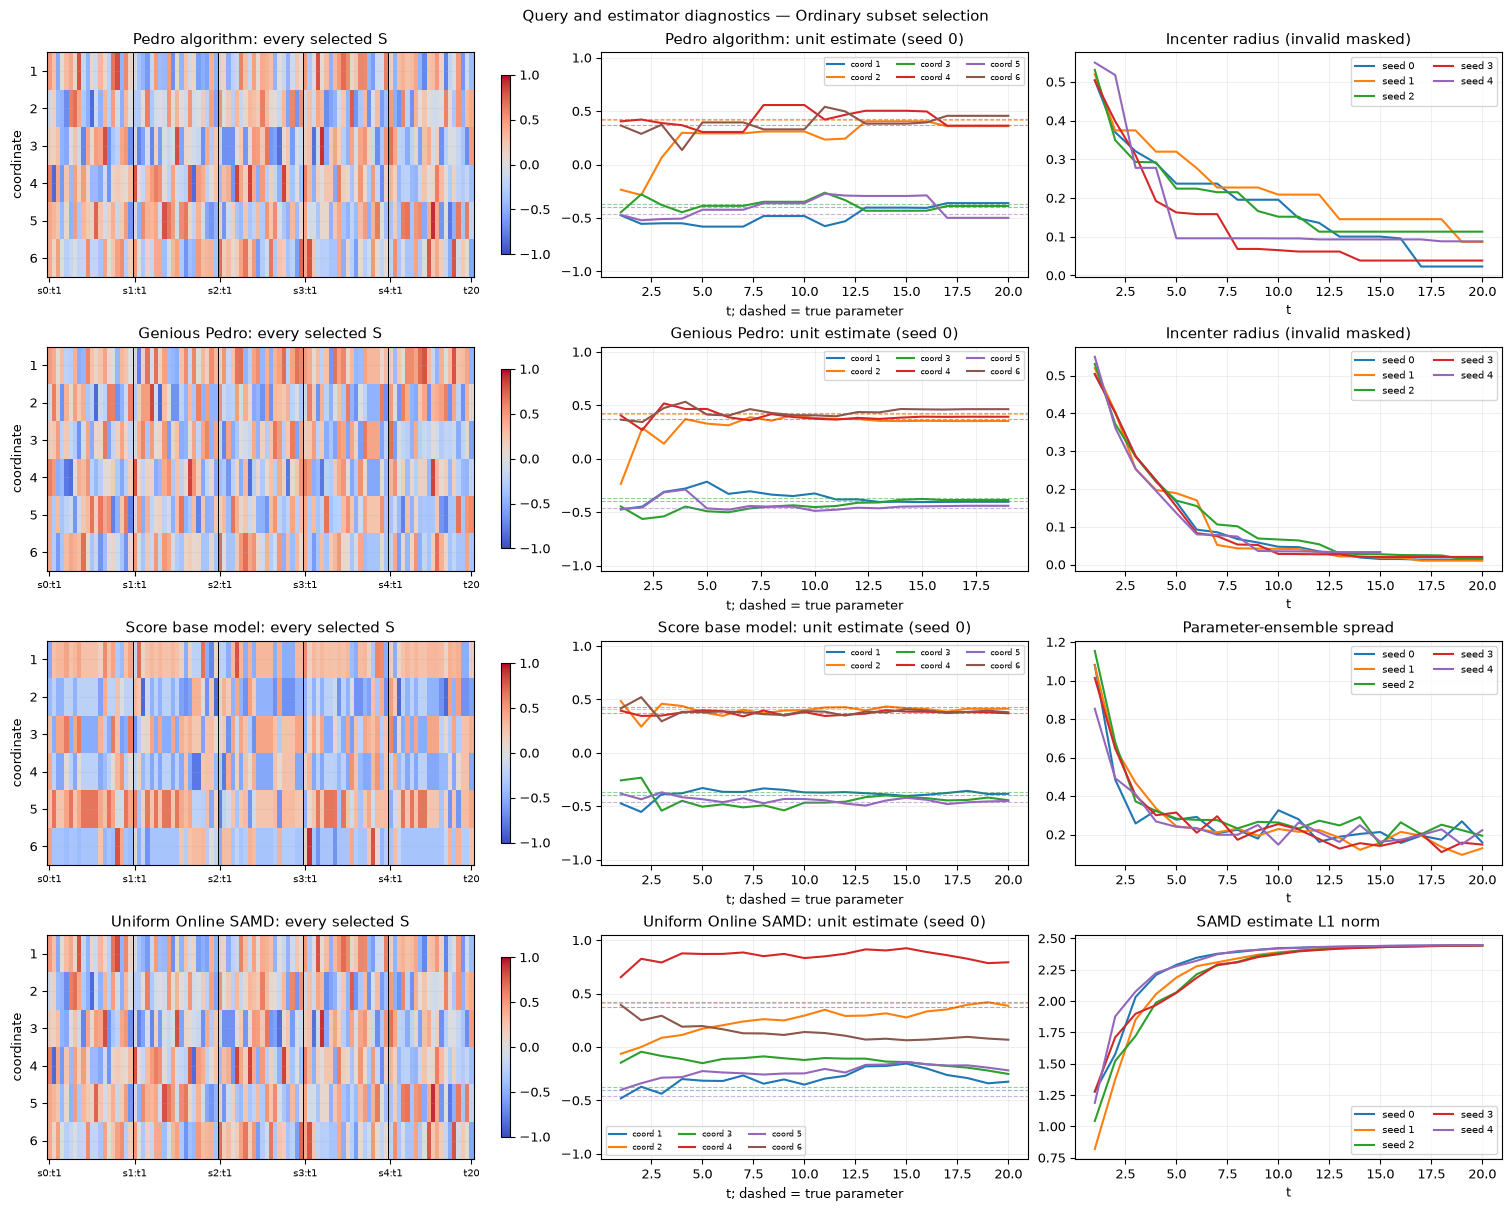

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,NaN,1,20
1,0,Genious Pedro,degenerate_cone,20.0,3,20
2,0,Score base model,valid,NaN,3,20
3,0,Uniform Online SAMD,valid,NaN,1,20
4,1,Pedro algorithm,valid,NaN,0,20
5,1,Genious Pedro,valid,NaN,1,20
6,1,Score base model,valid,NaN,3,20
7,1,Uniform Online SAMD,valid,NaN,0,20
8,2,Pedro algorithm,valid,NaN,0,20
9,2,Genious Pedro,valid,NaN,1,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4749, -0.2355, -0.4470, 0.4045, -0.4711, 0.3656]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",38.70216,0.16688,valid,None
1,Pedro algorithm,"[-0.4749, -0.2355, -0.4470, 0.4045, -0.4711, 0.3656]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",38.70216,0.16688,valid,None
1,Score base model,"[-0.4615, 0.4727, -0.2512, 0.3850, -0.3719, 0.4067]","[-0.5381, -0.4182, 0.2741, 0.4204, 0.2564, 0.4669]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",9.91975,0.00318,valid,None
1,Uniform Online SAMD,"[-0.2869, -0.0378, -0.0874, 0.3910, -0.2395, 0.2357]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",35.34163,0.13016,valid,None
2,Genious Pedro,"[-0.4479, 0.2874, -0.5642, 0.2688, -0.4564, 0.3435]","[0.3993, 0.6185, 0.2203, 0.4921, -0.3038, -0.2740]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",15.66150,0.00622,valid,None
2,Pedro algorithm,"[-0.5550, -0.2857, -0.2788, 0.4217, -0.5216, 0.2878]","[0.2878, 0.1423, 0.1452, -0.8669, 0.3395, 0.0956]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",43.45378,0.18441,valid,None
2,Score base model,"[-0.6093, 0.2706, -0.2562, 0.3818, -0.4788, 0.5751]","[0.2657, -0.2217, -0.5201, -0.2323, 0.6584, -0.3497]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 1.0000]",16.43845,0.00681,valid,None
2,Uniform Online SAMD,"[-0.3198, 0.0007, -0.0378, 0.7110, -0.2915, 0.2150]","[0.2878, 0.1423, 0.1452, -0.8669, 0.3395, 0.0956]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",42.65520,0.09587,valid,None
3,Genious Pedro,"[-0.3102, 0.1410, -0.5397, 0.5179, -0.3147, 0.4746]","[0.0536, 0.2097, 0.4744, -0.5123, 0.3015, -0.6122]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",22.81674,0.02697,valid,None
3,Pedro algorithm,"[-0.5499, 0.0642, -0.3780, 0.3885, -0.5105, 0.3730]","[-0.5381, -0.4182, 0.2741, 0.4204, 0.2564, 0.4669]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",22.42656,0.04377,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.5191, 0.4221, 0.1126, 0.5191, -0.0292, 0.5190]","[-0.0544, -0.2606, -0.0247, 0.8153, 0.0058, 0.5136]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",38.96063,0.19710,valid,None
1,Pedro algorithm,"[-0.5191, 0.4221, 0.1126, 0.5191, -0.0292, 0.5190]","[-0.0544, -0.2606, -0.0247, 0.8153, 0.0058, 0.5136]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",38.96063,0.19710,valid,None
1,Score base model,"[-0.2097, 0.3983, -0.4556, 0.4526, -0.4363, -0.2271]","[-0.1103, 0.3090, -0.6819, -0.1729, 0.6296, 0.0326]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 1.0000]",38.38701,0.13012,valid,None
1,Uniform Online SAMD,"[-0.0241, 0.1171, 0.0109, 0.4232, -0.0026, 0.2421]","[-0.0544, -0.2606, -0.0247, 0.8153, 0.0058, 0.5136]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",49.95621,0.19837,valid,None
2,Genious Pedro,"[-0.5902, 0.2895, -0.3231, 0.4140, -0.3400, 0.4200]","[-0.7535, 0.1846, 0.3795, 0.0829, 0.4919, -0.0729]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 1.0000]",11.50107,0.00267,valid,None
2,Pedro algorithm,"[-0.5830, 0.2609, -0.3786, 0.3862, -0.3808, 0.3932]","[-0.3543, -0.2921, -0.7413, 0.0079, -0.4889, -0.0242]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000]",10.68327,0.00309,valid,None
2,Score base model,"[-0.6376, 0.6264, -0.5033, 0.0414, -0.4548, 0.4101]","[0.7029, 0.2120, -0.2625, 0.1524, -0.3528, -0.4944]","[1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 1.0000]",25.08581,0.04417,valid,None
2,Uniform Online SAMD,"[-0.1381, 0.2108, -0.2424, 0.3865, -0.1632, 0.2326]","[-0.3543, -0.2921, -0.7413, 0.0079, -0.4889, -0.0242]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000]",19.31425,0.00628,valid,None
3,Genious Pedro,"[-0.4463, 0.1653, -0.3714, 0.6157, -0.2082, 0.4616]","[0.1443, 0.4707, 0.5816, -0.2089, -0.5073, -0.3440]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",19.93575,0.01029,valid,None
3,Pedro algorithm,"[-0.5830, 0.2609, -0.3786, 0.3862, -0.3808, 0.3932]","[-0.4619, 0.0369, -0.5768, -0.1654, 0.5684, -0.3196]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 1.0000]",10.68327,0.00309,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.2014, 0.5043, -0.5047, 0.3860, -0.2042, 0.5097]","[0.0910, 0.5392, -0.1342, -0.3845, 0.0937, 0.7255]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",15.99982,0.00495,valid,None
1,Pedro algorithm,"[-0.2014, 0.5043, -0.5047, 0.3860, -0.2042, 0.5097]","[0.0910, 0.5392, -0.1342, -0.3845, 0.0937, 0.7255]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",15.99982,0.00495,valid,None
1,Score base model,"[-0.5322, 0.3687, -0.0262, 0.1674, -0.4412, 0.4255]","[-0.1862, 0.0779, -0.0195, -0.2709, -0.7837, -0.5208]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",32.51425,0.05671,valid,None
1,Uniform Online SAMD,"[-0.0440, 0.2843, -0.0650, 0.1940, -0.0452, 0.4107]","[0.0910, 0.5392, -0.1342, -0.3845, 0.0937, 0.7255]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",34.47826,0.02275,valid,None
2,Genious Pedro,"[-0.4638, 0.2994, -0.1756, 0.5346, -0.5273, 0.3172]","[0.5093, -0.1338, -0.7225, -0.3105, 0.3229, 0.0011]","[1.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",21.40622,0.01080,valid,None
2,Pedro algorithm,"[-0.1692, 0.3259, -0.4453, 0.5952, -0.4506, 0.3310]","[0.1272, -0.0199, -0.6734, 0.2976, -0.6417, 0.1721]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",15.36681,0.00981,valid,None
2,Score base model,"[-0.0967, 0.5209, -0.0734, 0.2933, -0.5320, 0.5576]","[-0.2282, 0.3678, 0.2173, -0.7928, -0.2183, 0.2986]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",29.70848,0.03269,valid,None
2,Uniform Online SAMD,"[-0.0819, 0.2628, -0.3174, 0.2956, -0.2788, 0.2857]","[0.1272, -0.0199, -0.6734, 0.2976, -0.6417, 0.1721]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",12.88073,0.01238,valid,None
3,Genious Pedro,"[-0.3557, 0.2297, -0.4662, 0.4100, -0.4044, 0.5213]","[-0.1687, -0.2581, 0.4393, -0.6397, -0.4217, -0.3535]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",9.43314,0.00361,valid,None
3,Pedro algorithm,"[-0.4907, 0.2333, -0.4353, 0.5630, -0.3700, 0.2478]","[-0.5069, 0.2077, -0.6667, 0.3925, -0.0940, 0.3043]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",18.82323,0.00878,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4749, -0.2355, -0.4470, 0.4045, -0.4711, 0.3656]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",34.59952,0.14137,valid,None
1,Pedro algorithm,"[-0.4749, -0.2355, -0.4470, 0.4045, -0.4711, 0.3656]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",34.59952,0.14137,valid,None
1,Score base model,"[-0.2918, 0.3487, -0.3895, -0.2304, -0.3892, 0.3822]","[0.5618, -0.4615, -0.4734, 0.0908, -0.4733, 0.1225]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",41.08581,0.13571,valid,None
1,Uniform Online SAMD,"[-0.2869, -0.0378, -0.0874, 0.3910, -0.2395, 0.2357]","[0.4868, -0.0707, 0.1619, 0.6236, 0.4170, 0.4113]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",31.92814,0.11096,valid,None
2,Genious Pedro,"[-0.4479, 0.2874, -0.5642, 0.2688, -0.4564, 0.3435]","[0.3993, 0.6185, 0.2203, 0.4921, -0.3038, -0.2740]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",13.67711,0.00485,valid,None
2,Pedro algorithm,"[-0.5106, -0.2545, -0.3230, 0.4983, -0.3604, 0.4381]","[-0.3079, 0.2743, 0.2743, 0.3411, -0.0839, 0.7945]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",36.37055,0.14940,valid,None
2,Score base model,"[-0.4490, 0.5770, -0.3408, 0.2067, -0.4083, 0.5603]","[0.1413, -0.1705, 0.1118, 0.3332, 0.0564, 0.9079]","[1.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",18.51593,0.00469,valid,None
2,Uniform Online SAMD,"[-0.3413, -0.0988, -0.1422, 0.4616, -0.1704, 0.4962]","[-0.3079, 0.2743, 0.2743, 0.3411, -0.0839, 0.7945]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",36.21410,0.14561,valid,None
3,Genious Pedro,"[-0.3102, 0.1410, -0.5397, 0.5179, -0.3147, 0.4746]","[0.0536, 0.2097, 0.4744, -0.5123, 0.3015, -0.6122]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",18.09173,0.01773,valid,None
3,Pedro algorithm,"[-0.4898, 0.0832, -0.3750, 0.4651, -0.5121, 0.3661]","[0.0119, -0.1282, -0.8291, -0.4851, -0.0668, 0.2373]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",17.46622,0.02970,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.2749, 0.4942, -0.3798, 0.4833, -0.4826, 0.2634]","[0.1354, 0.4888, 0.6906, 0.3256, -0.3457, -0.2008]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",17.68523,0.00464,valid,None
1,Pedro algorithm,"[-0.2749, 0.4942, -0.3798, 0.4833, -0.4826, 0.2634]","[0.1354, 0.4888, 0.6906, 0.3256, -0.3457, -0.2008]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",17.68523,0.00464,valid,None
1,Score base model,"[0.1744, 0.5419, -0.4676, 0.2922, -0.5035, 0.3596]","[0.1443, 0.4707, 0.5816, -0.2089, -0.5073, -0.3440]","[0.0000, 0.0000, 1.0000, 1.0000, 0.0000, 1.0000]",40.61852,0.16702,valid,None
1,Uniform Online SAMD,"[-0.0680, 0.2648, -0.4050, 0.1686, -0.1798, 0.1017]","[0.1354, 0.4888, 0.6906, 0.3256, -0.3457, -0.2008]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",29.85312,0.03024,valid,None
2,Genious Pedro,"[-0.5077, 0.3963, -0.4439, 0.4549, -0.4255, -0.0108]","[-0.4103, -0.0160, -0.5995, 0.5331, -0.1067, 0.4200]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",23.21630,0.06233,valid,None
2,Pedro algorithm,"[-0.3899, 0.4314, -0.4204, 0.3983, -0.4030, 0.4052]","[-0.4618, -0.4941, 0.4240, 0.1279, 0.1988, 0.5541]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",6.70879,0.00050,valid,None
2,Score base model,"[-0.4549, 0.2229, -0.6359, 0.6203, -0.3402, 0.2874]","[-0.5069, 0.2077, -0.6667, 0.3925, -0.0940, 0.3043]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 1.0000]",17.57172,0.00743,valid,None
2,Uniform Online SAMD,"[-0.2160, 0.4414, -0.5539, 0.1686, -0.2058, 0.2914]","[-0.4618, -0.4941, 0.4240, 0.1279, 0.1988, 0.5541]","[0.0000, 1.0000, 1.0000, 0.0000, 1.0000, 0.0000]",23.85742,0.00947,valid,None
3,Genious Pedro,"[-0.6085, 0.2418, -0.4776, 0.5117, -0.1526, 0.2408]","[0.2296, -0.6482, -0.0582, 0.0142, -0.4114, -0.5952]","[1.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",19.15642,0.01307,valid,None
3,Pedro algorithm,"[-0.6032, 0.3943, -0.2588, 0.4807, -0.3995, 0.1519]","[0.2995, -0.6610, -0.2110, -0.4302, -0.3496, -0.3487]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",19.21108,0.01699,valid,None


Completed scenario 5/8; 100/160 complete runs loaded.


In [7]:
run_and_show_family(4)

## 6. Small budget-constrained selection — 6D

The expert chooses a feasible binary bundle with weights [1,2,2,3,3,4] and capacity 6. Queries are dense random unit directions. All 64 binary vectors can be checked exactly; feasible-set enumeration accelerates repeated MIN solves without approximating the objective.

CACHED knapsack-6d seed=0 Pedro algorithm
CACHED knapsack-6d seed=0 Genious Pedro
CACHED knapsack-6d seed=0 Score base model
CACHED knapsack-6d seed=0 Uniform Online SAMD
CACHED knapsack-6d seed=1 Pedro algorithm
CACHED knapsack-6d seed=1 Genious Pedro
CACHED knapsack-6d seed=1 Score base model
CACHED knapsack-6d seed=1 Uniform Online SAMD
CACHED knapsack-6d seed=2 Pedro algorithm
CACHED knapsack-6d seed=2 Genious Pedro
CACHED knapsack-6d seed=2 Score base model


CACHED knapsack-6d seed=2 Uniform Online SAMD
CACHED knapsack-6d seed=3 Pedro algorithm
CACHED knapsack-6d seed=3 Genious Pedro


CACHED knapsack-6d seed=3 Score base model
CACHED knapsack-6d seed=3 Uniform Online SAMD
CACHED knapsack-6d seed=4 Pedro algorithm
CACHED knapsack-6d seed=4 Genious Pedro
CACHED knapsack-6d seed=4 Score base model
CACHED knapsack-6d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,16.2536,4.2130,0.0105,0.0098,0,3,0.1069
1,Genious Pedro,ordinary,3/5,2,3.4771,2.5669,0.0007,0.0010,2,3,0.2153
2,Score base model,ordinary,5/5,0,5.4924,2.4464,0.0005,0.0002,2,5,8.8742
3,Uniform Online SAMD,ordinary,5/5,0,34.1393,6.3781,0.0413,0.0169,0,0,0.0040


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,29.6388,13.0998,0.0946,0.0914,5/5,29.6388,13.0998,0.0946,0.0914,5/5,39.0266,18.4181,0.1551,0.1113,5/5,52.0979,7.0286,0.1713,0.1066
1,2,5/5,23.2104,4.7000,0.0326,0.0186,5/5,12.8289,9.2135,0.0074,0.0118,5/5,25.7328,10.5918,0.0683,0.0762,5/5,46.5988,4.5254,0.0988,0.0485
2,3,5/5,28.2300,6.6939,0.0375,0.0183,5/5,25.2450,8.7579,0.0231,0.0270,5/5,16.1972,5.5216,0.0149,0.0110,5/5,44.5587,8.9030,0.1462,0.0708
3,4,5/5,27.0686,8.6348,0.0509,0.0326,5/5,21.0035,4.5927,0.0188,0.0074,5/5,13.4643,3.2361,0.0066,0.0045,5/5,45.2731,9.2833,0.1237,0.0781
4,5,5/5,26.3379,4.5366,0.0421,0.0266,5/5,19.8543,4.8340,0.0206,0.0168,5/5,11.0854,3.4478,0.0036,0.0027,5/5,42.2661,6.6459,0.0922,0.0603
5,6,5/5,25.7371,4.4087,0.0381,0.0278,5/5,19.5936,6.2719,0.0163,0.0119,5/5,8.6697,2.0537,0.0022,0.0018,5/5,40.1442,4.6211,0.0813,0.0683
6,7,5/5,23.9800,3.5802,0.0295,0.0253,5/5,20.4360,6.9207,0.0140,0.0039,5/5,8.8238,2.9061,0.0017,0.0009,5/5,39.4486,4.9540,0.0816,0.0648
7,8,5/5,20.9338,5.5535,0.0184,0.0110,5/5,14.2359,8.9465,0.0080,0.0071,5/5,8.5823,3.7152,0.0025,0.0025,5/5,38.9654,4.0341,0.0796,0.0647
8,9,5/5,21.2673,5.4366,0.0185,0.0109,4/5,14.1179,7.6960,0.0074,0.0075,5/5,8.3169,4.0437,0.0024,0.0031,5/5,39.5205,6.0180,0.0548,0.0245
9,10,5/5,19.6779,6.5880,0.0148,0.0067,4/5,12.3923,2.2517,0.0021,0.0010,5/5,7.2510,2.9548,0.0019,0.0015,5/5,39.6729,6.2880,0.0480,0.0135


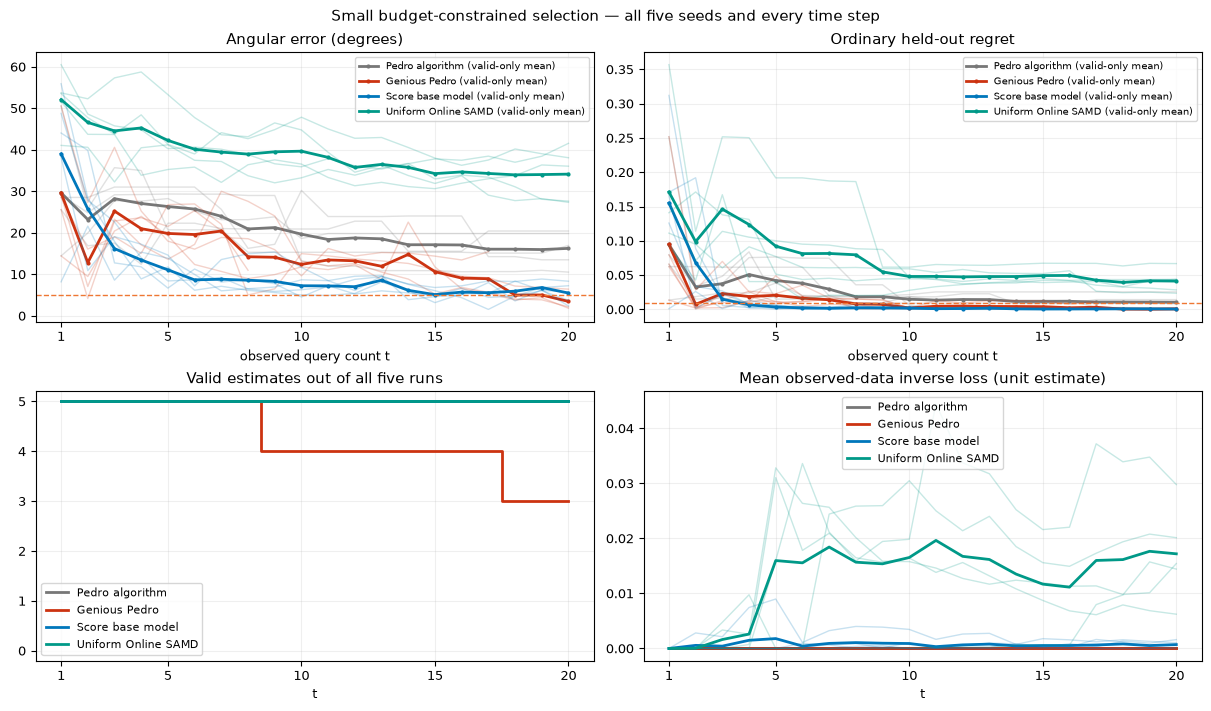

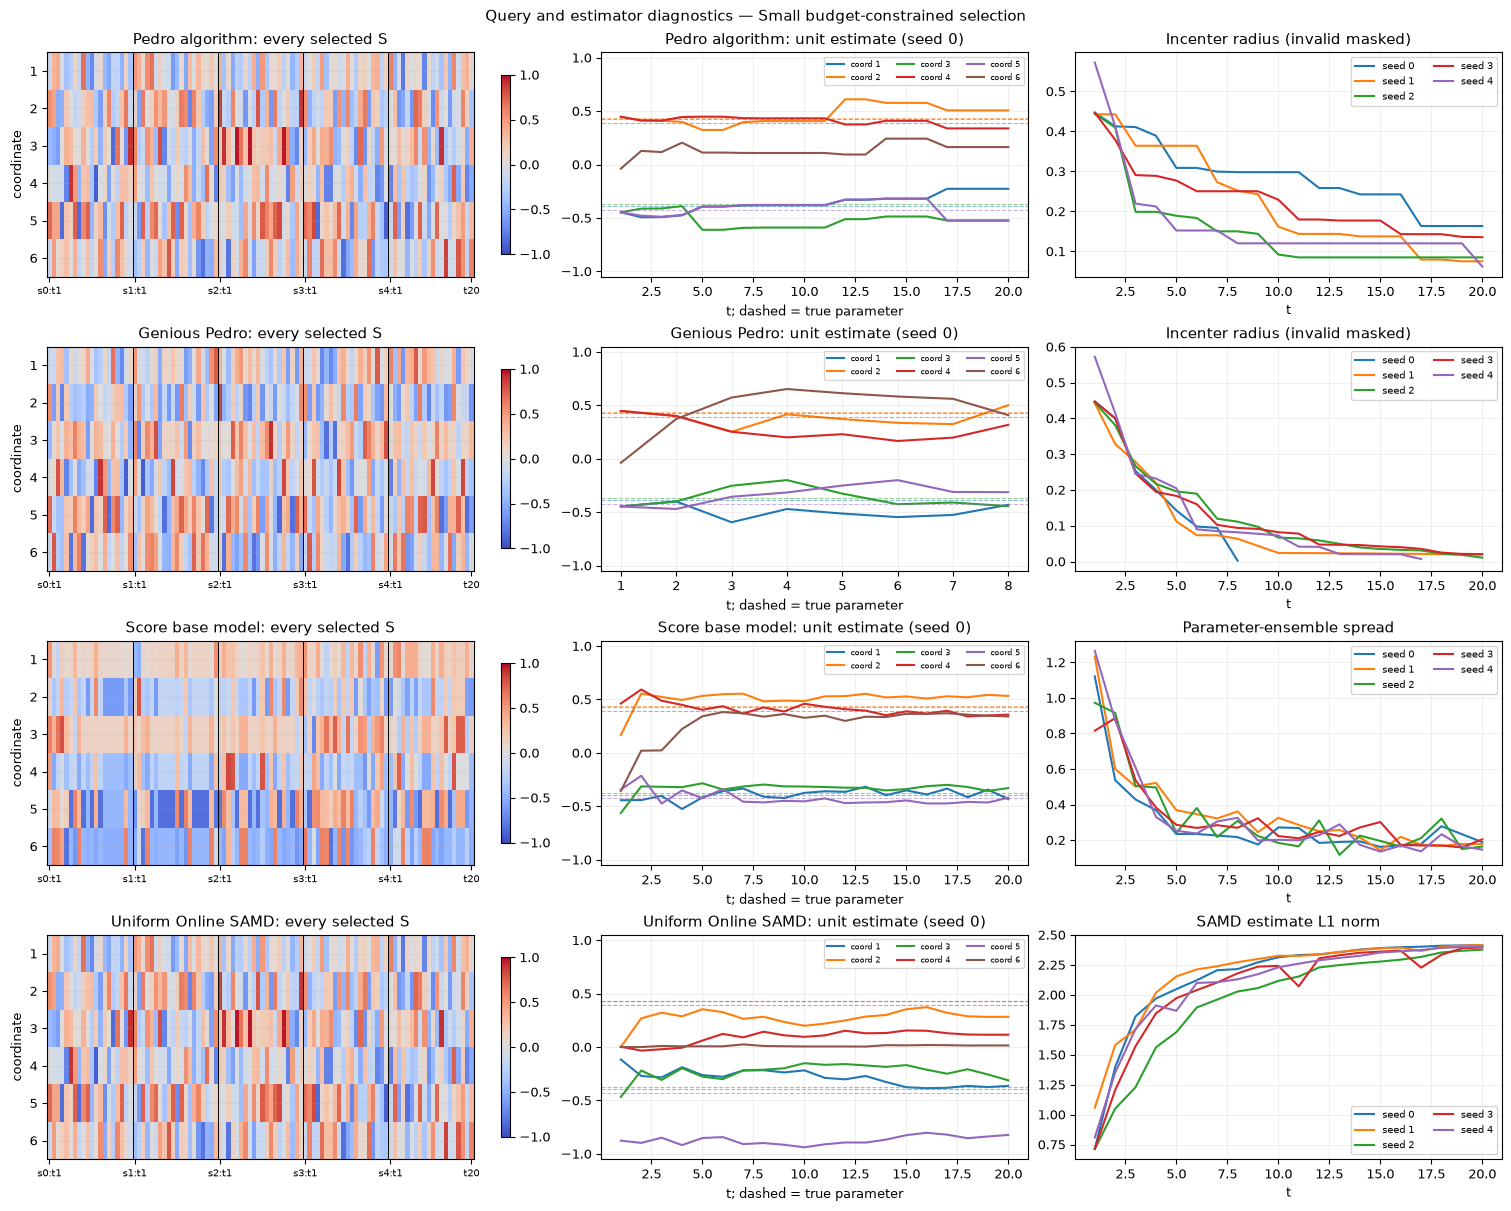

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,NaN,0,20
1,0,Genious Pedro,degenerate_cone,9.0,1,20
2,0,Score base model,valid,NaN,4,20
3,0,Uniform Online SAMD,valid,NaN,0,20
4,1,Pedro algorithm,valid,NaN,2,20
5,1,Genious Pedro,valid,NaN,1,20
6,1,Score base model,valid,NaN,1,20
7,1,Uniform Online SAMD,valid,NaN,2,20
8,2,Pedro algorithm,valid,NaN,0,20
9,2,Genious Pedro,valid,NaN,1,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4469, 0.4469, -0.4469, 0.4469, -0.4469, -0.0385]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",25.59461,0.06595,valid,None
1,Pedro algorithm,"[-0.4469, 0.4469, -0.4469, 0.4469, -0.4469, -0.0385]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",25.59461,0.06595,valid,None
1,Score base model,"[-0.3734, 0.1404, -0.4744, 0.3893, -0.2892, -0.3008]","[0.5143, 0.1165, 0.6046, 0.4603, -0.0952, -0.3680]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",48.78012,0.12592,valid,None
1,Uniform Online SAMD,"[-0.0566, 0.0000, -0.2280, 0.0017, -0.4274, 0.0000]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",53.53825,0.14092,valid,None
2,Genious Pedro,"[-0.4001, 0.4001, -0.4001, 0.4001, -0.4706, 0.3720]","[-0.1129, -0.5975, 0.0566, 0.0505, -0.1513, 0.7757]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",4.17437,0.00057,valid,None
2,Pedro algorithm,"[-0.4934, 0.4127, -0.4127, 0.4127, -0.4788, 0.1279]","[0.3527, 0.4482, -0.5092, -0.0633, 0.4243, 0.4811]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",16.88796,0.01506,valid,None
2,Score base model,"[-0.5036, 0.6330, -0.3577, 0.6763, -0.2445, 0.0235]","[0.0441, -0.3337, 0.3742, -0.5283, 0.3181, 0.6054]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",27.84323,0.03355,valid,None
2,Uniform Online SAMD,"[-0.2238, 0.2223, -0.1815, -0.0276, -0.7415, 0.0000]","[0.3527, 0.4482, -0.5092, -0.0633, 0.4243, 0.4811]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",47.74853,0.17128,valid,None
3,Genious Pedro,"[-0.5948, 0.2527, -0.2527, 0.2527, -0.3558, 0.5727]","[0.2525, 0.2138, 0.2435, 0.7976, -0.3521, -0.2668]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",22.86057,0.01284,valid,None
3,Pedro algorithm,"[-0.4912, 0.4108, -0.4108, 0.4108, -0.4885, 0.1169]","[0.4074, -0.5178, -0.5997, -0.0774, 0.4446, 0.0508]","[1.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",17.53054,0.01615,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4427, 0.4427, -0.4427, 0.4427, -0.4427, -0.1421]","[0.5143, 0.1165, 0.6046, 0.4603, -0.0952, -0.3680]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",28.53286,0.06237,valid,None
1,Pedro algorithm,"[-0.4427, 0.4427, -0.4427, 0.4427, -0.4427, -0.1421]","[0.5143, 0.1165, 0.6046, 0.4603, -0.0952, -0.3680]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",28.53286,0.06237,valid,None
1,Score base model,"[-0.3502, -0.0311, -0.4783, 0.0227, -0.2714, 0.5307]","[-0.4280, 0.1618, 0.2003, 0.0942, -0.6821, -0.5258]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",38.19394,0.16576,valid,None
1,Uniform Online SAMD,"[-0.3236, 0.0000, -0.3974, 0.2830, -0.0535, 0.0000]","[0.5143, 0.1165, 0.6046, 0.4603, -0.0952, -0.3680]","[1.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000]",41.06371,0.11123,valid,None
2,Genious Pedro,"[-0.5779, 0.3282, -0.5325, 0.3282, -0.3282, 0.2436]","[-0.0659, 0.5086, -0.7327, -0.0799, -0.3522, 0.2639]","[0.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",16.09018,0.00329,valid,None
2,Pedro algorithm,"[-0.4427, 0.4427, -0.4427, 0.4427, -0.4427, -0.1421]","[0.3844, -0.5743, -0.2790, -0.0082, -0.6223, -0.2394]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",28.53286,0.06237,valid,None
2,Score base model,"[-0.5572, 0.5189, -0.4771, 0.3726, -0.3966, 0.3727]","[-0.5010, 0.7815, 0.1242, 0.3151, 0.0961, -0.1192]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",10.89327,0.00121,valid,None
2,Uniform Online SAMD,"[-0.4923, 0.2164, -0.5035, 0.2397, -0.0446, -0.0843]","[0.3844, -0.5743, -0.2790, -0.0082, -0.6223, -0.2394]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",40.60616,0.09487,valid,None
3,Genious Pedro,"[-0.4682, 0.5864, -0.4329, 0.3754, -0.2779, 0.1767]","[-0.0811, -0.3193, 0.1930, -0.9148, 0.1304, 0.0176]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",19.04809,0.00987,valid,None
3,Pedro algorithm,"[-0.6561, 0.3641, -0.3641, 0.3641, -0.4016, -0.1021]","[0.0680, 0.6307, -0.1362, -0.0424, 0.7364, 0.1870]","[1.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",31.02642,0.06149,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4442, 0.4430, -0.4442, 0.4381, -0.4442, 0.1410]","[0.3535, 0.8920, 0.1771, 0.1735, 0.0024, 0.1338]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",14.44420,0.01354,valid,None
1,Pedro algorithm,"[-0.4442, 0.4430, -0.4442, 0.4381, -0.4442, 0.1410]","[0.3535, 0.8920, 0.1771, 0.1735, 0.0024, 0.1338]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",14.44420,0.01354,valid,None
1,Score base model,"[0.0387, 0.5155, -0.0380, -0.1821, -0.4098, 0.4759]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",55.91600,0.31201,valid,None
1,Uniform Online SAMD,"[-0.1497, 0.4326, -0.0736, 0.0000, -0.0010, 0.0554]","[0.3535, 0.8920, 0.1771, 0.1735, 0.0024, 0.1338]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",51.64082,0.09232,valid,None
2,Genious Pedro,"[-0.3808, 0.3913, -0.3808, 0.3756, -0.3808, 0.5203]","[-0.0387, -0.4680, 0.0126, -0.2671, -0.1168, -0.8332]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",9.49003,0.00207,valid,None
2,Pedro algorithm,"[-0.4099, 0.5358, -0.4571, 0.4042, -0.4099, 0.0676]","[-0.3569, -0.1371, 0.9077, 0.1369, -0.0536, -0.0905]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",19.96088,0.01865,valid,None
2,Score base model,"[-0.3731, 0.3743, -0.4795, -0.0119, -0.6501, 0.4992]","[0.3955, -0.2278, 0.2477, 0.2860, 0.5658, -0.5731]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",28.44079,0.08863,valid,None
2,Uniform Online SAMD,"[-0.1381, 0.4574, -0.3513, 0.0363, -0.0151, 0.0511]","[-0.3569, -0.1371, 0.9077, 0.1369, -0.0536, -0.0905]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",43.73087,0.04279,valid,None
3,Genious Pedro,"[-0.2665, 0.2738, -0.2665, 0.6218, -0.4083, 0.4792]","[-0.3996, -0.3070, 0.0445, -0.3276, 0.7120, 0.3604]","[0.0000, 0.0000, 0.0000, 1.0000, 1.0000, 0.0000]",20.43647,0.00257,valid,None
3,Pedro algorithm,"[-0.1990, 0.4939, -0.6991, 0.1962, -0.1990, 0.3868]","[0.0861, -0.2582, 0.2938, -0.3760, 0.1759, -0.8169]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",27.72455,0.02393,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4469, 0.4469, -0.4469, 0.4469, -0.4469, -0.0385]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",29.06389,0.07952,valid,None
1,Pedro algorithm,"[-0.4469, 0.4469, -0.4469, 0.4469, -0.4469, -0.0385]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",29.06389,0.07952,valid,None
1,Score base model,"[-0.4642, 0.4094, -0.3731, 0.3783, -0.3736, 0.5220]","[0.5127, 0.2525, -0.3459, -0.1321, -0.3121, 0.6624]","[1.0000, 0.0000, 0.0000, 1.0000, 0.0000, 0.0000]",8.19463,0.00102,valid,None
1,Uniform Online SAMD,"[-0.0566, 0.0000, -0.2280, 0.0017, -0.4274, 0.0000]","[-0.1102, 0.5382, -0.4209, 0.0034, 0.7112, -0.1234]","[0.0000, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000]",53.72759,0.15488,valid,None
2,Genious Pedro,"[-0.4001, 0.4001, -0.4001, 0.4001, -0.4706, 0.3720]","[-0.1129, -0.5975, 0.0566, 0.0505, -0.1513, 0.7757]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",7.07691,0.00259,valid,None
2,Pedro algorithm,"[-0.3792, 0.5511, -0.3792, 0.3792, -0.5140, 0.0281]","[-0.0044, -0.4775, 0.1828, 0.1446, 0.5918, 0.6062]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",24.85022,0.03319,valid,None
2,Score base model,"[-0.2543, 0.4317, -0.1932, 0.2193, -0.2293, 0.6255]","[0.1261, -0.1753, 0.1322, -0.2072, -0.8323, -0.4476]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",21.61831,0.02609,valid,None
2,Uniform Online SAMD,"[-0.0486, 0.1818, -0.1153, 0.0539, -0.8048, 0.0000]","[-0.0044, -0.4775, 0.1828, 0.1446, 0.5918, 0.6062]","[0.0000, 1.0000, 0.0000, 0.0000, 1.0000, 0.0000]",52.28854,0.07109,valid,None
3,Genious Pedro,"[-0.2459, 0.2459, -0.6091, 0.2459, -0.3486, 0.5711]","[0.2525, 0.2138, 0.2435, 0.7976, -0.3521, -0.2668]","[0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 1.0000]",23.28113,0.02023,valid,None
3,Pedro algorithm,"[-0.2907, 0.5284, -0.5672, 0.2907, -0.4795, 0.0000]","[0.1830, -0.1960, 0.4203, 0.0812, 0.8356, -0.2158]","[1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",29.16873,0.03762,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.5720, -0.1249, -0.5720, 0.5720, -0.0520, -0.0000]","[0.6230, -0.0215, 0.0468, -0.7638, -0.1400, -0.0790]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",50.55842,0.25184,valid,None
1,Pedro algorithm,"[-0.5720, -0.1249, -0.5720, 0.5720, -0.0520, -0.0000]","[0.6230, -0.0215, 0.0468, -0.7638, -0.1400, -0.0790]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",50.55842,0.25184,valid,None
1,Score base model,"[0.0238, 0.6073, -0.0934, 0.0209, -0.1890, 0.6607]","[0.0810, -0.6130, 0.1309, -0.3950, -0.4459, -0.4956]","[0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 1.0000]",44.04833,0.17084,valid,None
1,Uniform Online SAMD,"[-0.3226, -0.0100, -0.0218, 0.4171, 0.0000, -0.0367]","[0.6230, -0.0215, 0.0468, -0.7638, -0.1400, -0.0790]","[1.0000, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]",60.51898,0.35692,valid,None
2,Genious Pedro,"[-0.4147, 0.4147, -0.6464, 0.4266, -0.1237, 0.2022]","[-0.3693, -0.4990, 0.2713, 0.1644, -0.3266, 0.6382]","[0.0000, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000]",27.31284,0.02832,valid,None
2,Pedro algorithm,"[-0.4125, 0.3310, -0.6055, 0.4219, -0.4125, 0.0745]","[-0.4613, 0.2757, 0.0390, 0.2964, 0.7387, 0.2759]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",25.82010,0.03378,valid,None
2,Score base model,"[-0.4858, 0.5369, 0.2504, 0.2959, -0.3379, 0.6695]","[0.5454, -0.0072, 0.0480, 0.2591, -0.7900, -0.0953]","[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]",39.86845,0.19197,valid,None
2,Uniform Online SAMD,"[-0.4860, 0.0716, -0.0297, 0.5014, -0.2309, -0.0312]","[-0.4613, 0.2757, 0.0390, 0.2964, 0.7387, 0.2759]","[0.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]",48.62005,0.11400,valid,None
3,Genious Pedro,"[-0.2450, 0.5304, -0.5127, 0.6273, -0.0000, 0.0483]","[0.4244, -0.6196, 0.3099, -0.4748, 0.2578, 0.2191]","[1.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",40.59883,0.06999,valid,None
3,Pedro algorithm,"[-0.2194, 0.4611, -0.4528, 0.6960, -0.2194, 0.0396]","[-0.0546, -0.6435, 0.3093, -0.3481, -0.6039, -0.0363]","[0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]",35.69980,0.04837,valid,None


Completed scenario 6/8; 120/160 complete runs loaded.


In [8]:
run_and_show_family(5)

## 7. Stronger parameter noise — 4D

The geometry, hidden parameters and test queries match scenario 4. Only parameter-noise sigma changes from 0.02 to 0.08. This isolates sensitivity to noisier decisions.

CACHED strong-noise-4d seed=0 Pedro algorithm
CACHED strong-noise-4d seed=0 Genious Pedro
CACHED strong-noise-4d seed=0 Score base model
CACHED strong-noise-4d seed=0 Uniform Online SAMD
CACHED strong-noise-4d seed=1 Pedro algorithm
CACHED strong-noise-4d seed=1 Genious Pedro
CACHED strong-noise-4d seed=1 Score base model
CACHED strong-noise-4d seed=1 Uniform Online SAMD
CACHED strong-noise-4d seed=2 Pedro algorithm
CACHED strong-noise-4d seed=2 Genious Pedro
CACHED strong-noise-4d seed=2 Score base model
CACHED strong-noise-4d seed=2 Uniform Online SAMD
CACHED strong-noise-4d seed=3 Pedro algorithm
CACHED strong-noise-4d seed=3 Genious Pedro


CACHED strong-noise-4d seed=3 Score base model


CACHED strong-noise-4d seed=3 Uniform Online SAMD
CACHED strong-noise-4d seed=4 Pedro algorithm
CACHED strong-noise-4d seed=4 Genious Pedro
CACHED strong-noise-4d seed=4 Score base model
CACHED strong-noise-4d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,15.3198,6.3055,0.0177,0.0107,0,1,0.0526
1,Genious Pedro,ordinary,0/5,5,NaN,NaN,NaN,NaN,0,0,0.1261
2,Score base model,ordinary,5/5,0,5.1850,2.9120,0.0020,0.0014,3,5,9.9118
3,Uniform Online SAMD,ordinary,5/5,0,39.6798,7.1138,0.0842,0.0328,0,0,0.0031


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,52.3440,16.4912,0.2249,0.2183,5/5,52.3440,16.4912,0.2249,0.2183,5/5,59.6548,17.6088,0.3039,0.2079,5/5,63.3037,13.3576,0.3065,0.1168
1,2,5/5,34.9566,11.6538,0.0786,0.0863,5/5,32.9751,12.0904,0.0963,0.0719,5/5,52.3316,17.3387,0.2565,0.1670,5/5,44.3168,10.1410,0.1417,0.0749
2,3,5/5,33.1702,13.0894,0.0960,0.0742,5/5,27.5162,7.6247,0.0582,0.0280,5/5,22.9724,15.8865,0.0780,0.0858,5/5,41.6503,11.7379,0.1486,0.0735
3,4,5/5,34.9626,7.8790,0.1017,0.0673,5/5,28.5628,8.3242,0.0616,0.0322,5/5,15.6791,6.9602,0.0208,0.0189,5/5,40.2727,7.9056,0.1155,0.0419
4,5,5/5,36.5264,6.0841,0.1159,0.0678,5/5,18.2165,9.6484,0.0278,0.0237,5/5,11.0841,3.6539,0.0129,0.0066,5/5,40.3834,7.5975,0.1224,0.0416
5,6,5/5,35.5348,5.9771,0.1104,0.0548,4/5,20.6736,8.4159,0.0310,0.0145,5/5,9.0208,2.8816,0.0062,0.0024,5/5,39.2505,4.6604,0.0983,0.0203
6,7,5/5,30.8303,11.0429,0.0948,0.0709,4/5,16.9670,8.5480,0.0211,0.0165,5/5,10.0113,3.5328,0.0090,0.0059,5/5,35.7120,9.3293,0.0878,0.0358
7,8,5/5,29.2165,13.6088,0.0901,0.0779,4/5,18.0473,10.5763,0.0355,0.0388,5/5,8.8806,2.5006,0.0066,0.0038,5/5,36.7281,7.3045,0.0883,0.0485
8,9,5/5,17.6187,8.8797,0.0257,0.0290,4/5,16.2947,9.1339,0.0210,0.0175,5/5,9.1152,1.7243,0.0073,0.0038,5/5,33.1194,7.9641,0.0702,0.0288
9,10,5/5,17.8367,8.6707,0.0261,0.0287,4/5,15.2272,9.7018,0.0194,0.0164,5/5,7.5983,2.4593,0.0043,0.0024,5/5,36.5169,9.1519,0.0784,0.0288


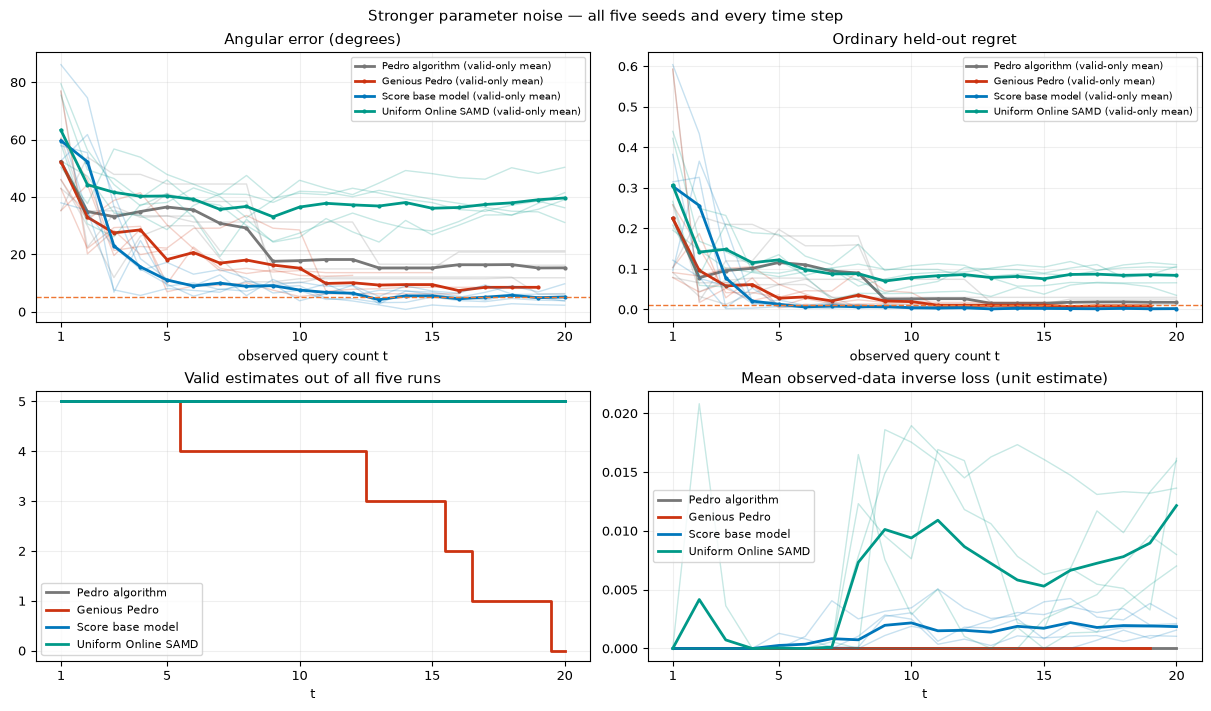

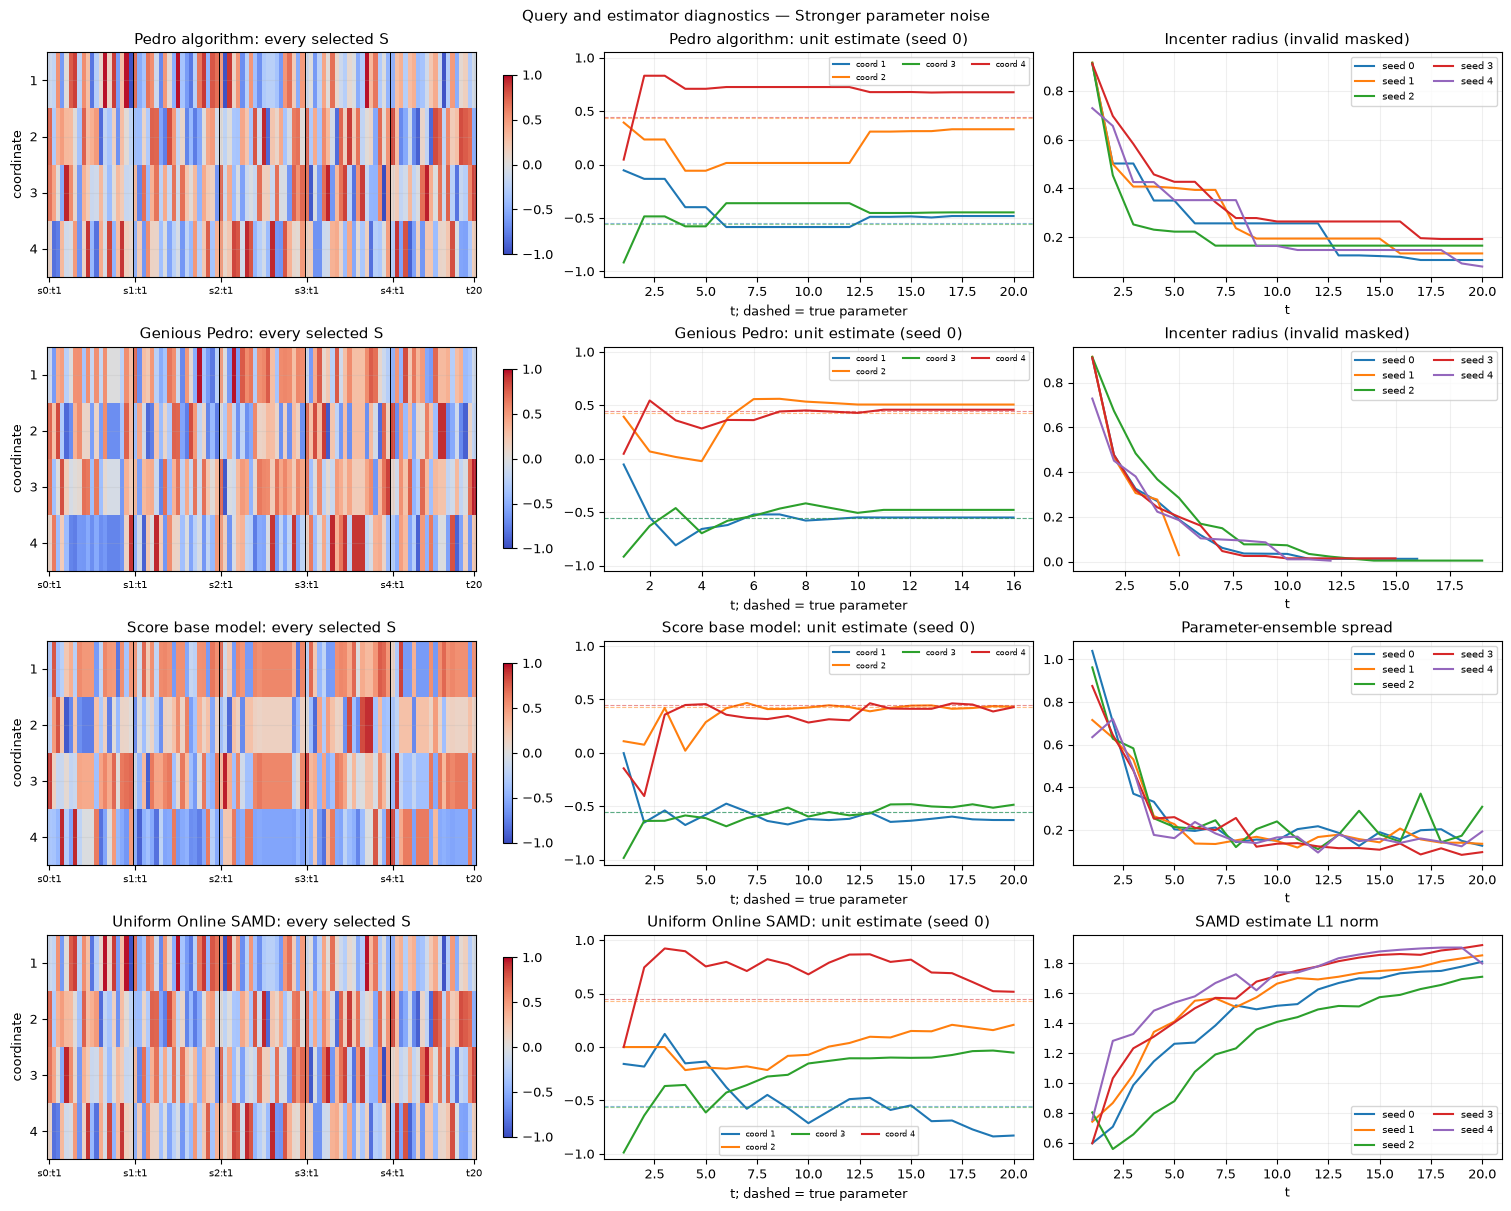

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,NaN,1,20
1,0,Genious Pedro,degenerate_cone,17.0,3,20
2,0,Score base model,valid,NaN,4,20
3,0,Uniform Online SAMD,valid,NaN,1,20
4,1,Pedro algorithm,valid,NaN,0,20
5,1,Genious Pedro,degenerate_cone,6.0,1,20
6,1,Score base model,valid,NaN,3,20
7,1,Uniform Online SAMD,valid,NaN,0,20
8,2,Pedro algorithm,valid,NaN,1,20
9,2,Genious Pedro,degenerate_cone,20.0,3,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Score base model,"[-0.0012, 0.0561, -0.5049, -0.0743]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",57.86244,0.31490,valid,None
1,Uniform Online SAMD,"[-0.0824, 0.0000, -0.5154, 0.0000]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",50.39906,0.20824,valid,None
2,Genious Pedro,"[-0.5498, 0.0679, -0.6292, 0.5452]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",22.11671,0.04320,valid,None
2,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
2,Score base model,"[-0.5286, 0.0620, -0.5161, -0.3273]","[0.7870, 0.4912, 0.1455, -0.3439]","[1.0000, 0.0000, 0.0000, 0.0000]",55.47425,0.32613,valid,None
2,Uniform Online SAMD,"[-0.0824, 0.0000, -0.2891, 0.3366]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",37.72622,0.08412,valid,None
3,Genious Pedro,"[-0.8106, 0.0163, -0.4620, 0.3596]","[0.4051, 0.8227, -0.0052, -0.3988]","[1.0000, 0.0000, 0.0000, 0.0000]",29.35701,0.06660,valid,None
3,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[0.5341, 0.3739, 0.0193, -0.7580]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Pedro algorithm,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Score base model,"[0.0756, 0.5560, -0.1425, -0.1004]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",63.66072,0.38259,valid,None
1,Uniform Online SAMD,"[-0.5010, -0.2409, 0.0000, 0.0000]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",75.47588,0.43946,valid,None
2,Genious Pedro,"[-0.7569, 0.4230, -0.4324, 0.2475]","[-0.6856, 0.4262, -0.5830, -0.0920]","[0.0000, 0.0000, 0.0000, 1.0000]",20.21652,0.01704,valid,None
2,Pedro algorithm,"[-0.7957, 0.4237, -0.3355, 0.2735]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",22.51927,0.02074,valid,None
2,Score base model,"[-0.0106, 0.6560, -0.2947, 0.4854]","[-0.0988, -0.0372, -0.4371, -0.8932]","[0.0000, 0.0000, 0.0000, 1.0000]",34.46721,0.07708,valid,None
2,Uniform Online SAMD,"[-0.4882, -0.0601, -0.3189, 0.0000]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",49.50855,0.24969,valid,None
3,Genious Pedro,"[-0.7670, 0.1899, -0.2199, 0.5720]","[0.2912, -0.1064, 0.3235, -0.8940]","[0.0000, 0.0000, 0.0000, 1.0000]",28.37319,0.05205,valid,None
3,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[-0.3454, 0.1053, 0.6798, -0.6383]","[0.0000, 0.0000, 1.0000, 0.0000]",34.13039,0.11974,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Pedro algorithm,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Score base model,"[-0.5578, -0.2865, 0.0487, -0.0538]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",86.15365,0.60416,valid,None
1,Uniform Online SAMD,"[0.3138, 0.0000, -0.4902, 0.0000]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",79.48034,0.42236,valid,None
2,Genious Pedro,"[0.2250, 0.6771, -0.6636, 0.2248]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",46.23284,0.15127,valid,None
2,Pedro algorithm,"[-0.3673, 0.4471, -0.8076, 0.1135]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",33.12903,0.04375,valid,None
2,Score base model,"[-0.6272, -0.1229, -0.3114, -0.2712]","[-0.1004, -0.1892, 0.9506, 0.2248]","[0.0000, 0.0000, 1.0000, 0.0000]",74.59635,0.43358,valid,None
2,Uniform Online SAMD,"[-0.0051, 0.0641, -0.4902, 0.0000]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",56.39012,0.16838,valid,None
3,Genious Pedro,"[-0.0943, 0.4820, -0.6543, 0.5751]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",21.37050,0.04159,valid,None
3,Pedro algorithm,"[-0.6235, 0.2288, -0.7401, 0.1055]","[0.8838, -0.0047, 0.4124, 0.2210]","[1.0000, 0.0000, 0.0000, 0.0000]",36.68532,0.07180,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Score base model,"[-0.0515, 0.0890, -0.6106, 0.0477]","[-0.2201, 0.0172, 0.9032, -0.3680]","[0.0000, 0.0000, 1.0000, 0.0000]",52.60040,0.09599,valid,None
1,Uniform Online SAMD,"[-0.0824, 0.0000, -0.5154, 0.0000]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",58.58716,0.26679,valid,None
2,Genious Pedro,"[-0.5498, 0.0679, -0.6292, 0.5452]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",32.04731,0.08259,valid,None
2,Pedro algorithm,"[-0.1337, 0.6943, -0.6835, 0.1814]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",29.99334,0.03234,valid,None
2,Score base model,"[-0.6571, 0.1131, -0.5177, -0.3340]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",61.77641,0.36594,valid,None
2,Uniform Online SAMD,"[-0.0768, 0.3135, -0.4800, 0.1614]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",30.66605,0.05962,valid,None
3,Genious Pedro,"[-0.3487, -0.0003, -0.4715, 0.8100]","[0.4051, 0.8227, -0.0052, -0.3988]","[0.0000, 0.0000, 0.0000, 1.0000]",38.85017,0.10163,valid,None
3,Pedro algorithm,"[-0.2664, 0.5778, -0.5424, 0.5486]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",11.93554,0.01270,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Pedro algorithm,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Score base model,"[0.0611, 0.5142, -0.0831, 0.4168]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",37.99676,0.12178,valid,None
1,Uniform Online SAMD,"[-0.4990, 0.0000, 0.0000, 0.2558]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",52.57606,0.19569,valid,None
2,Genious Pedro,"[-0.2942, 0.8334, 0.2521, 0.3942]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",44.26195,0.18764,valid,None
2,Pedro algorithm,"[-0.4874, 0.5105, 0.4492, 0.5478]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",53.94416,0.23011,valid,None
2,Score base model,"[0.1325, 0.5305, -0.5166, 0.4185]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",35.34367,0.07978,valid,None
2,Uniform Online SAMD,"[-0.8436, 0.2458, 0.0000, 0.1929]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",47.29323,0.14681,valid,None
3,Genious Pedro,"[-0.3997, 0.7843, -0.1589, 0.4470]","[-0.4566, 0.5295, 0.5348, 0.4744]","[0.0000, 0.0000, 1.0000, 0.0000]",19.62997,0.02889,valid,None
3,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[0.3767, -0.7055, -0.1865, -0.5706]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None


Completed scenario 7/8; 140/160 complete runs loaded.


In [9]:
run_and_show_family(6)

## 8. Query-dependent parameter noise — 4D

The geometry, hidden parameters and tests again match scenario 4. Parameter sigma is now 0.02 + 0.08*abs(s1). The algorithms observe clean decisions from a query-dependent noisy parameter, not observation-corrupted Y.

CACHED query-noise-4d seed=0 Pedro algorithm
CACHED query-noise-4d seed=0 Genious Pedro
CACHED query-noise-4d seed=0 Score base model
CACHED query-noise-4d seed=0 Uniform Online SAMD
CACHED query-noise-4d seed=1 Pedro algorithm
CACHED query-noise-4d seed=1 Genious Pedro
CACHED query-noise-4d seed=1 Score base model
CACHED query-noise-4d seed=1 Uniform Online SAMD
CACHED query-noise-4d seed=2 Pedro algorithm
CACHED query-noise-4d seed=2 Genious Pedro
CACHED query-noise-4d seed=2 Score base model
CACHED query-noise-4d seed=2 Uniform Online SAMD
CACHED query-noise-4d seed=3 Pedro algorithm
CACHED query-noise-4d seed=3 Genious Pedro


CACHED query-noise-4d seed=3 Score base model


CACHED query-noise-4d seed=3 Uniform Online SAMD
CACHED query-noise-4d seed=4 Pedro algorithm
CACHED query-noise-4d seed=4 Genious Pedro
CACHED query-noise-4d seed=4 Score base model
CACHED query-noise-4d seed=4 Uniform Online SAMD


,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Pedro algorithm,ordinary,5/5,0,15.3198,6.3055,0.0177,0.0107,0,1,0.0556
1,Genious Pedro,ordinary,2/5,3,7.8536,0.9748,0.0071,0.0023,0,2,0.1611
2,Score base model,ordinary,5/5,0,3.9335,0.6805,0.0010,0.0003,5,5,10.0525
3,Uniform Online SAMD,ordinary,5/5,0,39.6798,7.1138,0.0842,0.0328,0,0,0.0036


,t,Pedro valid / 5,Pedro angle mean,Pedro angle SD,Pedro regret mean,Pedro regret SD,Genious valid / 5,Genious angle mean,Genious angle SD,Genious regret mean,Genious regret SD,Score base valid / 5,Score base angle mean,Score base angle SD,Score base regret mean,Score base regret SD,SAMD valid / 5,SAMD angle mean,SAMD angle SD,SAMD regret mean,SAMD regret SD
0,1,5/5,52.3440,16.4912,0.2249,0.2183,5/5,52.3440,16.4912,0.2249,0.2183,5/5,59.6548,17.6088,0.3039,0.2079,5/5,63.3037,13.3576,0.3065,0.1168
1,2,5/5,34.9566,11.6538,0.0786,0.0863,5/5,32.9751,12.0904,0.0963,0.0719,5/5,52.3316,17.3387,0.2565,0.1670,5/5,44.3168,10.1410,0.1417,0.0749
2,3,5/5,33.1702,13.0894,0.0960,0.0742,5/5,27.5162,7.6247,0.0582,0.0280,5/5,22.9724,15.8865,0.0780,0.0858,5/5,41.6503,11.7379,0.1486,0.0735
3,4,5/5,34.9626,7.8790,0.1017,0.0673,5/5,28.5628,8.3242,0.0616,0.0322,5/5,13.0147,4.7723,0.0125,0.0060,5/5,40.2727,7.9056,0.1155,0.0419
4,5,5/5,36.5264,6.0841,0.1159,0.0678,5/5,18.3345,9.7056,0.0296,0.0248,5/5,10.2324,4.6344,0.0113,0.0081,5/5,40.3834,7.5975,0.1224,0.0416
5,6,5/5,35.5348,5.9771,0.1104,0.0548,5/5,18.5540,8.7959,0.0254,0.0178,5/5,8.8929,2.8378,0.0061,0.0024,5/5,39.2505,4.6604,0.0983,0.0203
6,7,5/5,30.8303,11.0429,0.0948,0.0709,5/5,15.1753,8.4336,0.0186,0.0156,5/5,9.4790,4.1155,0.0083,0.0064,5/5,35.7120,9.3293,0.0878,0.0358
7,8,5/5,29.2165,13.6088,0.0901,0.0779,5/5,14.9908,11.5290,0.0291,0.0368,5/5,8.4474,2.6391,0.0064,0.0039,5/5,36.7281,7.3045,0.0883,0.0485
8,9,5/5,17.6187,8.8797,0.0257,0.0290,5/5,13.4548,9.1673,0.0181,0.0167,5/5,7.6438,3.2314,0.0065,0.0049,5/5,33.1194,7.9641,0.0702,0.0288
9,10,5/5,17.8367,8.6707,0.0261,0.0287,5/5,13.0164,9.8285,0.0183,0.0154,5/5,7.5709,3.4698,0.0050,0.0048,5/5,36.5169,9.1519,0.0784,0.0288


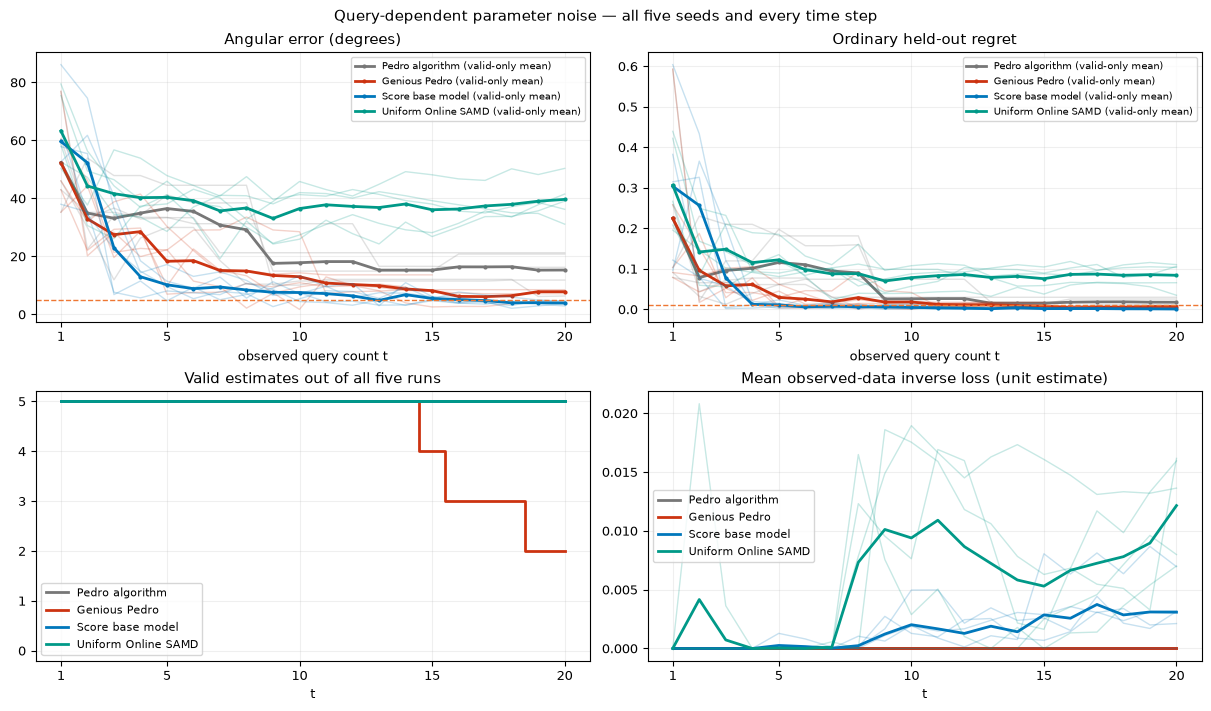

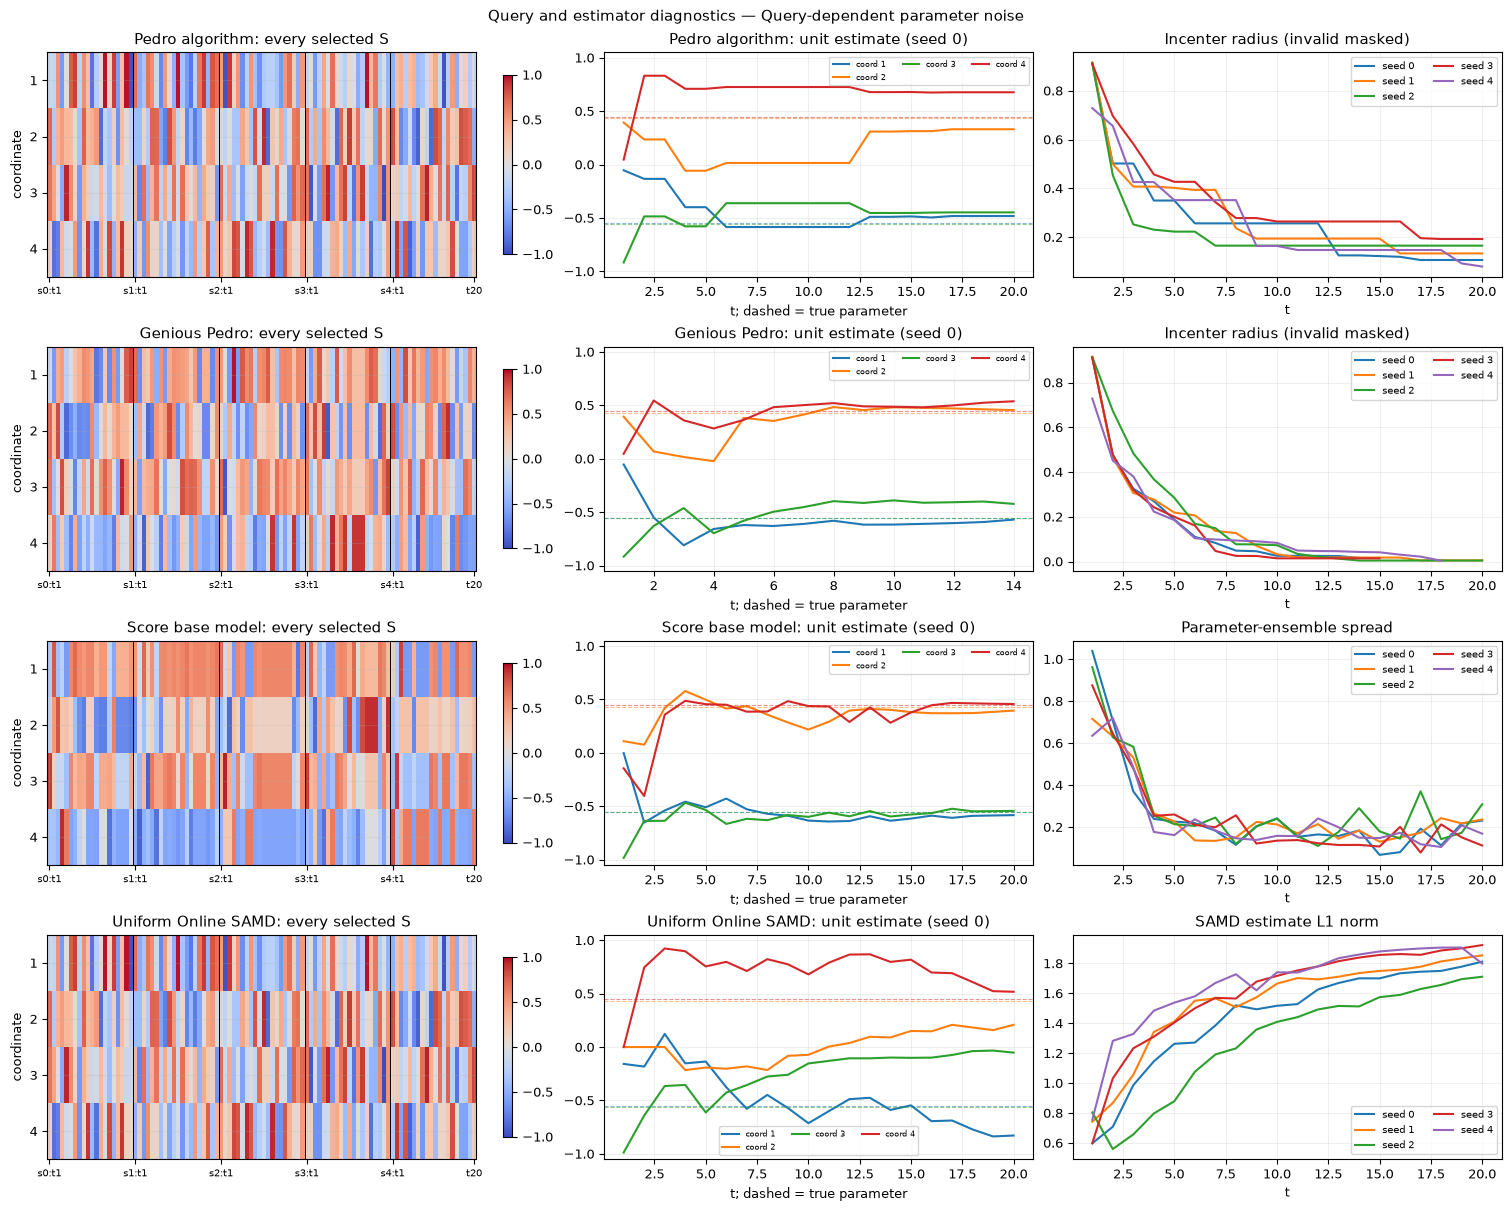

,seed,algorithm,final status,first invalid t,noise-changed decisions / 20,dense unit queries
0,0,Pedro algorithm,valid,NaN,1,20
1,0,Genious Pedro,degenerate_cone,15.0,2,20
2,0,Score base model,valid,NaN,5,20
3,0,Uniform Online SAMD,valid,NaN,1,20
4,1,Pedro algorithm,valid,NaN,0,20
5,1,Genious Pedro,valid,NaN,1,20
6,1,Score base model,valid,NaN,7,20
7,1,Uniform Online SAMD,valid,NaN,0,20
8,2,Pedro algorithm,valid,NaN,1,20
9,2,Genious Pedro,valid,NaN,2,20


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",43.01624,0.07886,valid,None
1,Score base model,"[-0.0012, 0.0561, -0.5049, -0.0743]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",57.86244,0.31490,valid,None
1,Uniform Online SAMD,"[-0.0824, 0.0000, -0.5154, 0.0000]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",50.39906,0.20824,valid,None
2,Genious Pedro,"[-0.5498, 0.0679, -0.6292, 0.5452]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",22.11671,0.04320,valid,None
2,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None
2,Score base model,"[-0.5286, 0.0620, -0.5161, -0.3273]","[0.7870, 0.4912, 0.1455, -0.3439]","[1.0000, 0.0000, 0.0000, 0.0000]",55.47425,0.32613,valid,None
2,Uniform Online SAMD,"[-0.0824, 0.0000, -0.2891, 0.3366]","[-0.1904, -0.3022, 0.4431, -0.8222]","[0.0000, 0.0000, 0.0000, 1.0000]",37.72622,0.08412,valid,None
3,Genious Pedro,"[-0.8106, 0.0163, -0.4620, 0.3596]","[0.4051, 0.8227, -0.0052, -0.3988]","[1.0000, 0.0000, 0.0000, 0.0000]",29.35701,0.06660,valid,None
3,Pedro algorithm,"[-0.1339, 0.2347, -0.4854, 0.8315]","[0.5341, 0.3739, 0.0193, -0.7580]","[0.0000, 0.0000, 0.0000, 1.0000]",35.19734,0.06588,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Pedro algorithm,"[-0.9471, -0.1718, 0.1279, -0.2391]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",76.91949,0.59295,valid,None
1,Score base model,"[0.0756, 0.5560, -0.1425, -0.1004]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",63.66072,0.38259,valid,None
1,Uniform Online SAMD,"[-0.5010, -0.2409, 0.0000, 0.0000]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",75.47588,0.43946,valid,None
2,Genious Pedro,"[-0.7569, 0.4230, -0.4324, 0.2475]","[-0.6856, 0.4262, -0.5830, -0.0920]","[0.0000, 0.0000, 0.0000, 1.0000]",20.21652,0.01704,valid,None
2,Pedro algorithm,"[-0.7957, 0.4237, -0.3355, 0.2735]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",22.51927,0.02074,valid,None
2,Score base model,"[-0.0106, 0.6560, -0.2947, 0.4854]","[-0.0988, -0.0372, -0.4371, -0.8932]","[0.0000, 0.0000, 0.0000, 1.0000]",34.46721,0.07708,valid,None
2,Uniform Online SAMD,"[-0.4882, -0.0601, -0.3189, 0.0000]","[-0.5202, -0.4059, -0.7274, 0.1884]","[0.0000, 1.0000, 0.0000, 0.0000]",49.50855,0.24969,valid,None
3,Genious Pedro,"[-0.7670, 0.1899, -0.2199, 0.5720]","[0.2912, -0.1064, 0.3235, -0.8940]","[0.0000, 0.0000, 0.0000, 1.0000]",28.37319,0.05205,valid,None
3,Pedro algorithm,"[-0.7204, 0.4788, -0.4975, -0.0648]","[-0.3454, 0.1053, 0.6798, -0.6383]","[0.0000, 0.0000, 1.0000, 0.0000]",34.13039,0.11974,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Pedro algorithm,"[0.2862, 0.0022, -0.9145, 0.2860]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",60.45309,0.25829,valid,None
1,Score base model,"[-0.5578, -0.2865, 0.0487, -0.0538]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",86.15365,0.60416,valid,None
1,Uniform Online SAMD,"[0.3138, 0.0000, -0.4902, 0.0000]","[0.4957, 0.0172, 0.7133, 0.4952]","[0.0000, 0.0000, 1.0000, 0.0000]",79.48034,0.42236,valid,None
2,Genious Pedro,"[0.2250, 0.6771, -0.6636, 0.2248]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",46.23284,0.15127,valid,None
2,Pedro algorithm,"[-0.3673, 0.4471, -0.8076, 0.1135]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",33.12903,0.04375,valid,None
2,Score base model,"[-0.6272, -0.1229, -0.3114, -0.2712]","[-0.1004, -0.1892, 0.9506, 0.2248]","[0.0000, 0.0000, 1.0000, 0.0000]",74.59635,0.43358,valid,None
2,Uniform Online SAMD,"[-0.0051, 0.0641, -0.4902, 0.0000]","[-0.9649, -0.2088, -0.1271, 0.0963]","[0.0000, 1.0000, 0.0000, 0.0000]",56.39012,0.16838,valid,None
3,Genious Pedro,"[-0.0943, 0.4820, -0.6543, 0.5751]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",21.37050,0.04159,valid,None
3,Pedro algorithm,"[-0.6235, 0.2288, -0.7401, 0.1055]","[0.8838, -0.0047, 0.4124, 0.2210]","[1.0000, 0.0000, 0.0000, 0.0000]",36.68532,0.07180,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Pedro algorithm,"[-0.0538, 0.3934, -0.9166, 0.0463]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",46.06690,0.09126,valid,None
1,Score base model,"[-0.0515, 0.0890, -0.6106, 0.0477]","[-0.2201, 0.0172, 0.9032, -0.3680]","[0.0000, 0.0000, 1.0000, 0.0000]",52.60040,0.09599,valid,None
1,Uniform Online SAMD,"[-0.0824, 0.0000, -0.5154, 0.0000]","[-0.1249, 0.7238, 0.6685, 0.1168]","[0.0000, 0.0000, 1.0000, 0.0000]",58.58716,0.26679,valid,None
2,Genious Pedro,"[-0.5498, 0.0679, -0.6292, 0.5452]","[-0.6124, 0.2670, -0.3820, 0.6386]","[0.0000, 1.0000, 0.0000, 0.0000]",32.04731,0.08259,valid,None
2,Pedro algorithm,"[-0.1337, 0.6943, -0.6835, 0.1814]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",29.99334,0.03234,valid,None
2,Score base model,"[-0.6571, 0.1131, -0.5177, -0.3340]","[0.7120, -0.3836, 0.3232, -0.4914]","[1.0000, 0.0000, 0.0000, 0.0000]",61.77641,0.36594,valid,None
2,Uniform Online SAMD,"[-0.0768, 0.3135, -0.4800, 0.1614]","[-0.0050, -0.3052, -0.9376, 0.1665]","[0.0000, 1.0000, 0.0000, 0.0000]",30.66605,0.05962,valid,None
3,Genious Pedro,"[-0.3487, -0.0003, -0.4715, 0.8100]","[0.4051, 0.8227, -0.0052, -0.3988]","[0.0000, 0.0000, 0.0000, 1.0000]",38.85017,0.10163,valid,None
3,Pedro algorithm,"[-0.2664, 0.5778, -0.5424, 0.5486]","[-0.6235, 0.4127, -0.0424, -0.6627]","[0.0000, 0.0000, 0.0000, 1.0000]",11.93554,0.01270,valid,None


t,algorithm,theta_hat,S,observed Y,angle,ordinary regret,status,failure reason
1,Genious Pedro,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Pedro algorithm,"[-0.4209, 0.5267, 0.0982, 0.7320]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",35.26439,0.10328,valid,None
1,Score base model,"[0.0611, 0.5142, -0.0831, 0.4168]","[0.1243, -0.3315, -0.4041, 0.8434]","[0.0000, 1.0000, 0.0000, 0.0000]",37.99676,0.12178,valid,None
1,Uniform Online SAMD,"[-0.4990, 0.0000, 0.0000, 0.2558]","[-0.4772, 0.8313, 0.0839, -0.2724]","[0.0000, 0.0000, 0.0000, 1.0000]",52.57606,0.19569,valid,None
2,Genious Pedro,"[-0.2942, 0.8334, 0.2521, 0.3942]","[0.5086, -0.6974, -0.0960, -0.4957]","[0.0000, 1.0000, 0.0000, 0.0000]",44.26195,0.18764,valid,None
2,Pedro algorithm,"[-0.4874, 0.5105, 0.4492, 0.5478]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",53.94416,0.23011,valid,None
2,Score base model,"[0.1325, 0.5305, -0.5166, 0.4185]","[-0.2883, -0.1893, 0.8800, -0.3267]","[0.0000, 0.0000, 1.0000, 0.0000]",35.34367,0.07978,valid,None
2,Uniform Online SAMD,"[-0.8436, 0.2458, 0.0000, 0.1929]","[0.2858, 0.2903, 0.1947, 0.8923]","[1.0000, 0.0000, 0.0000, 0.0000]",47.29323,0.14681,valid,None
3,Genious Pedro,"[-0.3997, 0.7843, -0.1589, 0.4470]","[-0.4566, 0.5295, 0.5348, 0.4744]","[0.0000, 0.0000, 1.0000, 0.0000]",19.62997,0.02889,valid,None
3,Pedro algorithm,"[-0.3035, 0.8302, 0.3105, 0.3497]","[0.3767, -0.7055, -0.1865, -0.5706]","[0.0000, 1.0000, 0.0000, 0.0000]",47.90233,0.21001,valid,None


Completed scenario 8/8; 160/160 complete runs loaded.


In [10]:
run_and_show_family(7)

## Combined final results and recovery times

These tables include **all 160 runs**. Valid-only averages are conditional, and valid counts/failures are shown alongside them. Pairwise wins are calculated only when both compared estimates are valid; one-sided and two-sided failures are counted separately.

The recovery table lists every seed. “Not reached” is never dropped from success counts. “Sustained” refers only to the observed remainder through T=20 and does not guarantee future stability.


In [11]:
runs=list(ALL_RUNS.values())
assert len(runs)==160
assert {r["algorithm_name"] for r in runs}==set(LABELS)
assert all(len(r["records"])==T and r["error"] is None for r in runs)
assert all(not r["metadata"]["external_stopping_enabled"] for r in runs)
for r in runs:
    if r["algorithm_name"] in LABELS[:2]:
        assert r["metadata"]["comparison_estimator"]=="incenter"
        assert all("theta_samples" not in x["update_diagnostics"] for x in r["records"])
    elif r["algorithm_name"] == LABELS[2]:
        assert all(x["update_diagnostics"]["sampler_config"]["theta_samples"]==16 for x in r["records"])
        for record in r["records"]:
            np.testing.assert_allclose(record["theta_hat_after"],
                np.mean(record["update_diagnostics"]["theta_samples"],axis=0))
    else:
        assert r["metadata"]["comparison_estimator"]=="online signed exponentiated ASL"
        assert all(x["update_diagnostics"]["epsilon"]==0.0 for x in r["records"])
        assert all(x["update_diagnostics"]["update_count"]==i+1
                   for i,x in enumerate(r["records"]))
    for ev in r["metadata"]["evaluations_by_distribution"].values():
        for valid,angle,regret in zip(ev["valid_estimate_history"],
                ev["angular_error_history_degrees"],ev["normalized_regret_history"]):
            assert (angle is not None and regret is not None) if valid else (angle is None and regret is None)

summaries=[]
for design in DESIGNS[0]:
    subset=[r for r in runs if r["metadata"]["comparison_family"]==design.family]
    table=conditional_summary(subset,design.test_queries)
    table.insert(0,"scenario",design.title)
    summaries.append(table)
summary=pd.concat(summaries,ignore_index=True)
display(summary.round(4))

recovery=[]
for r in sorted(runs,key=lambda r:(r["metadata"]["comparison_family"],r["seed"],r["algorithm_name"])):
    for distribution,ev in r["metadata"]["evaluations_by_distribution"].items():
        recovery.append({
            "scenario":r["metadata"]["comparison_title"],"seed":r["seed"],
            "algorithm":r["algorithm_name"],"test":distribution,
            "final status":ev["final_status"],
            "first <=5 deg":ev["first_angular_threshold_step"],
            "sustained <=5 deg":ev["stable_angular_threshold_step"],
            "first regret<=.01":ev["first_threshold_step"],
            "sustained regret<=.01":ev["stable_threshold_step"],
            "first joint":ev["first_joint_threshold_step"],
            "sustained joint":ev["stable_joint_threshold_step"],
            "first invalid t":r["metadata"]["first_invalid_step"],
        })
recovery=pd.DataFrame(recovery)
display(HTML(recovery.to_html(index=False,na_rep="not reached / none",float_format=lambda x:f"{x:.0f}")))

from itertools import combinations
pairs=[]
for design in DESIGNS[0]:
    family=design.family
    for distribution in design.test_queries:
        for left,right in combinations(LABELS,2):
            row={"scenario":design.title,"test":distribution,
                 "left":left,"right":right,"both valid":0,
                 "left invalid only":0,"right invalid only":0,"both invalid":0,
                 "left lower angle":0,"right lower angle":0,"angle tied":0,
                 "left lower regret":0,"right lower regret":0,"regret tied":0}
            for seed in SEEDS:
                a=evaluation(ALL_RUNS[(family,seed,left)],distribution)
                b=evaluation(ALL_RUNS[(family,seed,right)],distribution)
                av,bv=a["final_estimate_valid"],b["final_estimate_valid"]
                if av and bv:
                    row["both valid"]+=1
                    for metric,name in [("final_angular_error_degrees","angle"),("final_normalized_regret","regret")]:
                        diff=a[metric]-b[metric]
                        row[("left lower "+name) if diff < -1e-12 else
                            ("right lower "+name) if diff > 1e-12 else (name+" tied")]+=1
                elif not av and bv: row["left invalid only"]+=1
                elif av and not bv: row["right invalid only"]+=1
                else: row["both invalid"]+=1
            pairs.append(row)
display(pd.DataFrame(pairs))
print("ALL OUTPUTS READY: 160/160 runs, 3,200 observed steps, 8 scenarios.")
print("Per-step mean tables, all five-seed curves, full theta/S/Y tables and raw checkpoints are preserved.")
print("Final invalid runs by algorithm:",{label:sum(not evaluation(r)["final_estimate_valid"]
      for r in runs if r["algorithm_name"]==label) for label in LABELS})


,scenario,algorithm,test,final valid / 5,runs ever invalid / 5,angle mean (valid only),angle SD (valid only),regret mean (valid only),regret SD (valid only),final angle<=5 / 5,final regret<=.01 / 5,mean runtime seconds
0,Connecting two groups,Pedro algorithm,ordinary,4/5,1,16.7912,11.6802,0.0156,0.0112,1,1,0.2515
1,Connecting two groups,Pedro algorithm,balanced,4/5,1,16.7912,11.6802,0.0215,0.0138,1,1,0.2515
2,Connecting two groups,Genious Pedro,ordinary,4/5,1,26.9592,7.8881,0.0556,0.0249,0,0,0.3755
3,Connecting two groups,Genious Pedro,balanced,4/5,1,26.9592,7.8881,0.0483,0.0340,0,1,0.3755
4,Connecting two groups,Score base model,ordinary,5/5,0,3.5883,0.9255,0.0027,0.0016,5,5,24.6559
5,Connecting two groups,Score base model,balanced,5/5,0,3.5883,0.9255,0.0020,0.0014,5,5,24.6559
6,Connecting two groups,Uniform Online SAMD,ordinary,5/5,0,41.6586,16.7190,0.1363,0.0432,0,0,0.0070
7,Connecting two groups,Uniform Online SAMD,balanced,5/5,0,41.6586,16.7190,0.1344,0.0542,0,0,0.0070
8,Several boundaries to locate,Pedro algorithm,ordinary,4/5,1,10.2015,9.2091,0.0206,0.0225,2,2,0.0748
9,Several boundaries to locate,Genious Pedro,ordinary,0/5,5,NaN,NaN,NaN,NaN,0,0,0.1452


scenario,seed,algorithm,test,final status,first <=5 deg,sustained <=5 deg,first regret<=.01,sustained regret<=.01,first joint,sustained joint,first invalid t
Ordinary balanced choice,0,Genious Pedro,ordinary,degenerate_cone,17,not reached / none,5,not reached / none,17,not reached / none,18
Ordinary balanced choice,0,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,4,4,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,0,Score base model,ordinary,valid,5,17,3,5,5,17,not reached / none
Ordinary balanced choice,0,Uniform Online SAMD,ordinary,valid,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,1,Genious Pedro,ordinary,valid,8,14,8,12,8,14,not reached / none
Ordinary balanced choice,1,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,1,Score base model,ordinary,valid,9,15,5,5,9,15,not reached / none
Ordinary balanced choice,1,Uniform Online SAMD,ordinary,valid,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none,not reached / none
Ordinary balanced choice,2,Genious Pedro,ordinary,degenerate_cone,13,not reached / none,11,not reached / none,13,not reached / none,18
Ordinary balanced choice,2,Pedro algorithm,ordinary,valid,not reached / none,not reached / none,14,14,not reached / none,not reached / none,not reached / none


,scenario,test,left,right,both valid,left invalid only,right invalid only,both invalid,left lower angle,right lower angle,angle tied,left lower regret,right lower regret,regret tied
0,Connecting two groups,ordinary,Pedro algorithm,Genious Pedro,3,1,1,0,3,0,0,3,0,0
1,Connecting two groups,ordinary,Pedro algorithm,Score base model,4,1,0,0,0,4,0,1,3,0
2,Connecting two groups,ordinary,Pedro algorithm,Uniform Online SAMD,4,1,0,0,4,0,0,4,0,0
3,Connecting two groups,ordinary,Genious Pedro,Score base model,4,1,0,0,0,4,0,0,4,0
4,Connecting two groups,ordinary,Genious Pedro,Uniform Online SAMD,4,1,0,0,2,2,0,4,0,0
5,Connecting two groups,ordinary,Score base model,Uniform Online SAMD,5,0,0,0,5,0,0,5,0,0
6,Connecting two groups,balanced,Pedro algorithm,Genious Pedro,3,1,1,0,3,0,0,3,0,0
7,Connecting two groups,balanced,Pedro algorithm,Score base model,4,1,0,0,0,4,0,0,4,0
8,Connecting two groups,balanced,Pedro algorithm,Uniform Online SAMD,4,1,0,0,4,0,0,4,0,0
9,Connecting two groups,balanced,Genious Pedro,Score base model,4,1,0,0,0,4,0,0,4,0


ALL OUTPUTS READY: 160/160 runs, 3,200 observed steps, 8 scenarios.
Per-step mean tables, all five-seed curves, full theta/S/Y tables and raw checkpoints are preserved.
Final invalid runs by algorithm: {'Pedro algorithm': 2, 'Genious Pedro': 25, 'Score base model': 0, 'Uniform Online SAMD': 0}


## Independent audit of failed hard-cone incenter estimates

A homogeneous cone always contains zero. A zero incenter radius can mean that the cone has become lower-dimensional, not that every nonzero feasible direction has disappeared.

The independent linear programs below audit Pedro and Genious Pedro at their first invalid step and at T. This audit applies only to their hard-cone estimators; Score Base and SAMD do not use this cone. A zero maximum strict margin with a nonzero feasible coordinate means **no full-dimensional interior, but nonzero feasible directions remain**. We still mark the incenter estimate invalid; no substitute estimator or metric is introduced.


In [12]:
from scipy.optimize import linprog

cone_audit=[]
for run in runs:
    if run["algorithm_name"] not in LABELS[:2] or run["metadata"]["first_invalid_step"] is None:
        continue
    d=len(run["true_theta"])
    design=next(item for item in DESIGNS[run["seed"]]
                if item.family==run["metadata"]["comparison_family"])
    problem=PublicDecisionProblem(make_decision_space(
        design.scenario.decision_space,d,np.random.default_rng(0)))
    alternatives=np.asarray(problem.enumerate_decisions(),dtype=float)
    for t in sorted({run["metadata"]["first_invalid_step"],T}):
        normals=np.vstack([np.asarray(record["query"])*
            (np.asarray(record["observed_decision"])-alternatives)
            for record in run["records"][:t]])
        lengths=np.linalg.norm(normals,axis=1)
        normals=normals[lengths>1e-12]/lengths[lengths>1e-12,None]
        margin=linprog(np.r_[np.zeros(d),-1.],A_ub=np.c_[normals,np.ones(len(normals))],
            b_ub=np.zeros(len(normals)),bounds=[(-1,1)]*d+[(0,None)],method="highs")
        extrema=[linprog(sign*np.eye(d)[j],A_ub=normals,b_ub=np.zeros(len(normals)),
            bounds=[(-1,1)]*d,method="highs") for j in range(d) for sign in (-1,1)]
        assert margin.success and all(result.success for result in extrema)
        largest=max(-result.fun for result in extrema)
        cone_audit.append({"scenario":run["metadata"]["comparison_title"],
            "algorithm":run["algorithm_name"],"seed":run["seed"],"t":t,
            "maximum strict margin (box)":-margin.fun,
            "largest feasible coordinate magnitude":largest,
            "nonzero direction exists":largest>1e-8,
            "reported estimate status":run["records"][t-1]["update_diagnostics"]["estimate_status"]})
display(pd.DataFrame(cone_audit).round(8))
print("This audit clarifies failure geometry; no run, estimate, or metric was replaced.")


,scenario,algorithm,seed,t,maximum strict margin (box),largest feasible coordinate magnitude,nonzero direction exists,reported estimate status
0,Connecting two groups,Genious Pedro,1,16,-0.0,1.0,True,degenerate_cone
1,Connecting two groups,Genious Pedro,1,20,-0.0,1.0,True,degenerate_cone
2,Connecting two groups,Pedro algorithm,3,9,-0.0,1.0,True,degenerate_cone
3,Connecting two groups,Pedro algorithm,3,20,-0.0,1.0,True,degenerate_cone
4,Several boundaries to locate,Genious Pedro,0,15,-0.0,1.0,True,degenerate_cone
5,Several boundaries to locate,Genious Pedro,0,20,-0.0,1.0,True,degenerate_cone
6,Several boundaries to locate,Genious Pedro,1,10,-0.0,1.0,True,degenerate_cone
7,Several boundaries to locate,Genious Pedro,1,20,-0.0,1.0,True,degenerate_cone
8,Several boundaries to locate,Genious Pedro,2,14,-0.0,1.0,True,degenerate_cone
9,Several boundaries to locate,Genious Pedro,2,20,-0.0,1.0,True,degenerate_cone


This audit clarifies failure geometry; no run, estimate, or metric was replaced.


## Interpretation boundaries

- This is the exact former benchmark with Uniform Online SAMD added; historical notebooks 15 and 16 remain unchanged.
- Pedro and Uniform Online SAMD both select S uniformly, so their comparison isolates the estimator/update rule.
- Genious Pedro and Pedro share the same incenter estimator, so their difference isolates query selection while their cones remain valid.
- Score Base differs in both estimator and query selection, so comparisons involving it are comparisons of complete algorithms.
- SAMD receives exactly one online mirror update per observation and uses fixed hyperparameters across every family and seed; it was not tuned per scenario.
- Failed estimates remain failures, not large artificial angles. Conditional averages must always be read with valid counts.
- More reliable decisions do not imply exact parameter recovery; angular error and regret remain separate.
- These eight families and five seeds provide empirical evidence, not a general convergence theorem.
